In [3]:
#DETECTING BREAST CANCER FROM BLOOD SAMPLES

#BACKGROUND:
#detecting cancer at its initial stage is important for treatment success and survival rate.
#A minimally invasive way, without submitting the patient to specialized procedures that usually include
#imaging by ionizing radiation (X-Ray), is through the analysis of blood samples.

#OBJECTIVE:
#develop machine learning pipelines to identify if a blood sample is or is not collected from a
#person with breast cancer (BINARY CLASSIFIER).

#DATASET:
#64 patients with breast cancer and 52 healthy (TOT: 116 samples)
#9 features gathered in routine blood analysis + 1 label

Saving Breast_Cancer_Coimbra_Dataset.csv to Breast_Cancer_Coimbra_Dataset.csv

Dataset successfully uploaded 
#lines:116 #columns:10

Features (X)
   Age        BMI  Glucose  Insulin      HOMA   Leptin  Adiponectin  Resistin  \
0   48  23.500000       70    2.707  0.467409   8.8071     9.702400   7.99585   
1   83  20.690495       92    3.115  0.706897   8.8438     5.429285   4.06405   
2   82  23.124670       91    4.498  1.009651  17.9393    22.432040   9.27715   
3   68  21.367521       77    3.226  0.612725   9.8827     7.169560  12.76600   
4   86  21.111111       92    3.549  0.805386   6.6994     4.819240  10.57635   

     MCP.1  
0  417.114  
1  468.786  
2  554.697  
3  928.220  
4  773.920  

Label (Y)
0    1
1    1
2    1
3    1
4    1
Name: Classification, dtype: int64


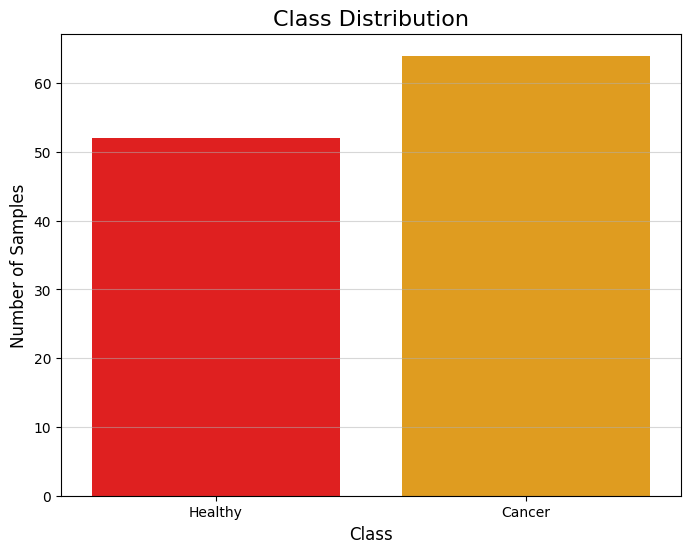

In [4]:
import pandas as pd #for structured data
import io
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import ast
import warnings
import math
import plotly.graph_objects as go
from google.colab import files

from scipy.stats import zscore, norm, skew, kruskal, multivariate_normal
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_curve, auc, confusion_matrix, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from scipy.spatial.distance import euclidean, mahalanobis

uploaded = files.upload()
file_name = next(iter(uploaded))
#reads CSV file
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print(f"\nDataset successfully uploaded \nlines:{df.shape[0]} columns:{df.shape[1]}")

#X (features)
X = df.drop(columns=['Classification'])
#Y (labels)
Y = df['Classification']

print("\nFeatures (X)")
print(X.head())

print("\nLabel (Y)")
print(Y.head())

plot_df = X.copy() #independent copy of X
plot_df['Class'] = Y #adds the column Y
plot_df['Class'] = plot_df['Class'].map({1: 'Healthy', 2: 'Cancer'})
#mapping: 1 = healthy; 2 = cancer.
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=plot_df, palette=['red', 'orange'], hue='Class', legend=False)
plt.title('Class Distribution', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.show()

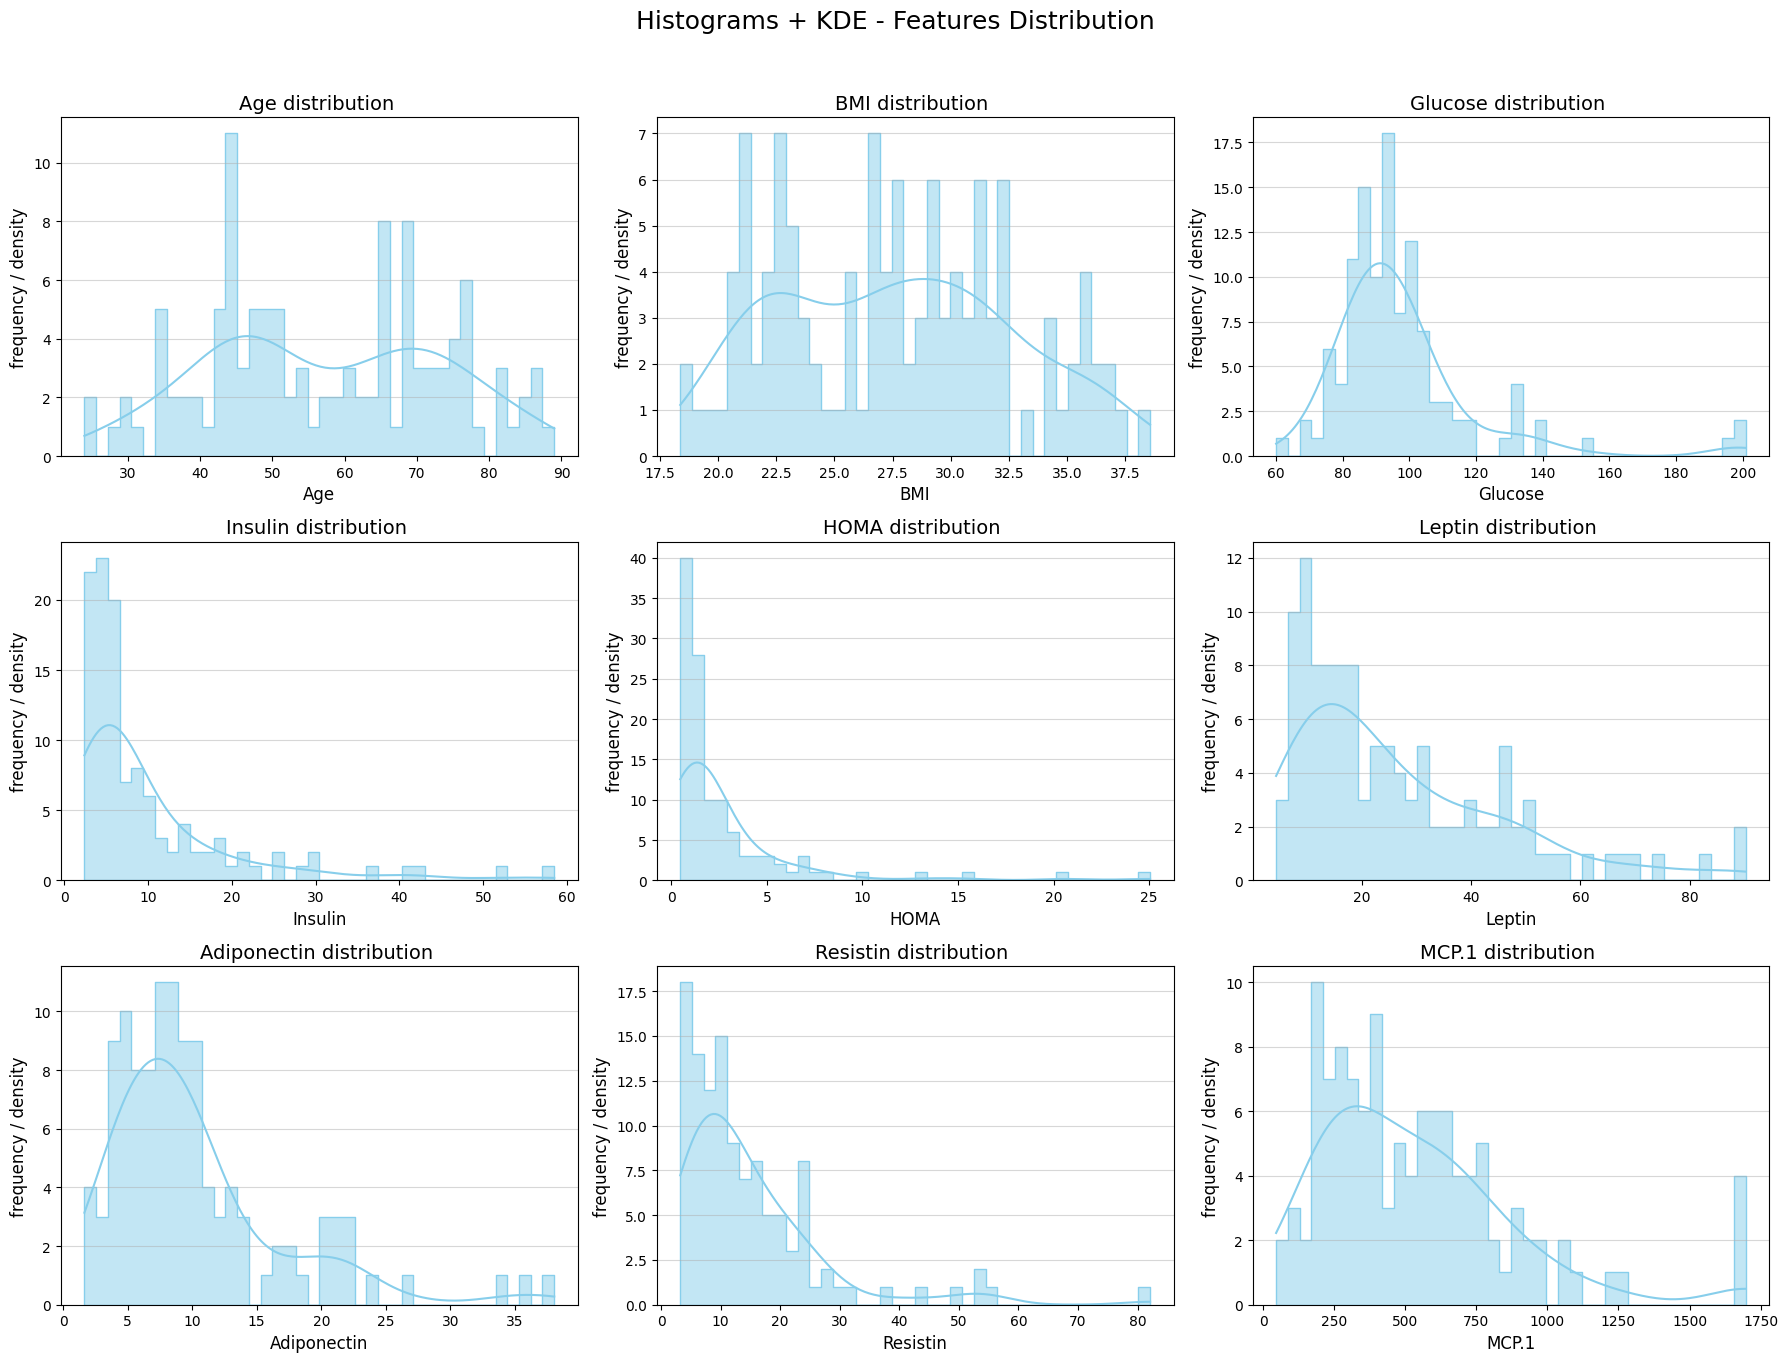

In [5]:
#2) EDA (histograms and KDE) - AGGREGATE
feature_columns = X.columns.tolist()
#3x3 matrix to visualize all the features
n_rows = 3
n_cols = 3

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    ax = axes[i]

    #histogram + KDE (kernel density estimate)
    sns.histplot(
        data=X,
        x=col,
        kde=True,
        bins=40,
        ax=ax,
        color='skyblue',
        element="step",
        legend=False,
    )

    ax.set_title(f'{col} distribution ', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('frequency / density', fontsize=12)
    ax.grid(axis='y', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Histograms + KDE - Features Distribution', fontsize=18, y=1.0)
plt.show()

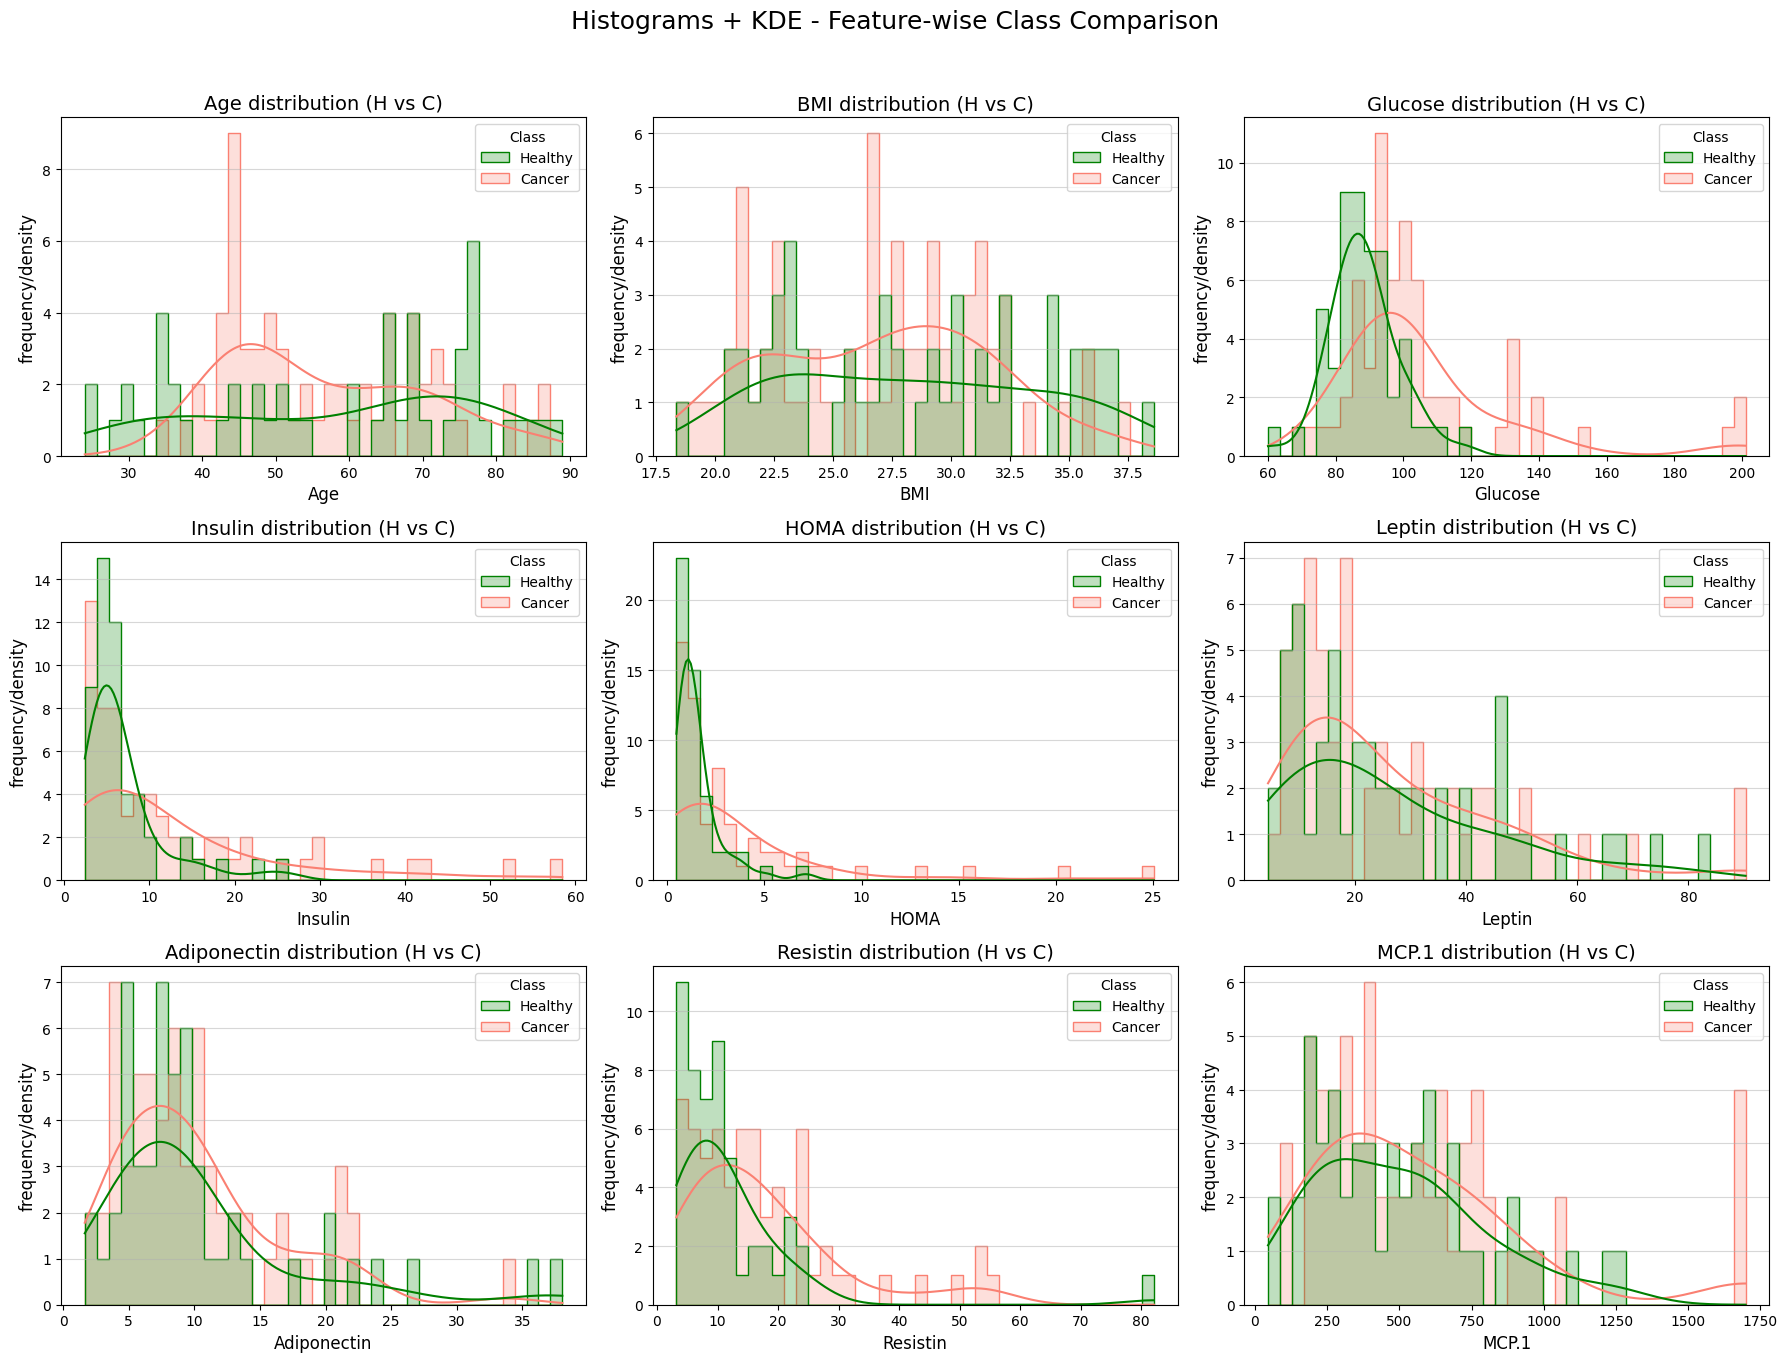

In [6]:
#2) EDA (histograms and KDE) - CLASS
feature_columns = X.columns.tolist()

n_rows = 3
n_cols = 3

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axes = axes.flatten()
#converts the 3x3 matrix of axes into a 1D array
#this is done to easily iterate over all axes with a simple for loop
for i, col in enumerate(feature_columns):
    ax = axes[i]

    sns.histplot(
        data=plot_df,
        x=col,
        hue='Class',  #divides the data by class and colors them differently
        kde=True,
        bins=40,
        ax=ax,
        palette=['green', 'salmon'],
        element="step",
        #makes the histograms look like line outlines instead of solid blocks
        #so overlapping classes can be compared more clearly
        legend=True,
    )

    ax.set_title(f'{col} distribution (H vs C)', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('frequency/density', fontsize=12)
    ax.grid(axis='y', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Histograms + KDE - Feature-wise Class Comparison', fontsize=18, y=1.0)
plt.show()

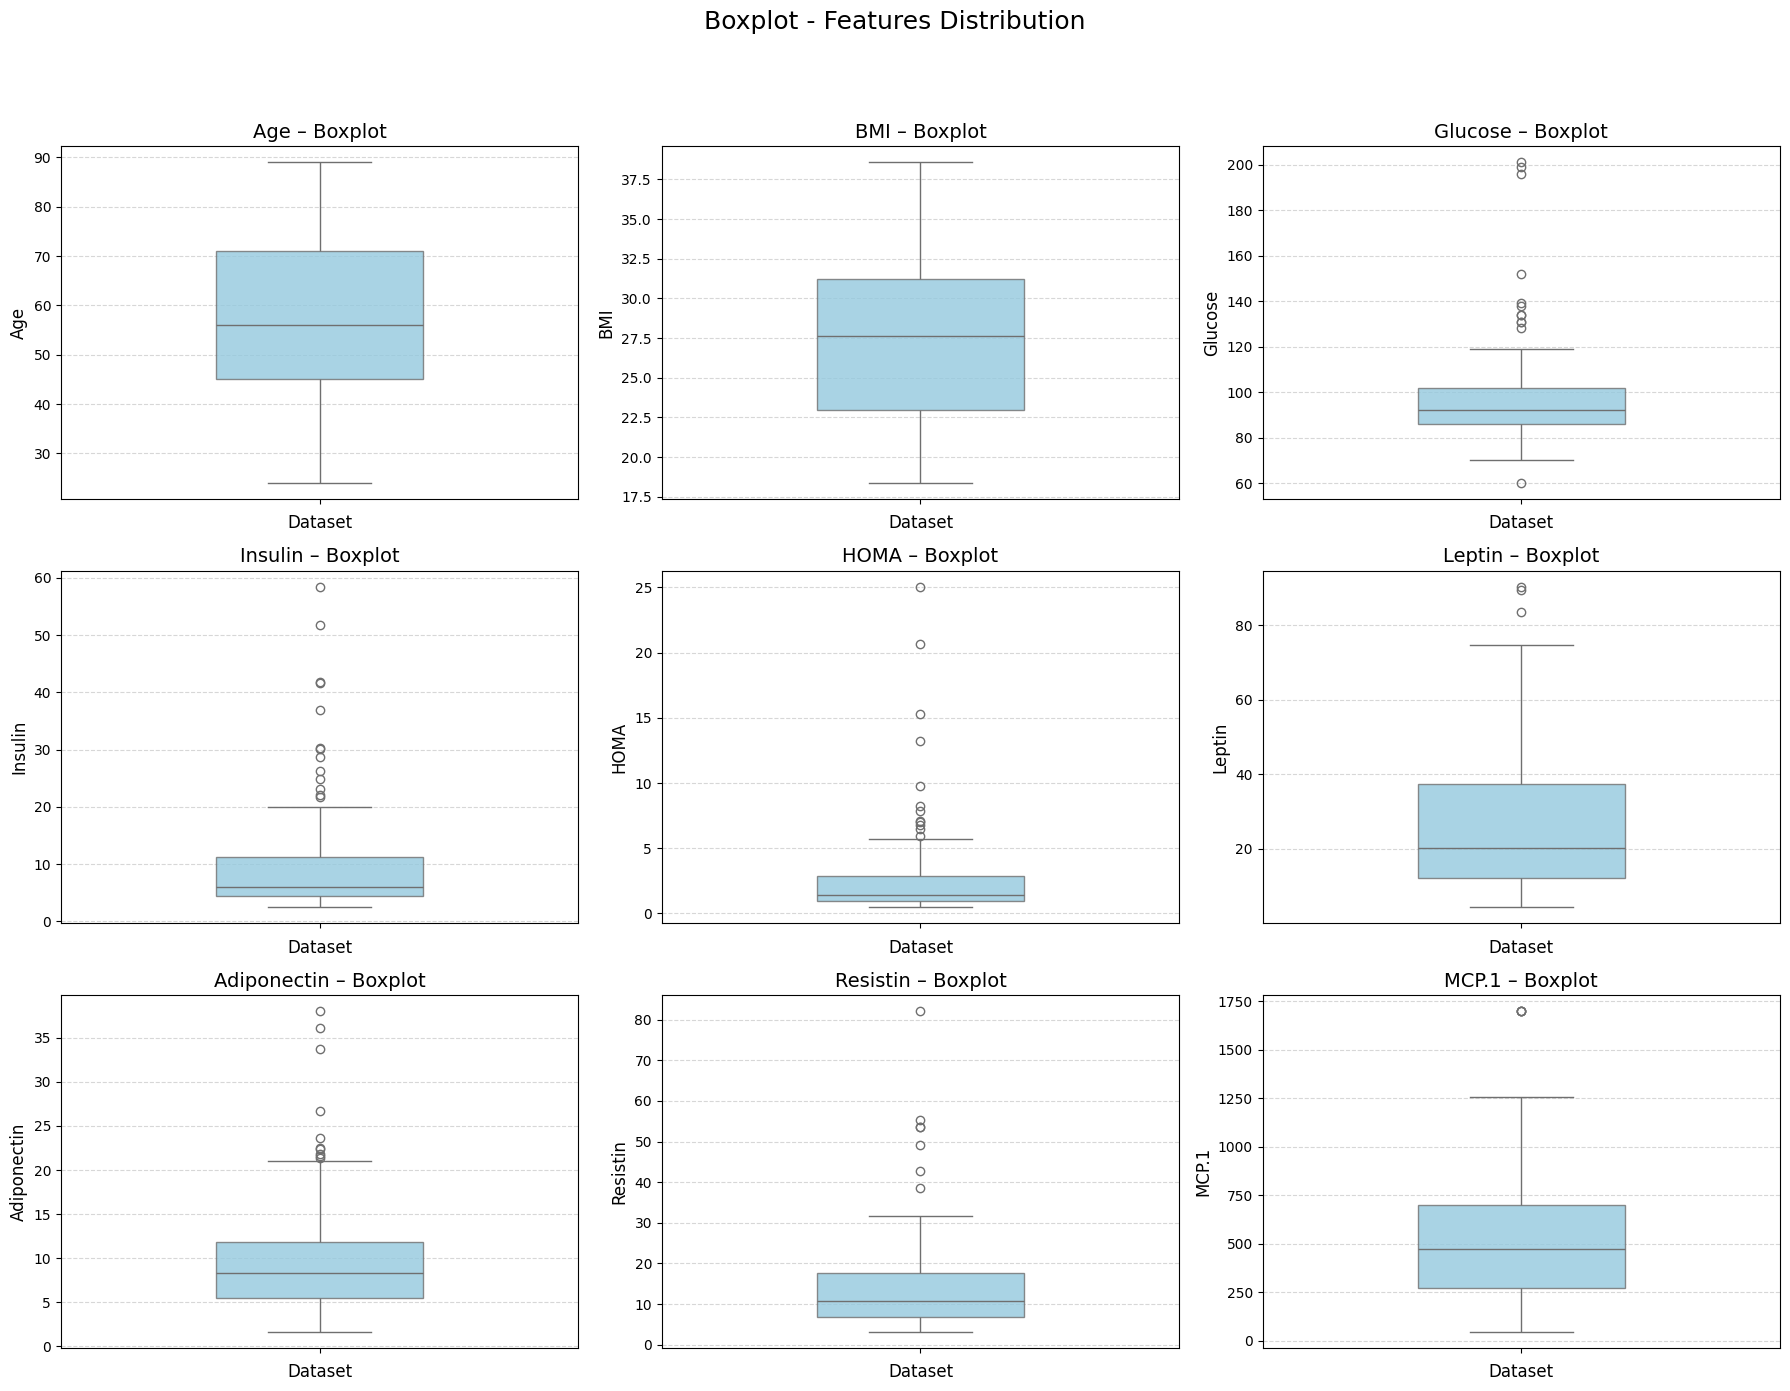

In [7]:
#2) EDA (boxplot) - AGGREGATE
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    ax = axes[i]

    sns.boxplot(
        y=col,
        data=X,
        ax=ax,
        color='skyblue',
        width=0.4,
        showfliers=True,
        boxprops=dict(alpha=0.8)
    )

    ax.set_title(f'{col} – Boxplot', fontsize=14)
    ax.set_xlabel('Dataset', fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    ax.grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Boxplot - Features Distribution', fontsize=18, y=1.02)
plt.show()

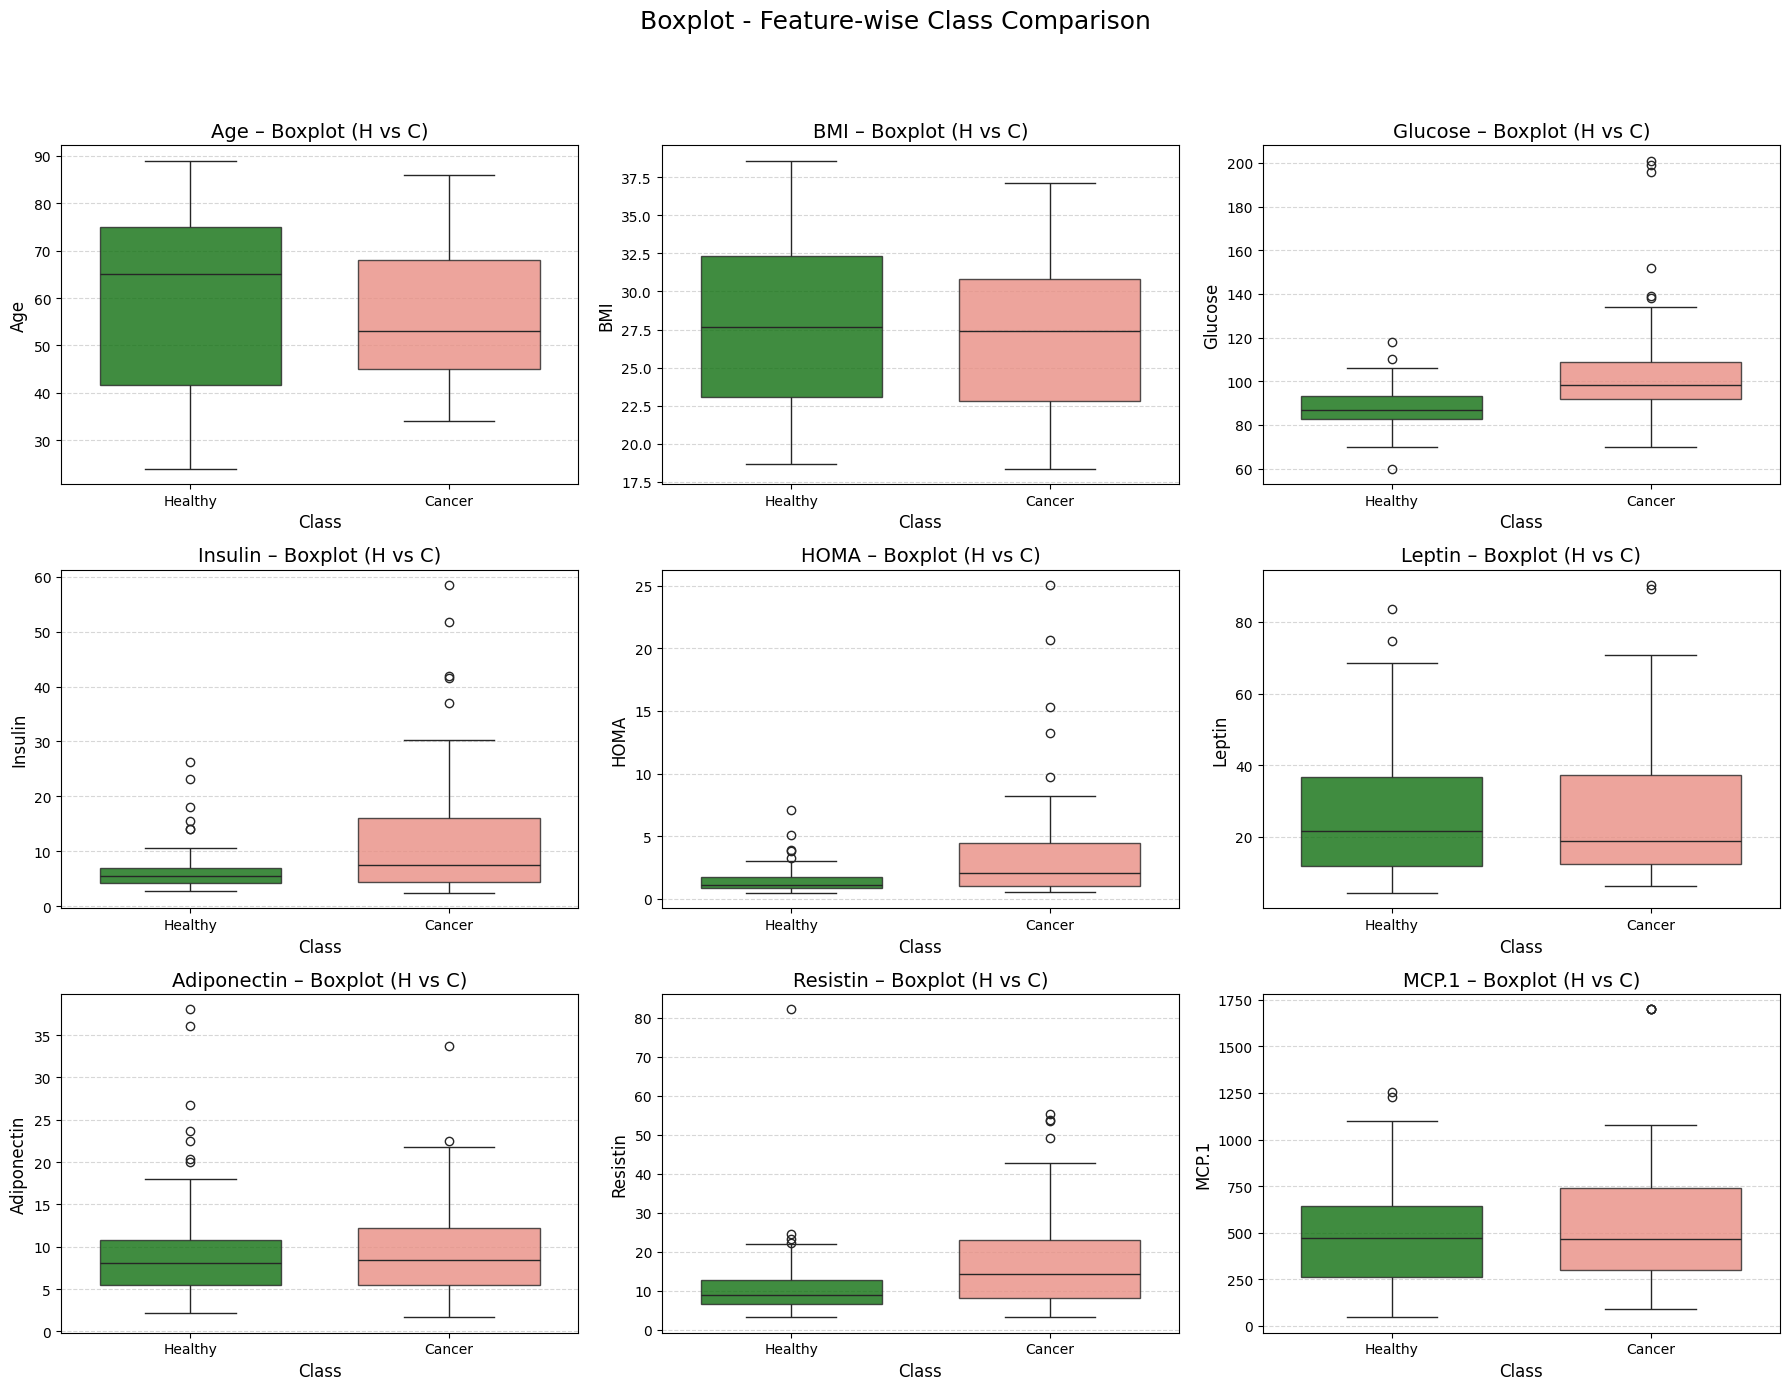

In [8]:
#2) EDA (boxplot) - CLASS
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    ax = axes[i]
    sns.boxplot(
        x='Class',
        y=col,
        hue='Class',
        legend = False,
        data=plot_df,
        ax=ax,
        palette=['green', 'salmon'],
        width=0.7,
        showfliers=True,  #visualize the outliers
        boxprops=dict(alpha=0.8)  #level of trasparency
    )

    ax.set_title(f'{col} – Boxplot (H vs C)', fontsize=14)
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    ax.grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Boxplot - Feature-wise Class Comparison', fontsize=18, y=1.02)
plt.show()

In [9]:
#3) DATA PRE-PROCESSING
#log trasformation for asymmetric data
X_processed = X.copy()
#set a threshold to decide if a distribution is asymmetric or not
skew_thresh = 0.5
features = X_processed.columns.tolist()

features_log = []
features_error = []

for col in features:
    skew_value = skew(X_processed[col].dropna())
    if abs(skew_value) > skew_thresh:
        min_value = X_processed[col].min()

        if min_value < 0:
            #negative values: transformation skipped
            features_error.append(col)
            warnings.warn(
                f"ATT: min value < 0 ({min_value}) in {col}. Log transformation skipped.",
                UserWarning
            )
            print(f"SKIPPED: {col} (Skew={skew_value:.2f}). Non-positivity.")
            continue

        elif min_value == 0:
            #zeros:log(x + 1) applied
            X_processed[col] = np.log1p(X_processed[col])
            print(f"LOG(x+1) APPLIED: {col} (Skew={skew_value:.2f})")

        else:
            #standard case: log(x) applied
            X_processed[col] = np.log(X_processed[col])
            print(f"LN APPLIED: {col} (Skew={skew_value:.2f})")

        features_log.append(col)

    else:
        print(f"{col} (Skew={skew_value:.2f}) below threshold {skew_thresh} ==> unchanged.")

print("\nFeatures log-transformed:", features_log)
print("Features skipped (non-positive):", features_error)

Age (Skew=0.02) below threshold 0.5 ==> unchanged.
BMI (Skew=0.17) below threshold 0.5 ==> unchanged.
LN APPLIED: Glucose (Skew=2.56)
LN APPLIED: Insulin (Skew=2.54)
LN APPLIED: HOMA (Skew=3.76)
LN APPLIED: Leptin (Skew=1.29)
LN APPLIED: Adiponectin (Skew=1.79)
LN APPLIED: Resistin (Skew=2.54)
LN APPLIED: MCP.1 (Skew=1.41)

Features log-transformed: ['Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1']
Features skipped (non-positive): []


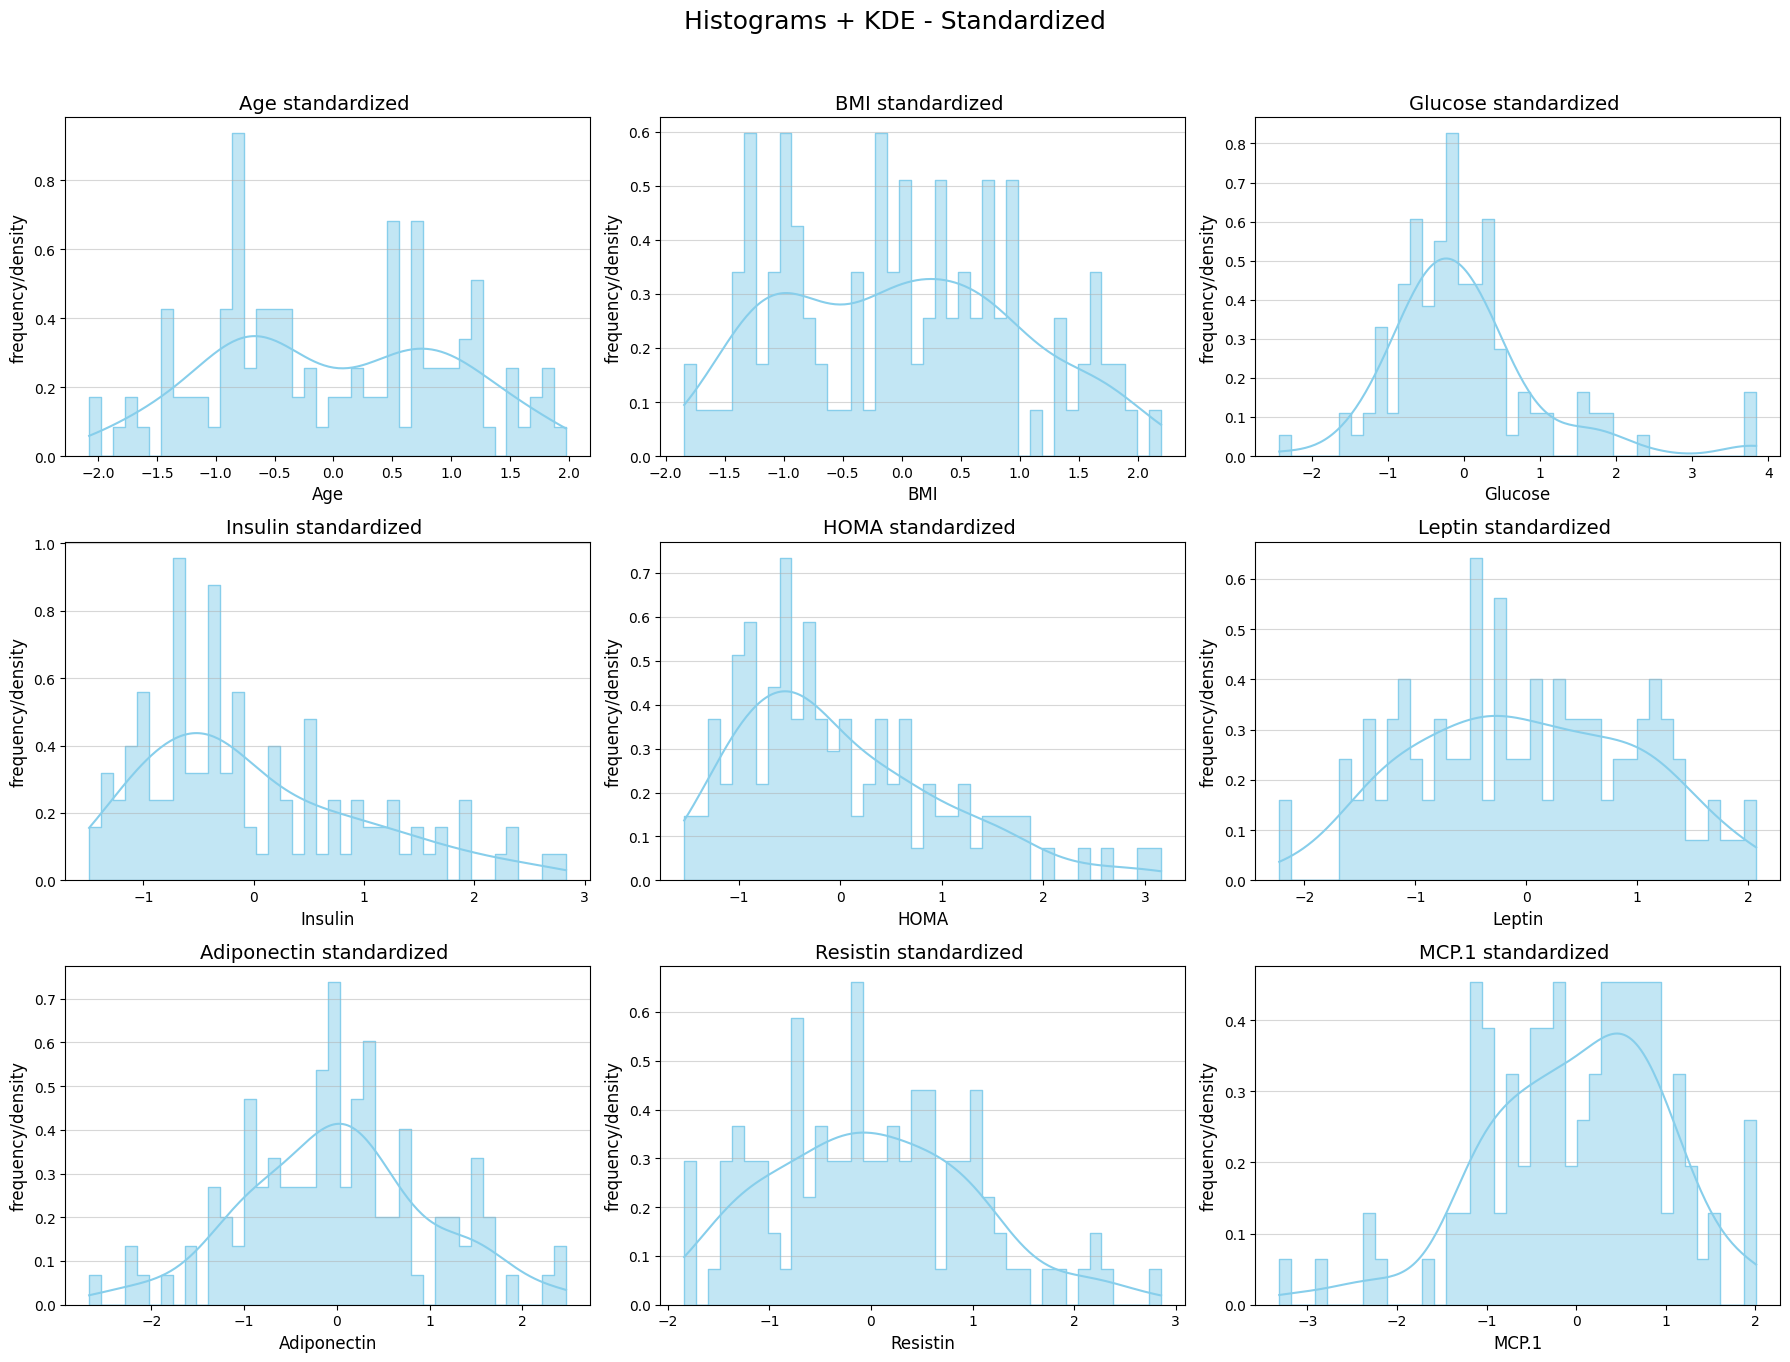

In [10]:
#3) DATA PRE-PROCESSING - AGGREGATE
#z_score applied to all the features of X_processed
X_scaled = X_processed.apply(zscore)

feature_columns = X_scaled.columns.tolist()
n_cols = 3
n_rows = math.ceil(len(feature_columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    ax = axes[i]
    sns.histplot(
        data=X_scaled,
        x=col,
        kde=True,
        bins=40,
        ax=ax,
        color='skyblue',
        element="step",
        stat="density",
        legend=True
    )

    ax.set_title(f'{col} standardized ', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('frequency/density', fontsize=12)
    ax.grid(axis='y', alpha=0.5)

for j in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Histograms + KDE - Standardized', fontsize=18, y=1.0)
plt.show()

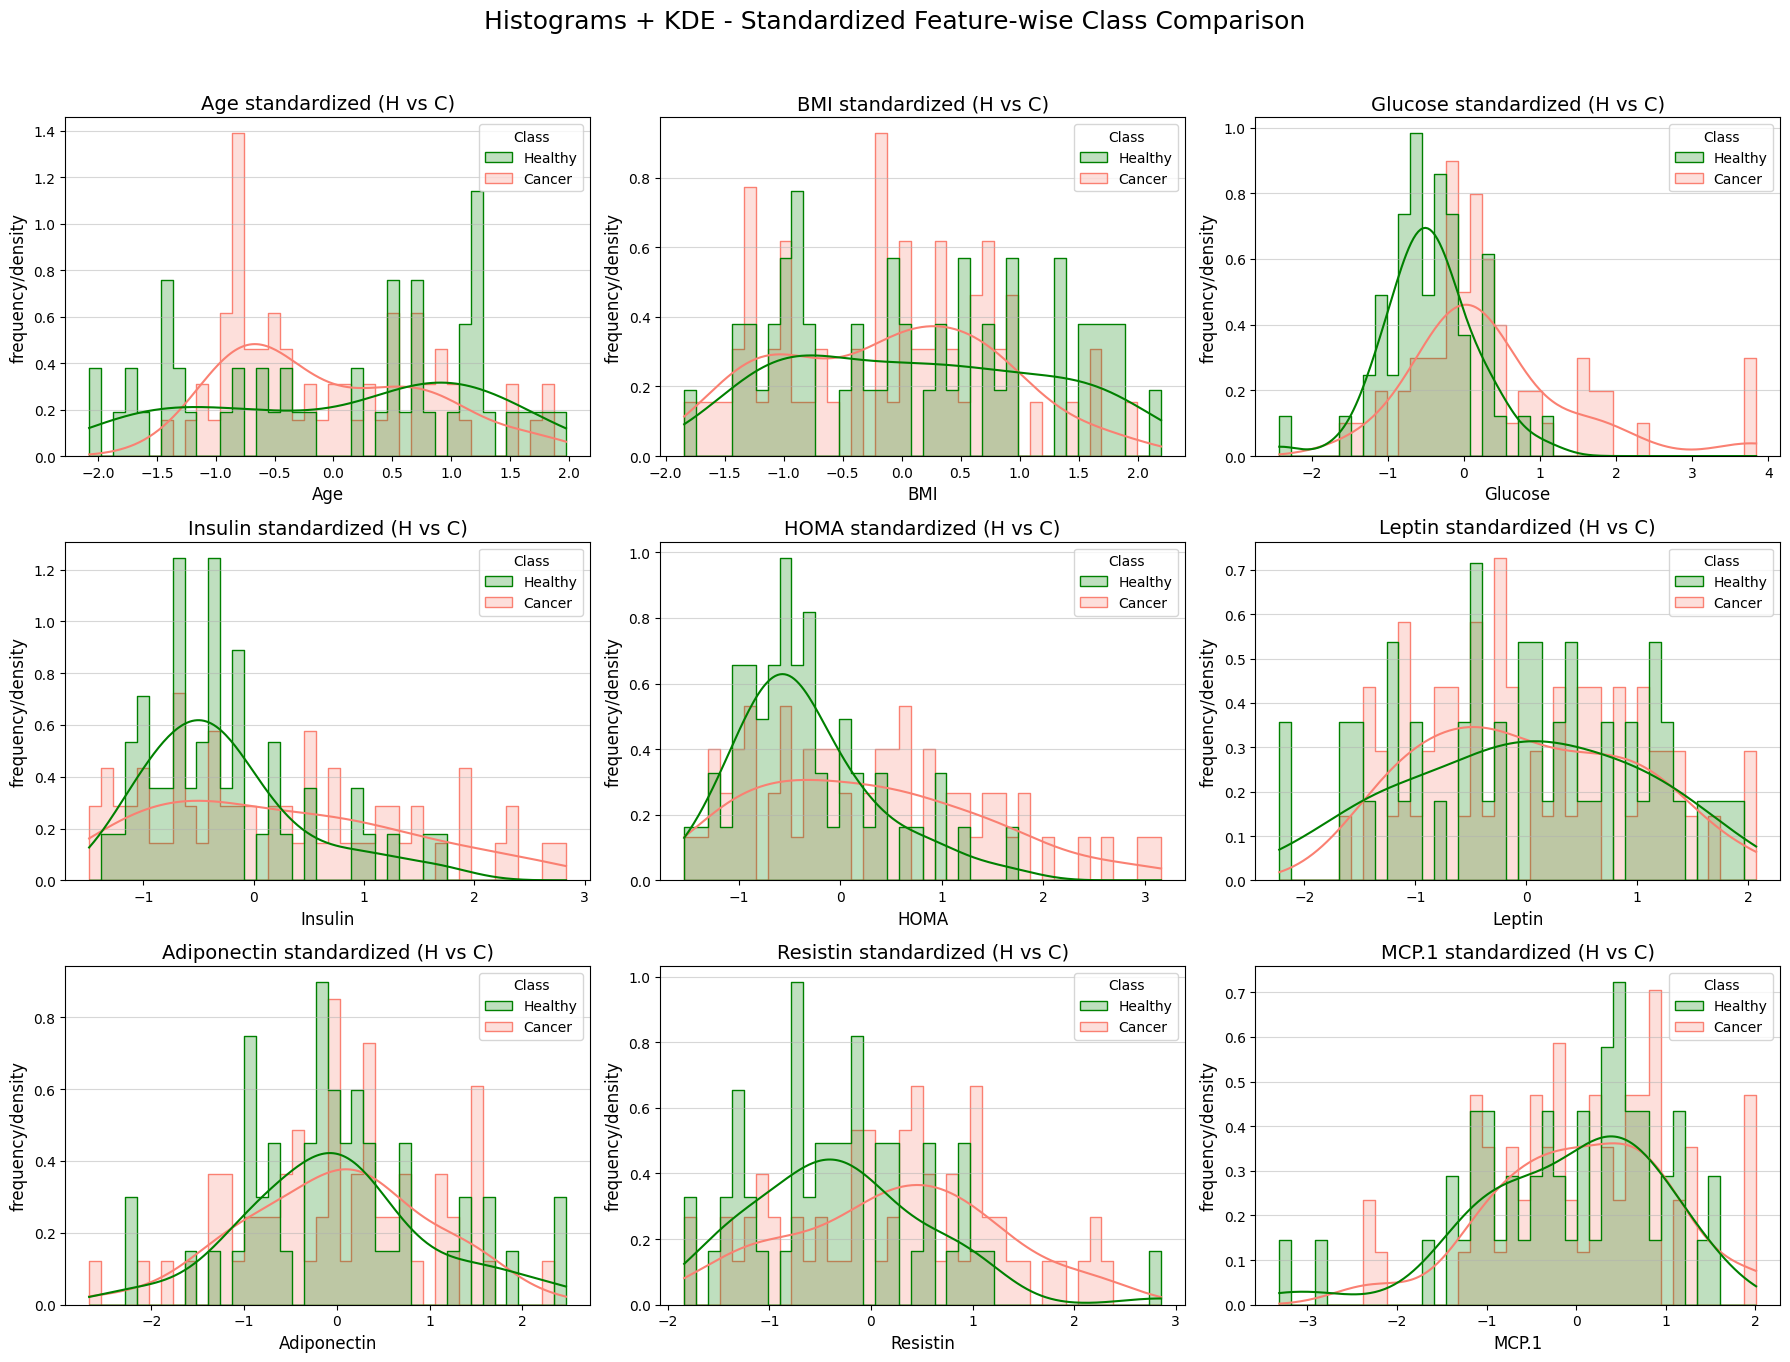

In [11]:
#3) DATA PRE-PROCESSING - CLASS
#histogram + KDE plot for standardized data
plot_df_z = X_scaled.copy()
plot_df_z['Class'] = Y
plot_df_z['Class'] = plot_df_z['Class'].map({1: 'Healthy', 2: 'Cancer'})

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    ax = axes[i]
    sns.histplot(
        data=plot_df_z,
        x=col,
        hue='Class',
        kde=True,
        bins=40,
        ax=ax,
        palette=['green', 'salmon'],
        element="step",
        stat="density",
        common_norm=False,
        legend=True
    )

    ax.set_title(f'{col} standardized (H vs C)', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('frequency/density', fontsize=12)
    ax.grid(axis='y', alpha=0.5)

for j in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Histograms + KDE - Standardized Feature-wise Class Comparison', fontsize=18, y=1.0)
plt.show()

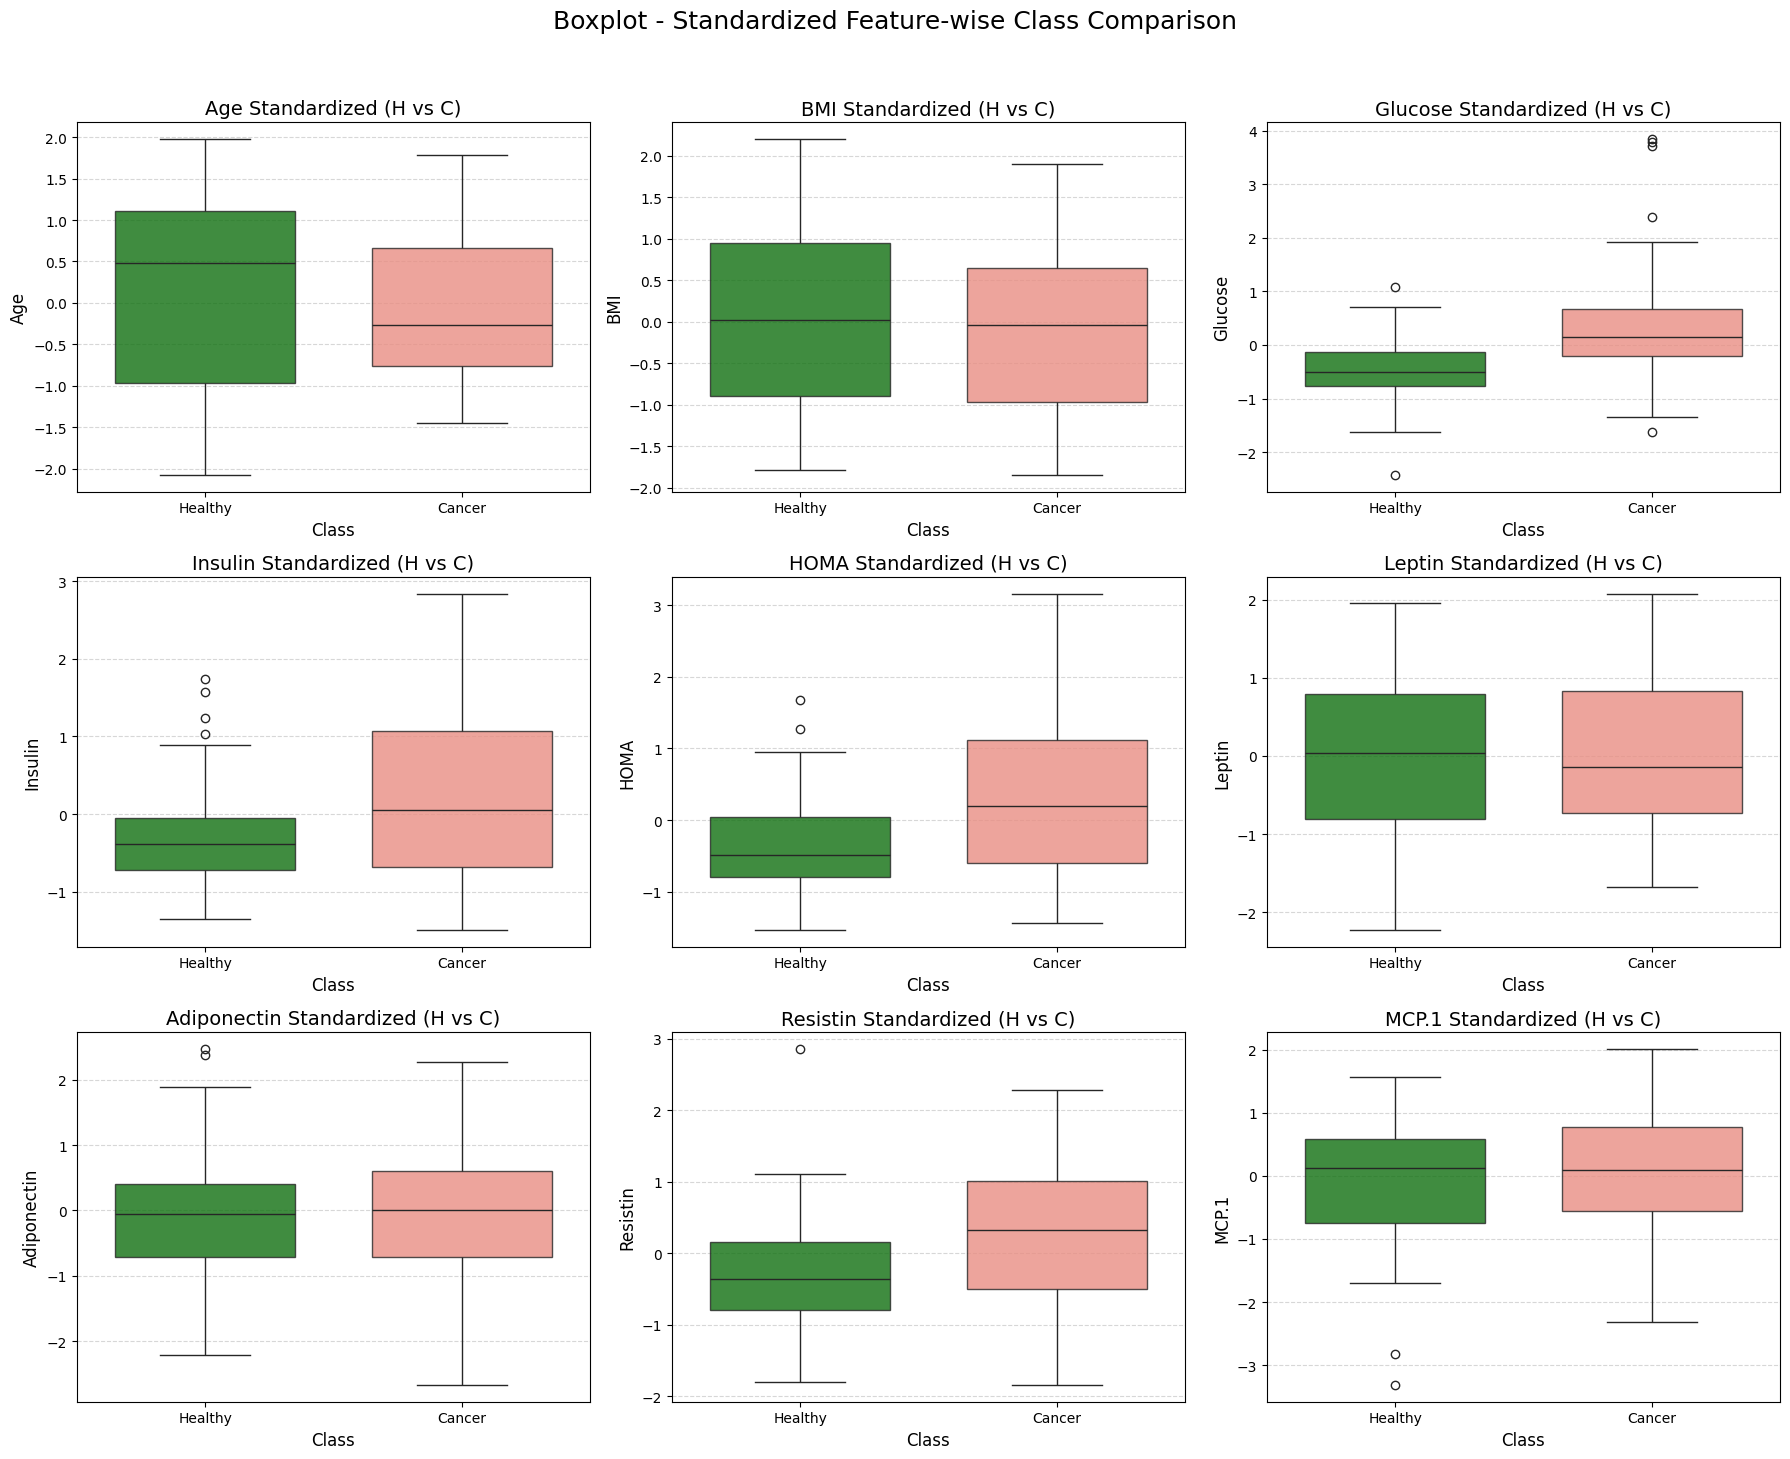

In [12]:
#3) DATA PRE-PROCESSING - CLASS
#boxplot for standardized data
plot_df_z = X_scaled.copy()
plot_df_z['Class'] = Y
plot_df_z['Class'] = plot_df_z['Class'].map({1: 'Healthy', 2: 'Cancer'})

feature_columns = X_scaled.columns.tolist()
n_cols = 3
n_rows = math.ceil(len(feature_columns) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_columns):
    ax = axes[i]

    sns.boxplot(
        x='Class',
        y=col,
        hue='Class',
        legend=False,
        data=plot_df_z,
        ax=ax,
        palette=['green', 'salmon'],
        width=0.7,
        showfliers=True,
        boxprops=dict(alpha=0.8)
    )

    ax.set_title(f'{col} Standardized (H vs C)', fontsize=14)
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    ax.grid(axis='y', alpha=0.5, linestyle='--')

for j in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Boxplot - Standardized Feature-wise Class Comparison', fontsize=18, y=1.0)
plt.show()

In [13]:
#4) DATA PARTITIONING - NESTED K-FOLD CROSS VALIDATION (scaled data)
#dataset divided into train and test sets
X_train_scaled, X_test_scaled, Y_train, Y_test = train_test_split(
    X_scaled, Y,
    test_size=0.2,
    #20% of data for testing
    stratify=Y,
    #proportion of classes in training and testing are the same
    random_state=1
)
print(f"\nTrain size: {len(X_train_scaled)}, Test size: {len(X_test_scaled)}")

#Nested Cross-Validation
#an outer loop for evaluating generalization performance:
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
#divides the training data into four folds, preserving class proportions in each split

for outer_fold_scaled, (train_idx_scaled, val_idx_scaled) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    #training data = 75%; validation data = 25%
    print(f"\nOuter Fold {outer_fold_scaled}")
    X_train_out_scaled, X_val_out_scaled = X_train_scaled.iloc[train_idx_scaled], X_train_scaled.iloc[val_idx_scaled]
    Y_train_out,Y_val_out = Y_train.iloc[train_idx_scaled], Y_train.iloc[val_idx_scaled]
    #PURPOSE: the outer loop provides an unbiased estimate of how the model will perform on unseen data

    #an inner loop for optimizing hyperparameters (for complex classifiers like kNN, SVM, decision trees, random forests):
    inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)
    #ATT: the inner cross-validation is performed within the outer training set (X_train_out)
    for inner_fold_scaled, (inner_train_idx_scaled, inner_val_idx_scaled) in enumerate(inner_cv_scaled.split(X_train_out_scaled, Y_train_out), start=1):
        X_train_inner_scaled, X_val_inner_scaled = X_train_out_scaled.iloc[inner_train_idx_scaled], X_train_out_scaled.iloc[inner_val_idx_scaled]
        Y_train_inner_scaled, Y_val_inner_scaled = Y_train_out.iloc[inner_train_idx_scaled], Y_train_out.iloc[inner_val_idx_scaled]
        #PURPOSE: the inner loop is responsible for hyperparameter tuning or feature selection

        print(f"Inner Fold {inner_fold_scaled}: Train={len(X_train_inner_scaled)}, Val={len(X_val_inner_scaled)}")


Train size: 92, Test size: 24

Outer Fold 1
Inner Fold 1: Train=46, Val=23
Inner Fold 2: Train=46, Val=23
Inner Fold 3: Train=46, Val=23

Outer Fold 2
Inner Fold 1: Train=46, Val=23
Inner Fold 2: Train=46, Val=23
Inner Fold 3: Train=46, Val=23

Outer Fold 3
Inner Fold 1: Train=46, Val=23
Inner Fold 2: Train=46, Val=23
Inner Fold 3: Train=46, Val=23

Outer Fold 4
Inner Fold 1: Train=46, Val=23
Inner Fold 2: Train=46, Val=23
Inner Fold 3: Train=46, Val=23


**NOTE**:

*   **X_tot** = 116 (*100%*);
*   **X_train** = 92 (*80% X_tot*);
*   **X_test** = 24 (*20% X_tot*);
*   **X_train_out** = 69 (*75% X_train*);
*   **X_val_out** = 23 (*25% X_train*);
*   **X_train_inner** = 46 (*66,7% - 2/3 X_train_out*);
*   **X_val_inner**= 23 (*33,3% - 1/3 X_train_out*).

In [14]:
#5) FEATURE SELECTION - KURSKAL-WALLIS H-TEST (relevance)
print("\nKRUSKAL-WALLIS H-TEST\n")
print(f"{'Feature':<15} | {'H-statistic':<15} | {'p-value':<10} | {'Results (p < 0.05)':<25}")
#iterate through each feature in X (original data)
for feature in X.columns:
    #separate data into 'Healthy' (Y=1) and 'Cancer' (Y=2) groups
    group_healthy = X[Y == 1][feature].dropna()
    group_cancer = X[Y == 2][feature].dropna()
    stat, p_value = kruskal(group_healthy, group_cancer)

    result = "✅ Discriminative" if p_value < 0.05 else "❌ Non-discriminative"
    print(f"{feature:<15} | {stat:<15.4f} | {p_value:<10.4f} | {result}")


KRUSKAL-WALLIS H-TEST

Feature         | H-statistic     | p-value    | Results (p < 0.05)       
Age             | 0.5054          | 0.4772     | ❌ Non-discriminative
BMI             | 1.6374          | 0.2007     | ❌ Non-discriminative
Glucose         | 23.9196         | 0.0000     | ✅ Discriminative
Insulin         | 4.9310          | 0.0264     | ✅ Discriminative
HOMA            | 8.8871          | 0.0029     | ✅ Discriminative
Leptin          | 0.0044          | 0.9469     | ❌ Non-discriminative
Adiponectin     | 0.0899          | 0.7643     | ❌ Non-discriminative
Resistin        | 9.6992          | 0.0018     | ✅ Discriminative
MCP.1           | 0.4512          | 0.5018     | ❌ Non-discriminative


**ATT:** Kruskal-Wallis test is non-parametric, meaning it doesn't assume a normal distribution for our data. Because of this, it's often more appropriate and more direct to apply it to the original, non-processed features (X). This way, you're evaluating the discriminative power of the raw features themselves, before any transformations might alter their scale or the nature of their differences.

In [15]:
#5) FEATURE SELECTION - ROC-AUC (relevance)
fnames = X.columns
roc_data = []

for f in fnames:
    fpr, tpr, _ = roc_curve(Y, X[f], pos_label=2)
    #_ ignores the values of the threshold
    original_auc = auc(fpr, tpr)

    adjusted_auc = original_auc
    if original_auc < 0.5:
        adjusted_auc = 1 - original_auc

    roc_data.append((f, adjusted_auc, original_auc, fpr, tpr))

#sort the collected data by the adjusted ROC-AUC score in descending order
sorted_roc_data = sorted(roc_data, key=lambda item: item[1], reverse=True)

#iterate through the sorted data to generate plots
for f_name, adjusted_auc_val, original_auc, fpr, tpr in sorted_roc_data:
    display_fpr = fpr
    display_tpr = tpr
    display_auc = original_auc
    inverted_message = ""

    #apply inversion logic for display purposes if original AUC was < 0.5
    if original_auc < 0.5:
        display_fpr = 1 - fpr
        display_tpr = 1 - tpr
        display_auc = 1 - original_auc
        inverted_message = " (Inverted for AUC > 0.5)"

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=display_fpr, y=display_tpr,
                             mode='lines',
                             name=f'ROC Curve (AUC = {display_auc:.2f})',
                             line=dict(color='darkorange', width=2)))

    fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1],
                             mode='lines',
                             name='Random Classifier (AUC = 0.50)',
                             line=dict(color='navy', width=2, dash='dash')))

    fig.update_layout(
        title=f'ROC Curve for Feature: {f_name}{inverted_message}',
        xaxis_title='False Positive Rate (1 - Specificity)',
        yaxis_title='True Positive Rate (Sensitivity)',
        xaxis=dict(range=[0, 1]),
        yaxis=dict(range=[0, 1]),
        autosize=False,
        width=800,
        height=600,
        showlegend=True
    )
    fig.show()

print("\nFeatures sorted by descending ROC-AUC:")
for f_name, adjusted_auc_val, _, _, _ in sorted_roc_data:
    print(f"{f_name:<15} --> {adjusted_auc_val:.4f}")


Features sorted by descending ROC-AUC:
Glucose         --> 0.7646
Resistin        --> 0.6686
HOMA            --> 0.6614
Insulin         --> 0.6202
BMI             --> 0.5693
Age             --> 0.5385
MCP.1           --> 0.5364
Adiponectin     --> 0.5162
Leptin          --> 0.5036


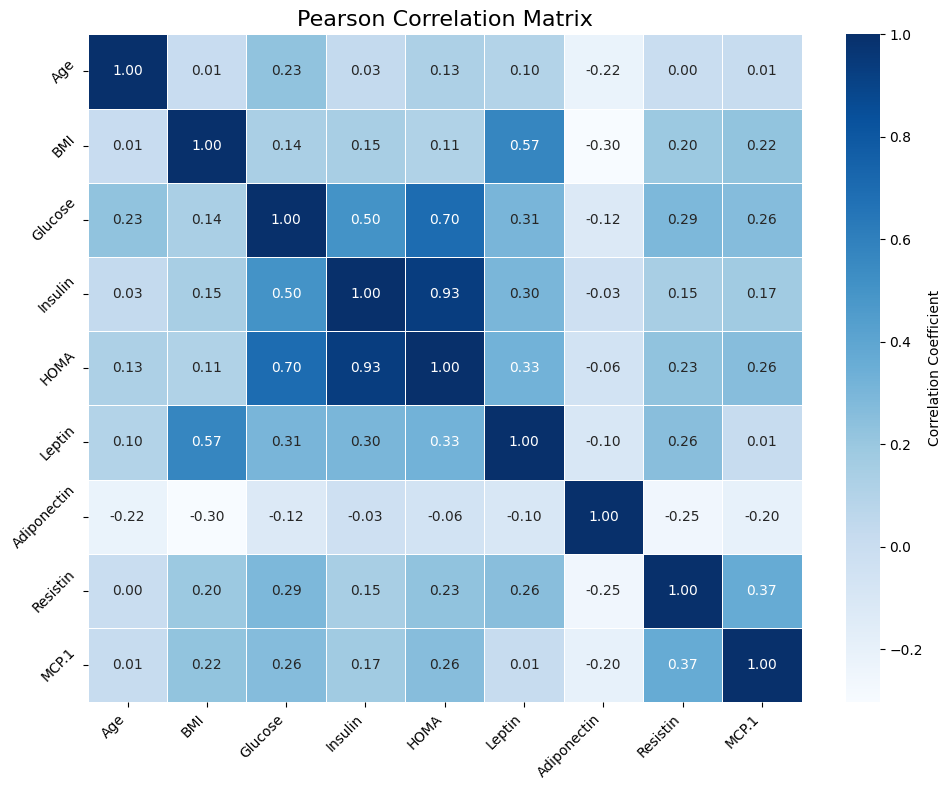

In [16]:
#5) FEATURE SELECTION - CORRELATION MATRIX (redundancy)
correlation_matrix = X.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
#5) FEATURE SELECTION - ELIMINATION BASED ON REDUNDANCY AND RELEVANCE
removed_features = []
auc_threshold = 0.55
high_corr_threshold = 0.9

#step 1: filtering based on AUC relevance
print("\nFiltering features by AUC threshold (AUC > 0.55)")
features_to_keep_auc = []
features_removed_auc = []
for f_name, adjusted_auc_val, _, _, _ in sorted_roc_data:
    if adjusted_auc_val >= auc_threshold:
        features_to_keep_auc.append(f_name)
    else:
        features_removed_auc.append(f_name)
        removed_features.append(f_name)
        print(f"Removed feature '{f_name}' due to AUC score ({adjusted_auc_val:.4f}) below threshold (0.55)")
print(f"Features remaining after AUC filtering: {features_to_keep_auc}")
print(f"Features removed after AUC filtering: {features_removed_auc}")

#step 2: redundancy removal based on correlation
print("\nIdentifying and removing redundant features based on correlation")
redundant_features_to_remove = []
features_considered = features_to_keep_auc.copy()
#uses the new set of features
for i in range(len(features_considered)):
    for j in range(i + 1, len(features_considered)):
        f1 = features_considered[i]
        f2 = features_considered[j]
        corr_val = correlation_matrix.loc[f1, f2]

        if abs(corr_val) > high_corr_threshold:
            print(f"Found highly correlated pair: '{f1}' and '{f2}' (ρ: {corr_val:.2f})")

            auc_f1 = next((item[1] for item in sorted_roc_data if item[0] == f1), None)
            auc_f2 = next((item[1] for item in sorted_roc_data if item[0] == f2), None)
            #look for the value for f1 and f2 of AUC inside sorted_roc_data
            #"next" returns the first value that satisfies the condition

            print(f"AUC for '{f1}': {auc_f1:.4f}")
            print(f"AUC for '{f2}': {auc_f2:.4f}")

            if auc_f1 < auc_f2:
                feature_to_remove = f1
            else:
                feature_to_remove = f2

            if feature_to_remove not in redundant_features_to_remove:
                #verify that the feature hasn't already been eliminated
                redundant_features_to_remove.append(feature_to_remove)
                removed_features.append(feature_to_remove)
                print(f"Removed feature '{feature_to_remove}' from the pair.")

#step 3: final reduced dataset
features_final = [f for f in features_to_keep_auc if f not in redundant_features_to_remove]
X_reduced = X[features_final].copy()

print("\nFeature Selection Summary")
print(f"Original features: {len(X.columns)}")
print(f"Removed for low AUC (< {auc_threshold}): {features_removed_auc}")
print(f"Removed for high correlation (> {high_corr_threshold}): {redundant_features_to_remove}")
print(f"Selected features: {features_final}")
print(f"Shape of X_reduced: {X_reduced.shape}\n")

#step 4: update all datasets only once at the end
columns_final = X_reduced.columns

datasets = {
    "X_processed": X_processed,
    "X_scaled": X_scaled,
    "X_train_scaled": X_train_scaled,
    "X_test_scaled": X_test_scaled,
    "X_train_out_scaled": X_train_out_scaled,
    "X_val_out_scaled": X_val_out_scaled,
    "X_train_inner_scaled": X_train_inner_scaled,
    "X_val_inner_scaled": X_val_inner_scaled
}

for name, df in datasets.items():
    common_cols = [c for c in columns_final if c in df.columns]
    datasets[name] = df[common_cols].copy()
    print(f"Updated {name} shape: {datasets[name].shape}")
    #we are filtering our dataset keeping the columns that appear also in columns_final

#reassign updated datasets
X_processed = datasets["X_processed"]
X_scaled = datasets["X_scaled"]
X_train_scaled = datasets["X_train_scaled"]
X_test_scaled = datasets["X_test_scaled"]
X_train_out_scaled = datasets["X_train_out_scaled"]
X_val_out_scaled = datasets["X_val_out_scaled"]
X_train_inner_scaled = datasets["X_train_inner_scaled"]
X_val_inner_scaled = datasets["X_val_inner_scaled"]

print("All datasets updated.")


Filtering features by AUC threshold (AUC > 0.55)
Removed feature 'Age' due to AUC score (0.5385) below threshold (0.55)
Removed feature 'MCP.1' due to AUC score (0.5364) below threshold (0.55)
Removed feature 'Adiponectin' due to AUC score (0.5162) below threshold (0.55)
Removed feature 'Leptin' due to AUC score (0.5036) below threshold (0.55)
Features remaining after AUC filtering: ['Glucose', 'Resistin', 'HOMA', 'Insulin', 'BMI']
Features removed after AUC filtering: ['Age', 'MCP.1', 'Adiponectin', 'Leptin']

Identifying and removing redundant features based on correlation
Found highly correlated pair: 'HOMA' and 'Insulin' (ρ: 0.93)
AUC for 'HOMA': 0.6614
AUC for 'Insulin': 0.6202
Removed feature 'Insulin' from the pair.

Feature Selection Summary
Original features: 9
Removed for low AUC (< 0.55): ['Age', 'MCP.1', 'Adiponectin', 'Leptin']
Removed for high correlation (> 0.9): ['Insulin']
Selected features: ['Glucose', 'Resistin', 'HOMA', 'BMI']
Shape of X_reduced: (116, 4)

Updated 


PCA ANALYSIS
Cumulative Explained Variance: ['0.471', '0.719', '0.918', '1.000']
R Threshold: 90.00%
Number of Selected Components : 3
Preserved Variance: 91.83%


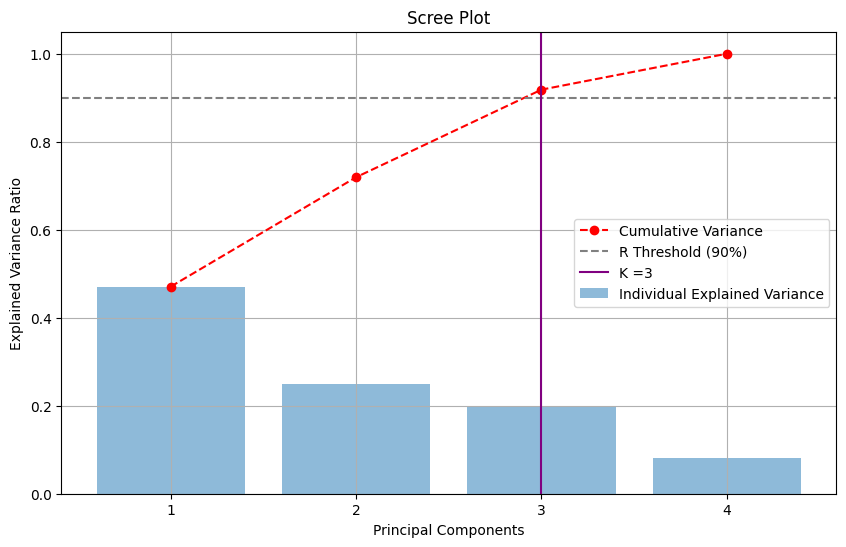


Final training set: 3 columns.


In [18]:
#6) FEATURE REDUCTION - PCA
#initialize PCA without specifying n_components to analyze all possibilities
#this is because, for now, I just want to analyze the importance of each component without reduction
#we look at data structure to decide our K
pca = PCA(n_components=None)
pca.fit(X_scaled)
#explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_
#calculate the cumulative explained variance ratio
cumulative_explained_variance = np.cumsum(explained_variance_ratio)
#ATT: pca.fit doesn't give back transformed data but only these values
R_THRESHOLD = 0.90
#min_variance_threshold_required

#finds the first index for which the variance is over the threshold
#np.argmax give the index (0-based) of the first True value
num_components_selected = np.argmax(cumulative_explained_variance >= R_THRESHOLD) + 1
variance_preserved_at_selection = cumulative_explained_variance[num_components_selected - 1]

#Scree plot
print(f"\nPCA ANALYSIS")
formatted_variance = [f"{x:.3f}" for x in cumulative_explained_variance]
print(f"Cumulative Explained Variance: {formatted_variance}")
print(f"R Threshold: {R_THRESHOLD:.2%}")
print(f"Number of Selected Components : {num_components_selected}")
print(f"Preserved Variance: {variance_preserved_at_selection:.2%}")

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio,
        alpha=0.5, align='center', label='Individual Explained Variance')
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance,
         marker='o', linestyle='--', color='red', label='Cumulative Variance')

plt.axhline(y=R_THRESHOLD, color='gray', linestyle='--', label=f'R Threshold ({R_THRESHOLD:.0%})')
plt.axvline(x=num_components_selected, color='purple', linestyle='-', label=f'K ={num_components_selected}')

plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.legend(loc='best')
plt.grid(True)
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

pca_final = PCA(n_components=num_components_selected)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)
print(f"\nFinal training set: {X_train_pca.shape[1]} columns.")

NOTE: if we were to use **fit_transform()** on *X_test_scaled* as well, we would be allowing the PCA to calculate new directions based on the specific variance of the test data.

This would be **Data Leakage** because the final model (which will be trained later) would implicitly observe the characteristics of the test set (its variance and correlations) before being evaluated. This would lead to unrealistic and overly optimistic performance estimates.

In [19]:
#6) PCA 3D PLOT
pca_plotter = PCA(n_components=num_components_selected)
X_pca_plot = pca_plotter.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    data=X_pca_plot,
    columns=[f'Principal Component {i+1}' for i in range(X_pca_plot.shape[1])]
)
pca_df['Classification'] = Y.map({1: 'Healthy', 2: 'Cancer'})

fig = None
if num_components_selected >= 3:

    fig = go.Figure(data=go.Scatter3d(
        x=pca_df['Principal Component 1'],
        y=pca_df['Principal Component 2'],
        z=pca_df['Principal Component 3'],
        mode='markers',
        marker=dict(
            size=5,
            color=pca_df['Classification'].map({'Healthy': 'green', 'Cancer': 'red'}),
            opacity=0.8
        ),
        hovertemplate=
            '<b>PC1:</b> %{x}<br>'+
            '<b>PC2:</b> %{y}<br>'+
            '<b>PC3:</b> %{z}<br>'+
            '<b>Class:</b> %{text}',
        text=pca_df['Classification']
    ))

    fig.update_layout(
        title='3D PCA Plot',
        title_x=0.5,
        title_y=0.95,
        scene=dict(
            xaxis_title='Principal Component 1',
            yaxis_title='Principal Component 2',
            zaxis_title='Principal Component 3'
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        legend_title_text='Classification'
    )
elif num_components_selected == 2:
    fig = go.Figure(data=go.Scatter(
        x=pca_df['Principal Component 1'],
        y=pca_df['Principal Component 2'],
        mode='markers',
        marker=dict(
            size=8,
            color=pca_df['Classification'].map({'Healthy': 'green', 'Cancer': 'red'}),
            opacity=0.8
        ),
        hovertemplate=
            '<b>PC1:</b> %{x}<br>'+
            '<b>PC2:</b> %{y}<br>'+
            '<b>Class:</b> %{text}',
        text=pca_df['Classification']
    ))

    fig.update_layout(
        title='2D PCA Plot',
        title_x=0.5,
        title_y=0.95,
        xaxis_title='Principal Component 1',
        yaxis_title='Principal Component 2',
        margin=dict(l=0, r=0, b=0, t=40),
        legend_title_text='Classification'
    )
else:
    print("Not enough principal components to create a 2D or 3D plot.")
    fig = None

if fig:
    fig.show()

Original feature dimension: 4
Reduced LDA dimension: 1


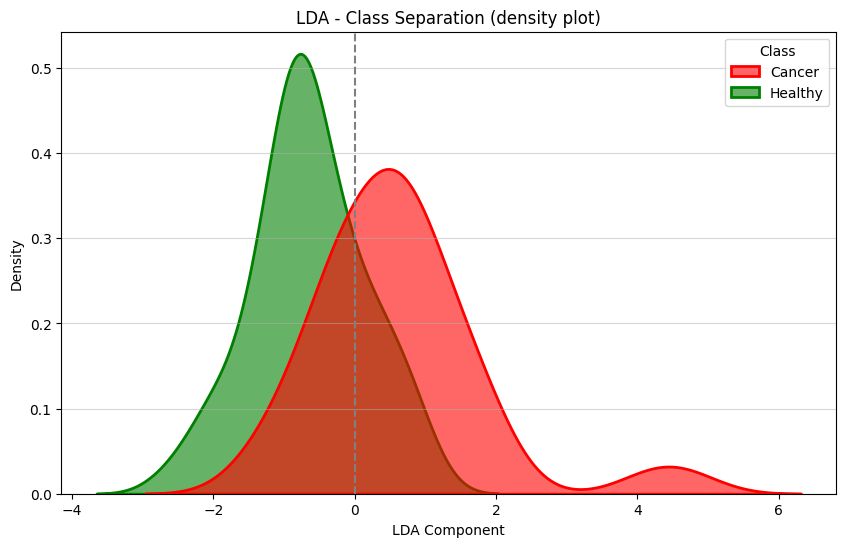

In [20]:
#6) FEATURE REDUCTION - LDA (gaussian plot)
lda_final = LDA(n_components=1)
#MAX for a binary problem
lda_final.fit(X_train_scaled, Y_train)
#here we have also Y beacuse LDA is supervised
X_train_lda = lda_final.transform(X_train_scaled)
X_test_lda  = lda_final.transform(X_test_scaled)

print("Original feature dimension:", X_train_scaled.shape[1])
print("Reduced LDA dimension:", X_train_lda.shape[1])

X_all_lda = np.concatenate([X_train_lda, X_test_lda], axis=0)
Y_all = pd.concat([Y_train, Y_test]).reset_index(drop=True)
#reset_index(drop=True)to preserve order

lda_df = pd.DataFrame(X_all_lda, columns=['LDA'])
lda_df['Class'] = Y_all.map({1: 'Healthy', 2: 'Cancer'})

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=lda_df,
    x='LDA',
    hue='Class',
    fill=True,
    palette={'Healthy': 'green', 'Cancer': 'red'},
    common_norm=False,
    alpha=0.6,
    linewidth=2
)

plt.title('LDA - Class Separation (density plot)')
plt.xlabel('LDA Component')
plt.ylabel('Density')
plt.axvline(x=0, color='gray', linestyle='--')
plt.grid(True, axis='y', alpha=0.5)
plt.show()

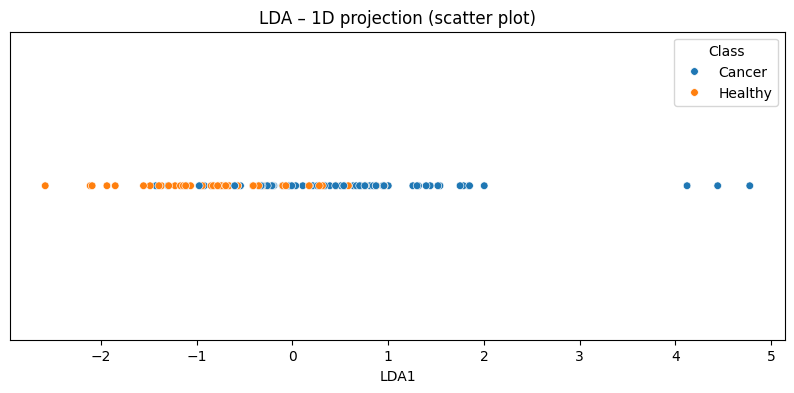

In [21]:
#6) FEATURE REDUCTION - LDA (scatterplot)
lda_df['Y'] = 0.0
plt.figure(figsize=(10, 4))
sns.scatterplot(
    data=lda_df,
    x='LDA',
    y='Y',
    hue='Class',
    s=30
)

plt.yticks([])
plt.ylim(-1, 1)
plt.xlabel('LDA1')
plt.ylabel('')
plt.title('LDA – 1D projection (scatter plot)')
plt.legend(title='Class')
plt.grid(False)
plt.show()

In [22]:
#7) CLASSIFIER: MDC (euclidean + mahalanobis)
#three main methods, one auxiliary and one optional
class MinimumDistanceClassifier:
    def __init__(self, distance_metric='euclidean'):
        if distance_metric not in ['euclidean', 'mahalanobis']:
            raise ValueError("Only 'euclidean' or 'mahalanobis' distance is supported.")
        self.distance_metric = distance_metric
        self.centroids = {}
        self.classes = []
        self.inv_cov_matrices = {}
        #initializes the data structures that will store the statistic parameters needed for the model

    def fit(self, X, y):
        self.classes = np.unique(y)
        for cls in self.classes:
            X_cls = X[y == cls]
            self.centroids[cls] = X_cls.mean(axis=0)
            #mean calculated along the columns (features)

            if self.distance_metric == 'mahalanobis':
                #calculate inverse covariance matrix for each class
                try:
                    cov_matrix = np.cov(X_cls, rowvar=False) #rowvar=False means columns are variables
                    if cov_matrix.shape == (): #handles single feature case
                        cov_matrix = np.array([[cov_matrix]])
                    inv_cov_matrix = np.linalg.inv(cov_matrix + np.eye(cov_matrix.shape[0]) * 1e-6)
                except np.linalg.LinAlgError:
                    #pseudoinverse if inversion fails
                    inv_cov_matrix = np.linalg.pinv(cov_matrix)
                self.inv_cov_matrices[cls] = inv_cov_matrix

        print(f"Model fitted.")
        if self.distance_metric == 'mahalanobis':
            print("Inverse covariance matrices calculated for Mahalanobis distance.")
    #computes the statistic parameters needed (class centroids and inverse covariance matrices for Mahalanobis)

    def _calculate_distances(self, X_sample):
        distances = []
        for cls in self.classes:
            centroid = self.centroids[cls]
            if self.distance_metric == 'euclidean':
                distances.append(euclidean(X_sample, centroid))
            elif self.distance_metric == 'mahalanobis':
                inv_cov_matrix = self.inv_cov_matrices[cls]
                distances.append(mahalanobis(X_sample, centroid, inv_cov_matrix))
        return np.array(distances)
        #computes both the distances between every input sample and all class centroids
        #and returns an array with one distance per class

    def predict(self, X):
        predictions = []
        for _, sample in X.iterrows():
            distances = self._calculate_distances(sample.values)
            predicted_class_index = np.argmin(distances)
            predictions.append(self.classes[predicted_class_index])
        return np.array(predictions)
    #predicts the most likely class for each sample (ex: output: 1)

    def predict_proba(self, X):
        probabilities = []
        epsilon = 1e-10  #small value to prevent division by zero or extremely large scores
        for _, sample in X.iterrows():
            distances = self._calculate_distances(sample.values)

            #convert distances to scores
            scores = 1 / (distances**2 + epsilon)
            #using squared distance inverse for better probability spread

            total_score = np.sum(scores)
            if total_score == 0:
                #if all distances are effectively infinite, assign equal probability
                probs = np.full(len(self.classes), 1/len(self.classes))
            else:
                probs = scores / total_score
            probabilities.append(probs)
        return np.array(probabilities)
    #estimates class belonging probabilities based on inverse distance (ex: ouput: [0,23 0,77])

print("Minimum Distance Classifier (euclidean/mahalanobis) ready to be used.")
#NOTE: centroids are calculated for each class, but each centroid is a feature vector
#which means that it contains the mean value of every variable (feature) for that class

Minimum Distance Classifier (euclidean/mahalanobis) ready to be used.


In [23]:
#GENERAL: FUNCTION TO CALCULATE METRICS
#sensitivity, specificity, precision, F1score and ROC-AUC
def calculate_metrics(y_true, y_pred, y_proba, classes):
    #ensures y_true and y_pred are numpy arrays for consistent indexing
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)

    #confusion matrix (tn, fp, fn, tp)
    tn, fp, fn, tp = confusion_matrix(y_true_np, y_pred_np, labels=classes).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

    #ROC-AUC (assuming class 2 - cancer - as positive class)
    if len(classes) == 2:
        positive_class_index = list(classes).index(2)
        roc_auc = roc_auc_score(y_true_np, y_proba[:, positive_class_index])
    else:
        roc_auc = np.nan

    return {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision':  precision,
        'f1_score':   f1,
        'roc_auc':    roc_auc
    }

In [24]:
#7) PERFORMANCE EVALUATION (euclidean & mahalanobis + training data after feature selection only)
distance_metrics = ['euclidean', 'mahalanobis']
#dictonary, for every distance we store the metrics
mdc_results = {
    dm: {'sensitivity': [], 'specificity': [], 'precision': [],
         'f1_score': [], 'roc_auc': []}
    for dm in distance_metrics
}

outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
for distance_metric in distance_metrics:
    print(f"\nEvaluating Minimum Distance Classifier ({distance_metric.capitalize()}) on selected scaled data")
    for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
        print(f"Outer Fold {outer_fold}")

        X_train_out_scaled = X_train_scaled.iloc[train_idx]
        X_val_out_scaled   = X_train_scaled.iloc[val_idx]
        Y_train_out        = Y_train.iloc[train_idx]
        Y_val_out          = Y_train.iloc[val_idx]

        #initialize and train MDC with selected distance
        mdc = MinimumDistanceClassifier(distance_metric=distance_metric)
        mdc.fit(X_train_out_scaled, Y_train_out)

        #predictions and probabilities on validation set
        y_pred  = mdc.predict(X_val_out_scaled)
        y_proba = mdc.predict_proba(X_val_out_scaled)

        classes = mdc.classes if hasattr(mdc, "classes") else mdc.classes_
        fold_metrics = calculate_metrics(Y_val_out, y_pred, y_proba, classes)
        #store metrics for this fold and this distance
        for metric, value in fold_metrics.items():
            mdc_results[distance_metric][metric].append(value)

for distance_metric in distance_metrics:
    print(f"\nSummary for {distance_metric.capitalize()} MDC on training data")
    for metric, values in mdc_results[distance_metric].items():
        print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")
#mean and SD on the four folds for every metric


Evaluating Minimum Distance Classifier (Euclidean) on selected scaled data
Outer Fold 1
Model fitted.
Outer Fold 2
Model fitted.
Outer Fold 3
Model fitted.
Outer Fold 4
Model fitted.

Evaluating Minimum Distance Classifier (Mahalanobis) on selected scaled data
Outer Fold 1
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
Outer Fold 2
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
Outer Fold 3
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
Outer Fold 4
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.

Summary for Euclidean MDC on training data
Sensitivity: Mean=0.6859, Std=0.0555
Specificity: Mean=0.7591, Std=0.1582
Precision: Mean=0.7917, Std=0.1382
F1_score: Mean=0.7312, Std=0.0787
Roc_auc: Mean=0.7779, Std=0.0813

Summary for Mahalanobis MDC on training data
Sensitivity: Mean=0.9599, Std=0.0401
Specificity: Mean=0.3932, Std=0.1073
Precision: Mean=0.6637, Std=0.

In [25]:
#7) PERFORMANCE EVALUATION (euclidean & mahalanobis + training data after PCA)
distance_metrics = ['euclidean', 'mahalanobis']

mdc_pca_results = {
    dm: {'sensitivity': [], 'specificity': [], 'precision': [],
         'f1_score': [], 'roc_auc': []}
    for dm in distance_metrics
}

outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
for distance_metric in distance_metrics:
    print(f"\nEvaluating Minimum Distance Classifier ({distance_metric.capitalize()}) on PCA-transformed data")
    for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
        print(f"Outer Fold {outer_fold}")

        X_train_out_scaled = X_train_scaled.iloc[train_idx]
        X_val_out_scaled   = X_train_scaled.iloc[val_idx]
        Y_train_out        = Y_train.iloc[train_idx]

        pca_fold = PCA(n_components=num_components_selected)
        X_train_out_pca_np = pca_fold.fit_transform(X_train_out_scaled)
        X_val_out_pca_np = pca_fold.transform(X_val_out_scaled)

        pca_columns = [f'PC{i+1}' for i in range(num_components_selected)]
        X_train_out_pca = pd.DataFrame(X_train_out_pca_np, columns=pca_columns, index=X_train_out_scaled.index)
        X_val_out_pca = pd.DataFrame(X_val_out_pca_np, columns=pca_columns, index=X_val_out_scaled.index)

        mdc = MinimumDistanceClassifier(distance_metric=distance_metric)
        mdc.fit(X_train_out_pca, Y_train_out)

        y_pred  = mdc.predict(X_val_out_pca)
        y_proba = mdc.predict_proba(X_val_out_pca)

        classes = mdc.classes
        fold_metrics = calculate_metrics(Y_val_out, y_pred, y_proba, classes)

        for metric, value in fold_metrics.items():
            mdc_pca_results[distance_metric][metric].append(value)

for distance_metric in distance_metrics:
    print(f"\nSummary for {distance_metric.capitalize()} MDC on PCA-transformed data")
    for metric, values in mdc_pca_results[distance_metric].items():
        print(f"{metric.capitalize()}: Mean={np.nanmean(values):.4f}, Std={np.nanstd(values):.4f}")


Evaluating Minimum Distance Classifier (Euclidean) on PCA-transformed data
Outer Fold 1
Model fitted.
Outer Fold 2
Model fitted.
Outer Fold 3
Model fitted.
Outer Fold 4
Model fitted.

Evaluating Minimum Distance Classifier (Mahalanobis) on PCA-transformed data
Outer Fold 1
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
Outer Fold 2
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
Outer Fold 3
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
Outer Fold 4
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.

Summary for Euclidean MDC on PCA-transformed data
Sensitivity: Mean=0.5625, Std=0.1366
Specificity: Mean=0.6591, Std=0.0394
Precision: Mean=0.6326, Std=0.0832
F1_score: Mean=0.5928, Std=0.1156
Roc_auc: Mean=0.6193, Std=0.0666

Summary for Mahalanobis MDC on PCA-transformed data
Sensitivity: Mean=0.7292, Std=0.0908
Specificity: Mean=0.3636, Std=0.1113
Precision: Mean=

In [26]:
#7) PERFORMANCE EVALUATION (euclidean & mahalanobis + training data after LDA)
distance_metrics = ['euclidean', 'mahalanobis']

mdc_lda_results = {
    dm: {'sensitivity': [], 'specificity': [], 'precision': [],
         'f1_score': [], 'roc_auc': []}
    for dm in distance_metrics
}

for distance_metric in distance_metrics:
    print(f"\nEvaluating Minimum Distance Classifier ({distance_metric.capitalize()}) on LDA-transformed data")
    for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
        print(f"Outer Fold {outer_fold}")

        X_train_out_scaled = X_train_scaled.iloc[train_idx]
        X_val_out_scaled   = X_train_scaled.iloc[val_idx]
        Y_train_out        = Y_train.iloc[train_idx]
        Y_val_out          = Y_train.iloc[val_idx]

        if len(np.unique(Y_train_out)) < 2:
            #if we have only one class, the LDA cannot be applied
            print("Skipping LDA evaluation: only one class present in training data for this fold.")
            for metric in mdc_lda_results[distance_metric].keys():
                mdc_lda_results[distance_metric][metric].append(np.nan)
            continue

        lda_fold = LDA(n_components=1)
        X_train_out_lda_np = lda_fold.fit_transform(X_train_out_scaled, Y_train_out)
        X_val_out_lda_np = lda_fold.transform(X_val_out_scaled)

        lda_columns = [f'LD{i+1}' for i in range(X_train_out_lda_np.shape[1])]
        X_train_out_lda = pd.DataFrame(X_train_out_lda_np, columns=lda_columns, index=X_train_out_scaled.index)
        X_val_out_lda = pd.DataFrame(X_val_out_lda_np, columns=lda_columns, index=X_val_out_scaled.index)

        mdc = MinimumDistanceClassifier(distance_metric=distance_metric)
        mdc.fit(X_train_out_lda, Y_train_out)

        y_pred  = mdc.predict(X_val_out_lda)
        y_proba = mdc.predict_proba(X_val_out_lda)

        classes = mdc.classes
        fold_metrics = calculate_metrics(Y_val_out, y_pred, y_proba, classes)

        for metric, value in fold_metrics.items():
            mdc_lda_results[distance_metric][metric].append(value)

for distance_metric in distance_metrics:
    print(f"\nSummary for {distance_metric.capitalize()} MDC on LDA-transformed data")
    for metric, values in mdc_lda_results[distance_metric].items():
        print(f"{metric.capitalize()}: Mean={np.nanmean(values):.4f}, Std={np.nanstd(values):.4f}")


Evaluating Minimum Distance Classifier (Euclidean) on LDA-transformed data
Outer Fold 1
Model fitted.
Outer Fold 2
Model fitted.
Outer Fold 3
Model fitted.
Outer Fold 4
Model fitted.

Evaluating Minimum Distance Classifier (Mahalanobis) on LDA-transformed data
Outer Fold 1
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
Outer Fold 2
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
Outer Fold 3
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
Outer Fold 4
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.

Summary for Euclidean MDC on LDA-transformed data
Sensitivity: Mean=0.6859, Std=0.1094
Specificity: Mean=0.7864, Std=0.1761
Precision: Mean=0.8253, Std=0.1429
F1_score: Mean=0.7344, Std=0.0687
Roc_auc: Mean=0.7588, Std=0.0818

Summary for Mahalanobis MDC on LDA-transformed data
Sensitivity: Mean=0.7244, Std=0.1300
Specificity: Mean=0.7864, Std=0.1761
Precision: Mean=

In [27]:
#7) PERFORMANCE EVALUATION (euclidean & mahalanobis + test data)
distance_metrics = ['euclidean', 'mahalanobis']

test_results = {
    'Original Scaled': {},
    'PCA-Reduced': {},
    'LDA-Reduced': {}
}

#1) TEST ON SELECTED SCALED DATA
print("\nFinal Test Evaluation: Original Scaled Data")
for dm in distance_metrics:
    print(f"\nMinimum Distance Classifier ({dm})")

    mdc_final = MinimumDistanceClassifier(distance_metric=dm)
    mdc_final.fit(X_train_scaled, Y_train)

    y_test_pred  = mdc_final.predict(X_test_scaled)
    y_test_proba = mdc_final.predict_proba(X_test_scaled)

    classes = mdc_final.classes if hasattr(mdc_final, "classes") else mdc_final.classes_
    final_metrics = calculate_metrics(Y_test, y_test_pred, y_test_proba, classes)

    test_results['Original Scaled'][dm] = final_metrics

    for k, v in final_metrics.items():
        print(f"{k}: {v:.4f}")

#2) TEST ON PCA-REDUCED DATA
print("\nFinal Test Evaluation: PCA-Reduced Data")

pca_final = PCA(n_components=num_components_selected)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

pca_cols      = [f'PC{i+1}' for i in range(num_components_selected)]
X_train_pcaDF = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train_scaled.index)
X_test_pcaDF  = pd.DataFrame(X_test_pca,  columns=pca_cols, index=X_test_scaled.index)

for dm in distance_metrics:
    print(f"\nMinimum Distance Classifier ({dm}) on PCA data")

    mdc_final = MinimumDistanceClassifier(distance_metric=dm)
    mdc_final.fit(X_train_pcaDF, Y_train)

    y_test_pred  = mdc_final.predict(X_test_pcaDF)
    y_test_proba = mdc_final.predict_proba(X_test_pcaDF)

    classes = mdc_final.classes if hasattr(mdc_final, "classes") else mdc_final.classes_
    final_metrics = calculate_metrics(Y_test, y_test_pred, y_test_proba, classes)

    test_results['PCA-Reduced'][dm] = final_metrics

    for k, v in final_metrics.items():
        print(f"{k}: {v:.4f}")
#k = key (metrics); v = value.

#3) TEST ON LDA-REDUCED DATA
print("\nFinal Test Evaluation: LDA-Reduced Data")

lda_final = LDA(n_components=1)
X_train_lda = lda_final.fit_transform(X_train_scaled, Y_train)
X_test_lda  = lda_final.transform(X_test_scaled)

lda_cols      = ['LDA1']
X_train_ldaDF = pd.DataFrame(X_train_lda, columns=lda_cols, index=X_train_scaled.index)
X_test_ldaDF  = pd.DataFrame(X_test_lda,  columns=lda_cols, index=X_test_scaled.index)

for dm in distance_metrics:
    print(f"\nMinimum Distance Classifier ({dm}) on LDA data")

    mdc_final = MinimumDistanceClassifier(distance_metric=dm)
    mdc_final.fit(X_train_ldaDF, Y_train)

    y_test_pred  = mdc_final.predict(X_test_ldaDF)
    y_test_proba = mdc_final.predict_proba(X_test_ldaDF)

    classes = mdc_final.classes if hasattr(mdc_final, "classes") else mdc_final.classes_
    final_metrics = calculate_metrics(Y_test, y_test_pred, y_test_proba, classes)

    test_results['LDA-Reduced'][dm] = final_metrics

    for k, v in final_metrics.items():
        print(f"{k}: {v:.4f}")
#NOTE: LDA results are the same for euclidean and mahalanobis classifier
#due to the fact that LDA reduces the problem to a single optimal dimension
#causing the Mahalanobis and Euclidean MDC decision boundaries to mathematically coincide


Final Test Evaluation: Original Scaled Data

Minimum Distance Classifier (euclidean)
Model fitted.
sensitivity: 0.5385
specificity: 0.9091
precision: 0.8750
f1_score: 0.6667
roc_auc: 0.7622

Minimum Distance Classifier (mahalanobis)
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
sensitivity: 0.9231
specificity: 0.3636
precision: 0.6316
f1_score: 0.7500
roc_auc: 0.8252

Final Test Evaluation: PCA-Reduced Data

Minimum Distance Classifier (euclidean) on PCA data
Model fitted.
sensitivity: 0.5385
specificity: 0.9091
precision: 0.8750
f1_score: 0.6667
roc_auc: 0.7902

Minimum Distance Classifier (mahalanobis) on PCA data
Model fitted.
Inverse covariance matrices calculated for Mahalanobis distance.
sensitivity: 0.7692
specificity: 0.5455
precision: 0.6667
f1_score: 0.7143
roc_auc: 0.7902

Final Test Evaluation: LDA-Reduced Data

Minimum Distance Classifier (euclidean) on LDA data
Model fitted.
sensitivity: 0.7692
specificity: 0.5455
precision: 0.6667
f1_sco

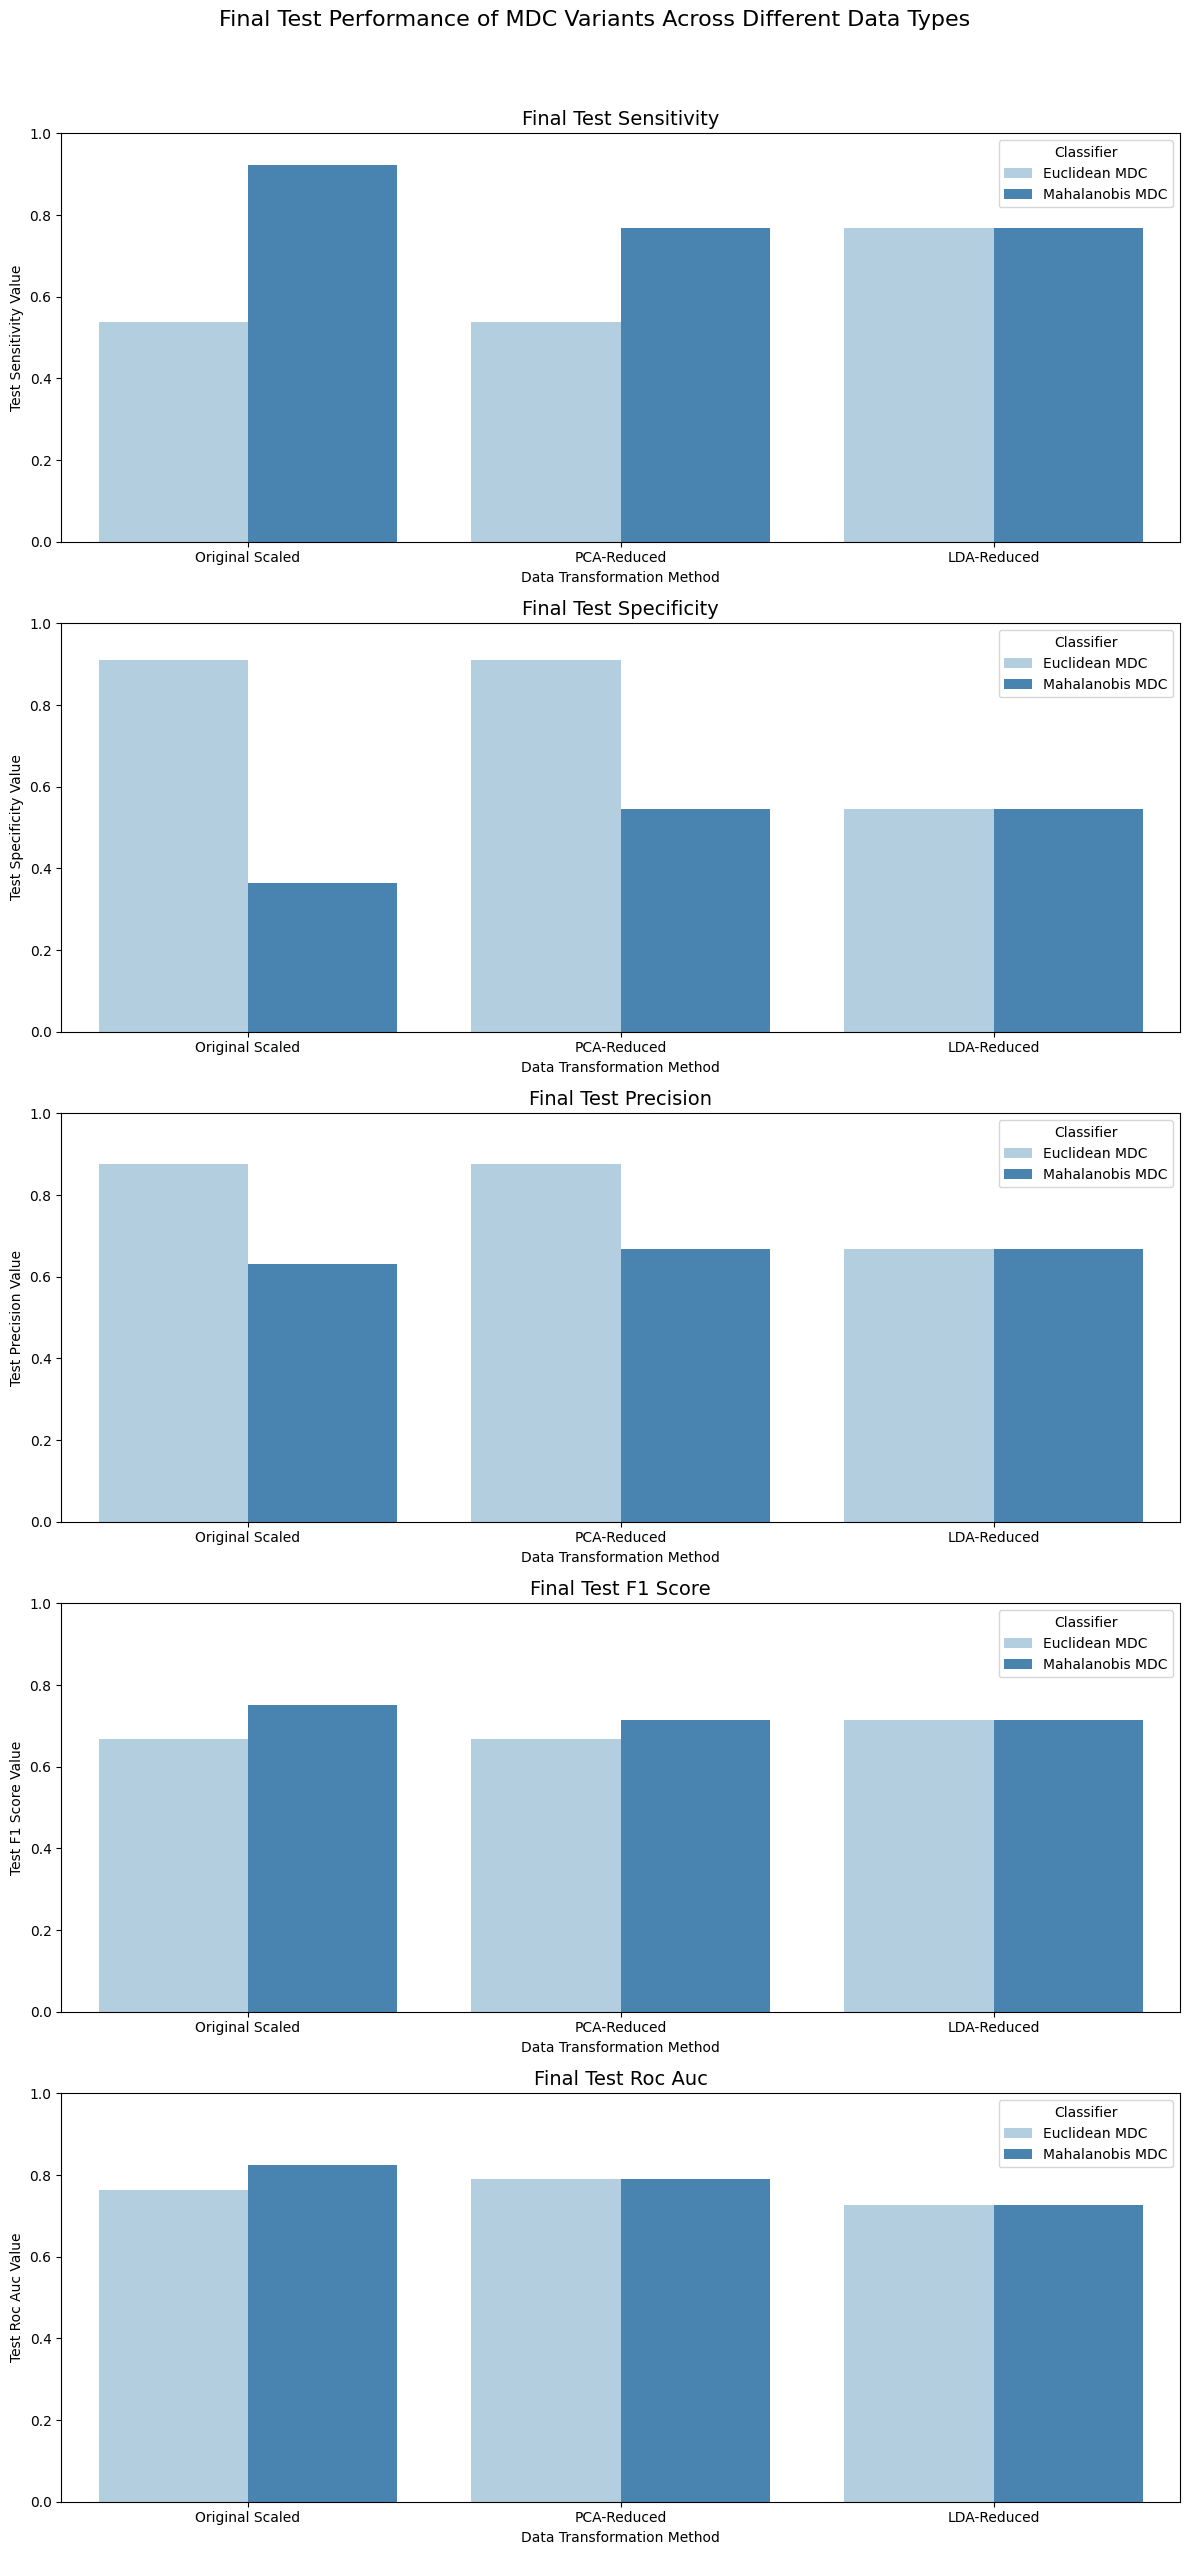

In [28]:
#7) PERFORMANCE EVALUATION (comparison between prediction test results)
data_for_plot_test = []
metrics_to_plot = ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']

#loop on data types
for data_type_name, classifiers in test_results.items():
    #loop on classifiers
    for dm, final_metrics in classifiers.items():
        classifier_name = f"{dm.capitalize()} MDC"
        #loop on metrics
        for metric_name in metrics_to_plot:
            value = final_metrics.get(metric_name)
            if value is None:
                continue
            data_for_plot_test.append({
                'Classifier': classifier_name,
                'Data Type': data_type_name,
                'Metric': metric_name.replace('_', ' ').title(),
                'Value': value,
                'Std': 0.0
            })

plot_df_test = pd.DataFrame(data_for_plot_test)
#comparative plots for each metric
fig, axes = plt.subplots(nrows=len(metrics_to_plot), ncols=1, figsize=(12, 5 * len(metrics_to_plot)))
fig.suptitle('Final Test Performance of MDC Variants Across Different Data Types', fontsize=16, y=1.02)
for i, metric_name_raw in enumerate(metrics_to_plot):
    metric_name_formatted = metric_name_raw.replace('_', ' ').title()

    df_metric = plot_df_test[plot_df_test['Metric'] == metric_name_formatted]
    sns.barplot(
        data=df_metric,
        x='Data Type',
        y='Value',
        hue='Classifier',
        ax=axes[i],
        palette='Blues',
        errorbar=None
    )

    axes[i].set_title(f'Final Test {metric_name_formatted}', fontsize=14)
    axes[i].set_ylabel(f'Test {metric_name_formatted} Value')
    axes[i].set_xlabel('Data Transformation Method')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Classifier')
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [29]:
#8) PERFORMANCE EVALUATION (Fisher LDA on original scaled data)
print("\nFinal Test Evaluation: Fisher LDA on Original Scaled Data")
lda_scaled = LDA(n_components=1)
lda_scaled.fit(X_train_scaled, Y_train)

y_test_pred_scaled  = lda_scaled.predict(X_test_scaled)
y_test_proba_scaled = lda_scaled.predict_proba(X_test_scaled)

final_metrics_lda = calculate_metrics(Y_test, y_test_pred_scaled, y_test_proba_scaled, lda_scaled.classes_)
test_results['Original Scaled']['Fisher LDA'] = final_metrics_lda

for k, v in final_metrics_lda.items():
    print(f"{k}: {v:.4f}")


Final Test Evaluation: Fisher LDA on Original Scaled Data
  sensitivity: 0.7692
  specificity: 0.5455
  precision: 0.6667
  f1_score: 0.7143
  roc_auc: 0.7622


In [30]:
#8) PERFORMANCE EVALUATION (Fisher LDA on PCA data)
print("\nFinal Test Evaluation: Fisher LDA on PCA-Reduced Data")
pca_final = PCA(n_components=num_components_selected)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

pca_cols      = [f'PC{i+1}' for i in range(num_components_selected)]
X_train_pcaDF = pd.DataFrame(X_train_pca, columns=pca_cols, index=X_train_scaled.index)
X_test_pcaDF  = pd.DataFrame(X_test_pca,  columns=pca_cols, index=X_test_scaled.index)

lda_pca = LDA(n_components=1)
lda_pca.fit(X_train_pcaDF, Y_train)

y_test_pred_pca  = lda_pca.predict(X_test_pcaDF)
y_test_proba_pca = lda_pca.predict_proba(X_test_pcaDF)

final_metrics_lda_pca = calculate_metrics(Y_test, y_test_pred_pca, y_test_proba_pca, lda_pca.classes_)
test_results['PCA-Reduced']['Fisher LDA'] = final_metrics_lda_pca

for k, v in final_metrics_lda_pca.items():
    print(f"{k}: {v:.4f}")


Final Test Evaluation: Fisher LDA on PCA-Reduced Data
  sensitivity: 0.7692
  specificity: 0.6364
  precision: 0.7143
  f1_score: 0.7407
  roc_auc: 0.7972


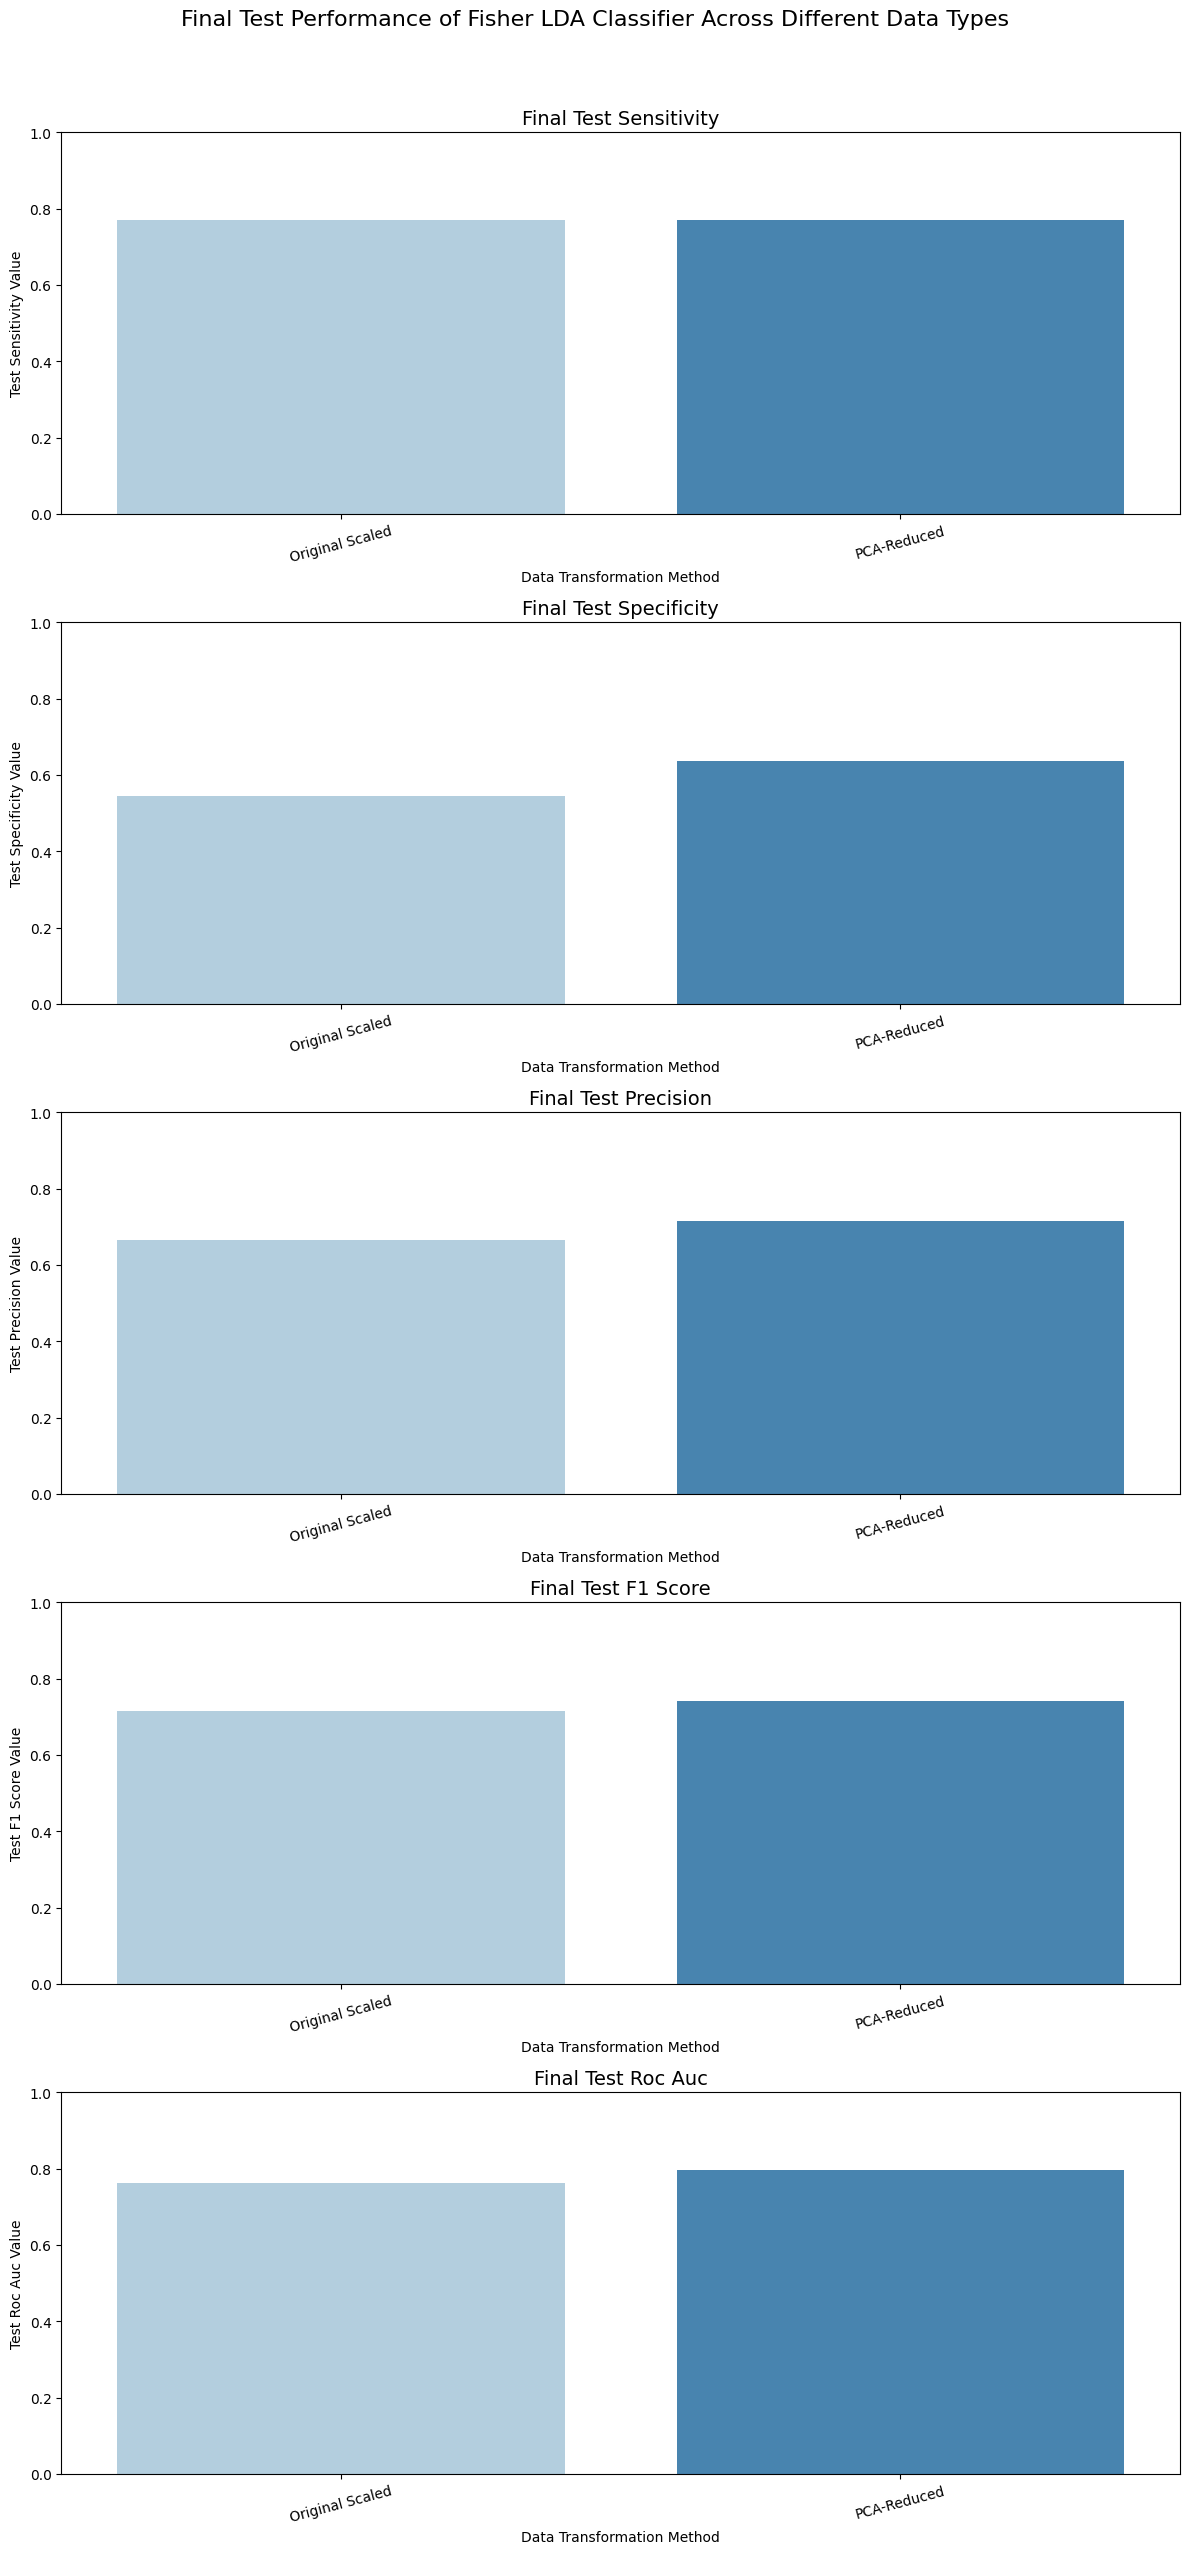

In [31]:
#8) PERFORMANCE EVALUATION (comparison between prediction test results)
data_for_plot_test_lda = []
metrics_to_plot_lda = ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']

for data_type_name in ['Original Scaled', 'PCA-Reduced']:
    if data_type_name in test_results:
        classifiers = test_results[data_type_name]
        if 'Fisher LDA' in classifiers:
            classifier_name = 'Fisher LDA Classifier'
            final_metrics = classifiers['Fisher LDA']
            for metric_name in metrics_to_plot_lda:
                value = final_metrics.get(metric_name)
                if value is None:
                    continue
                data_for_plot_test_lda.append({
                    'Classifier': classifier_name,
                    'Data Type': data_type_name,
                    'Metric': metric_name.replace('_', ' ').title(),
                    'Value': value,
                    'Std': 0.0
                })

plot_df_test_lda = pd.DataFrame(data_for_plot_test_lda)
fig, axes = plt.subplots(nrows=len(metrics_to_plot_lda), ncols=1, figsize=(12, 5 * len(metrics_to_plot_lda)))
fig.suptitle('Final Test Performance of Fisher LDA Classifier Across Different Data Types', fontsize=16, y=1.02)
for i, metric_name_raw in enumerate(metrics_to_plot_lda):
    metric_name_formatted = metric_name_raw.replace('_', ' ').title()

    df_metric = plot_df_test_lda[plot_df_test_lda['Metric'] == metric_name_formatted]
    sns.barplot(
        data=df_metric,
        x='Data Type',
        y='Value',
        hue='Data Type',
        ax=axes[i],
        palette='Blues',
        errorbar=None,
        legend=False
    )

    axes[i].set_title(f'Final Test {metric_name_formatted}', fontsize=14)
    axes[i].set_ylabel(f'Test {metric_name_formatted} Value')
    axes[i].set_xlabel('Data Transformation Method')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [32]:
#9) CLASSIFIER: BAYES CLASSIFIER
#three main methods and two auxiliary methods
class BayesianClassifier:
    def __init__(self):
        self.priors = {}
        self.means = {}
        self.covariances = {}
        self.classes = []
    #initializes the data structures that will store the statistic parameters needed for the model

    def fit(self, X, y):
        self.classes = np.unique(y)
        #identify the classes
        num_samples = len(X)
        for cls in self.classes:
            X_cls = X[y == cls]
            #calculate prior probability for the class
            self.priors[cls] = len(X_cls) / num_samples
            #calculate mean vector for the class
            self.means[cls] = X_cls.mean(axis=0)
            #calculate covariance matrix for the class
            #add a small value to the diagonal for numerical stability (avoid singular matrix)
            self.covariances[cls] = np.cov(X_cls, rowvar=False) + np.eye(X.shape[1]) * 1e-6
            #here is the difference with the Naive Bayes
        print("Bayesian Classifier fitted. Class priors, means, and covariances calculated.")
    #computes the statistic parameters needed (prior, mean and covariance)

    def _calculate_likelihood(self, x_sample, cls):
        mean = self.means[cls]
        covariance = self.covariances[cls]
        try:
            return multivariate_normal.pdf(x_sample, mean=mean, cov=covariance)
        except np.linalg.LinAlgError:
            #handle cases where covariance matrix might still be problematic
            print(f"Warning: singular covariance matrix for class {cls}. Using pseudoinverse.")
            return multivariate_normal.pdf(x_sample, mean=mean, cov=np.linalg.pinv(covariance))
    #computes likelihood

    def predict_proba(self, X):
        probabilities = []
        for _, sample in X.iterrows():
            posteriors = {}
            total_posterior = 0
            for cls in self.classes:
                #P(C_k|x) = P(x|C_k) * P(C_k) / P(x)
                #here we calculate P(x|C_k) * P(C_k), which is proportional to posterior
                likelihood = self._calculate_likelihood(sample.values, cls)
                posteriors[cls] = likelihood * self.priors[cls]
                total_posterior += posteriors[cls]

            #normalize to get actual probabilities
            if total_posterior == 0:
                #if all posteriors are zero, assign equal probability to all classes
                probs = np.full(len(self.classes), 1 / len(self.classes))
            else:
                probs = np.array([posteriors[cls] / total_posterior for cls in self.classes])
            probabilities.append(probs)
        return np.array(probabilities)
     #crucial step: Bayes theorem applied

    def predict(self, X, cost_ratio=1.0):
        if len(self.classes) != 2:
            print("Warning: binary problems only.")
            #back to predict the class with the highest probability
            proba = self.predict_proba(X)
            return np.array([self.classes[np.argmax(p)] for p in proba])

        proba = self.predict_proba(X)
        #get probabilities for each class
        #and predict the class with the highest probability
        P_H_given_x = proba[:, 0]  #P(C_0|x)
        P_C_given_x = proba[:, 1] #P(C_1|x)

        predictions = []
        #predict cancer (C_1) if P(C|x) / P(H|x) > cost_ratio
        for i in range(len(X)):
            if P_H_given_x[i] == 0:
                predictions.append(self.classes[1])
                continue
            #to avoid division by zero

            ratio_P = P_C_given_x[i] / P_H_given_x[i]
            if ratio_P > cost_ratio:
                #if the probability ratio is greater than the cost ratio (C_FP / C_FN)
                #we minimize the risk: predict the positive class (cancer)
                predictions.append(self.classes[1]) #cancer
            else:
                predictions.append(self.classes[0]) #healthy

        return np.array(predictions)

print("Bayesian Classifier ready to be used.")

Bayesian Classifier ready to be used.


In [33]:
#9) PERFORMANCE EVALUATION (Bayes selected scaled data)
COST_RATIO_MAP = 1.0
COST_RATIO_CS = 0.3

bayesian_results_MAP = {
    'sensitivity': [], 'specificity': [], 'precision': [],
    'f1_score': [], 'roc_auc': []
}
bayesian_results_CS = {
    'sensitivity': [], 'specificity': [], 'precision': [],
    'f1_score': [], 'roc_auc': []
}

print("\nEvaluating Bayesian Classifier (MAP and CS) on selected scaled data")
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out_scaled = X_train_scaled.iloc[train_idx]
    X_val_out_scaled   = X_train_scaled.iloc[val_idx]
    Y_train_out        = Y_train.iloc[train_idx]
    Y_val_out          = Y_train.iloc[val_idx]

    bc = BayesianClassifier()
    bc.fit(X_train_out_scaled, Y_train_out)
    classes = bc.classes

    y_proba = bc.predict_proba(X_val_out_scaled)

    #MAP evaluation
    y_pred_map = bc.predict(X_val_out_scaled, cost_ratio=COST_RATIO_MAP)
    fold_metrics_map = calculate_metrics(Y_val_out, y_pred_map, y_proba, classes)

    for metric, value in fold_metrics_map.items():
        bayesian_results_MAP[metric].append(value)

    #CS evaluation
    y_pred_cs = bc.predict(X_val_out_scaled, cost_ratio=COST_RATIO_CS)
    fold_metrics_cs = calculate_metrics(Y_val_out, y_pred_cs, y_proba, classes)

    for metric, value in fold_metrics_cs.items():
        bayesian_results_CS[metric].append(value)

print("\nSummary: Selected Scaled Data")
print("\nMAP (Ratio 1.0)")
for metric, values in bayesian_results_MAP.items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")

print("\nCS (Ratio 0.3)")
for metric, values in bayesian_results_CS.items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")


Evaluating Bayesian Classifier (MAP and CS) on selected scaled data

Outer Fold 1
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Outer Fold 2
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Outer Fold 3
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Outer Fold 4
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Summary: Selected Scaled Data

MAP (Ratio 1.0)
Sensitivity: Mean=0.7468, Std=0.0590
Specificity: Mean=0.7523, Std=0.1149
Precision: Mean=0.7962, Std=0.0822
F1_score: Mean=0.7705, Std=0.0695
Roc_auc: Mean=0.8065, Std=0.0503

CS (Ratio 0.3)
Sensitivity: Mean=0.9792, Std=0.0361
Specificity: Mean=0.3682, Std=0.0897
Precision: Mean=0.6588, Std=0.0527
F1_score: Mean=0.7872, Std=0.0482
Roc_auc: Mean=0.8065, Std=0.0503


In [34]:
#9) PERFORMANCE EVALUATION (Bayes PCA-transformed data)
COST_RATIO_MAP = 1.0
COST_RATIO_CS = 0.3

bayesian_results_MAP_PCA = {
    'sensitivity': [], 'specificity': [], 'precision': [],
    'f1_score': [], 'roc_auc': []
}
bayesian_results_CS_PCA = {
    'sensitivity': [], 'specificity': [], 'precision': [],
    'f1_score': [], 'roc_auc': []
}

print("Evaluating Bayesian Classifier (MAP and CS) on PCA-Reduced Data")
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out = X_train_scaled.iloc[train_idx]
    X_val_out   = X_train_scaled.iloc[val_idx]
    Y_train_out = Y_train.iloc[train_idx]
    Y_val_out   = Y_train.iloc[val_idx]

    pca = PCA(n_components=num_components_selected)
    X_train_pca = pd.DataFrame(pca.fit_transform(X_train_out), index=X_train_out.index)
    X_val_pca   = pd.DataFrame(pca.transform(X_val_out), index=X_val_out.index)

    bc = BayesianClassifier()
    bc.fit(X_train_pca, Y_train_out)
    classes = bc.classes
    y_proba = bc.predict_proba(X_val_pca)

    #MAP evaluation
    y_pred_map = bc.predict(X_val_pca, cost_ratio=COST_RATIO_MAP)
    fold_metrics_map = calculate_metrics(Y_val_out, y_pred_map, y_proba, classes)
    for metric, value in fold_metrics_map.items():
        bayesian_results_MAP_PCA[metric].append(value)

    #CS evaluation
    y_pred_cs = bc.predict(X_val_pca, cost_ratio=COST_RATIO_CS)
    fold_metrics_cs = calculate_metrics(Y_val_out, y_pred_cs, y_proba, classes)
    for metric, value in fold_metrics_cs.items():
        bayesian_results_CS_PCA[metric].append(value)

print("\nSummary: PCA Reduced Data")
print("\nMAP (Ratio 1.0):")
for metric, values in bayesian_results_MAP_PCA.items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")
print("\nCS (Ratio 0.3):")
for metric, values in bayesian_results_CS_PCA.items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")

Evaluating Bayesian Classifier (MAP and CS) on PCA-Reduced Data

Outer Fold 1
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Outer Fold 2
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Outer Fold 3
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Outer Fold 4
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Summary: PCA Reduced Data

MAP (Ratio 1.0):
Sensitivity: Mean=0.7276, Std=0.1123
Specificity: Mean=0.7114, Std=0.1444
Precision: Mean=0.7671, Std=0.1016
F1_score: Mean=0.7385, Std=0.0732
Roc_auc: Mean=0.8123, Std=0.0672

CS (Ratio 0.3):
Sensitivity: Mean=0.9599, Std=0.0401
Specificity: Mean=0.2500, Std=0.1658
Precision: Mean=0.6171, Std=0.0758
F1_score: Mean=0.7498, Std=0.0688
Roc_auc: Mean=0.8123, Std=0.0672


In [35]:
#9) PERFORMANCE EVALUATION (Bayes LDA-transformed data)
COST_RATIO_MAP = 1.0
COST_RATIO_CS = 0.3

bayesian_results_MAP_LDA = {
    'sensitivity': [], 'specificity': [], 'precision': [],
    'f1_score': [], 'roc_auc': []
}
bayesian_results_CS_LDA = {
    'sensitivity': [], 'specificity': [], 'precision': [],
    'f1_score': [], 'roc_auc': []
}

print("Evaluating Bayesian Classifier (MAP and CS) on LDA-Reduced Data")
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out = X_train_scaled.iloc[train_idx]
    X_val_out   = X_train_scaled.iloc[val_idx]
    Y_train_out = Y_train.iloc[train_idx]
    Y_val_out   = Y_train.iloc[val_idx]

    lda = LDA(n_components=1)
    X_train_lda = pd.DataFrame(lda.fit_transform(X_train_out, Y_train_out), columns=['LDA1'], index=X_train_out.index)
    X_val_lda   = pd.DataFrame(lda.transform(X_val_out), columns=['LDA1'], index=X_val_out.index)

    bc = BayesianClassifier()
    bc.fit(X_train_lda, Y_train_out)
    classes = bc.classes
    y_proba = bc.predict_proba(X_val_lda)

    y_pred_map = bc.predict(X_val_lda, cost_ratio=COST_RATIO_MAP)
    fold_metrics_map = calculate_metrics(Y_val_out, y_pred_map, y_proba, classes)
    for metric, value in fold_metrics_map.items():
        bayesian_results_MAP_LDA[metric].append(value)

    y_pred_cs = bc.predict(X_val_lda, cost_ratio=COST_RATIO_CS)
    fold_metrics_cs = calculate_metrics(Y_val_out, y_pred_cs, y_proba, classes)
    for metric, value in fold_metrics_cs.items():
        bayesian_results_CS_LDA[metric].append(value)

print("\nSummary: LDA Reduced Data")
print("\nMAP (Ratio 1.0):")
for metric, values in bayesian_results_MAP_LDA.items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")
print("\nCS (Ratio 0.3):")
for metric, values in bayesian_results_CS_LDA.items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")

Evaluating Bayesian Classifier (MAP and CS) on LDA-Reduced Data

Outer Fold 1
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Outer Fold 2
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Outer Fold 3
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Outer Fold 4
Bayesian Classifier fitted. Class priors, means, and covariances calculated.

Summary: LDA Reduced Data

MAP (Ratio 1.0):
Sensitivity: Mean=0.6859, Std=0.1094
Specificity: Mean=0.7864, Std=0.1761
Precision: Mean=0.8253, Std=0.1429
F1_score: Mean=0.7344, Std=0.0687
Roc_auc: Mean=0.8608, Std=0.1186

CS (Ratio 0.3):
Sensitivity: Mean=0.9583, Std=0.0722
Specificity: Mean=0.2227, Std=0.1935
Precision: Mean=0.6094, Std=0.0841
F1_score: Mean=0.7435, Std=0.0799
Roc_auc: Mean=0.8608, Std=0.1186


In [36]:
#9) PERFORMANCE EVALUATION (Bayes test data)
test_results = test_results if 'test_results' in globals() else {}
for key in ['Original Scaled', 'PCA-Reduced', 'LDA-Reduced']:
    if key not in test_results: test_results[key] = {}

COST_RATIO_MAP = 1.0
COST_RATIO_CS = 0.3

def evaluate_bayesian_strategy(data_key, X_train_df, X_test_df, Y_train_series, Y_test_series, cost_ratio, transform_type=None):
    if transform_type == 'PCA':
        pca_final = PCA(n_components=num_components_selected)
        X_train_transformed = pd.DataFrame(pca_final.fit_transform(X_train_df), index=X_train_df.index)
        X_test_transformed  = pd.DataFrame(pca_final.transform(X_test_df), index=X_test_df.index)
    elif transform_type == 'LDA':
        lda_final = LDA(n_components=1)
        X_train_transformed = pd.DataFrame(lda_final.fit_transform(X_train_df, Y_train_series), columns=['LDA1'], index=X_train_df.index)
        X_test_transformed  = pd.DataFrame(lda_final.transform(X_test_df), columns=['LDA1'], index=X_test_df.index)
    else:
        X_train_transformed = X_train_df
        X_test_transformed = X_test_df

    bc_final = BayesianClassifier()
    bc_final.fit(X_train_transformed, Y_train_series)

    y_test_pred = bc_final.predict(X_test_transformed, cost_ratio=cost_ratio)
    y_test_proba = bc_final.predict_proba(X_test_transformed)

    final_metrics = calculate_metrics(Y_test_series, y_test_pred, y_test_proba, bc_final.classes)

    if cost_ratio == 1.0:
        key_suffix = 'Bayesian_MAP'
        ratio_label = "MAP (Ratio=1.0)"
    else:
        key_suffix = f'Bayesian_CS_{cost_ratio}'.replace('.', '_')
        ratio_label = f"CS (Ratio={cost_ratio})"

    test_results[data_key][key_suffix] = final_metrics

    print(f"Final Test Evaluation: Bayesian Classifier on {data_key} ({ratio_label})")
    for k, v in final_metrics.items():
        print(f"{k}: {v:.4f}")
    print("\n")

#1) Selected Scaled Data
data_key = 'Original Scaled'
evaluate_bayesian_strategy(data_key, X_train_scaled, X_test_scaled, Y_train, Y_test, COST_RATIO_MAP)
evaluate_bayesian_strategy(data_key, X_train_scaled, X_test_scaled, Y_train, Y_test, COST_RATIO_CS)

#2) PCA-Reduced Data
data_key = 'PCA-Reduced'
evaluate_bayesian_strategy(data_key, X_train_scaled, X_test_scaled, Y_train, Y_test, COST_RATIO_MAP, transform_type='PCA')
evaluate_bayesian_strategy(data_key, X_train_scaled, X_test_scaled, Y_train, Y_test, COST_RATIO_CS, transform_type='PCA')

#3) LDA-Reduced Data
data_key = 'LDA-Reduced'
evaluate_bayesian_strategy(data_key, X_train_scaled, X_test_scaled, Y_train, Y_test, COST_RATIO_MAP, transform_type='LDA')
evaluate_bayesian_strategy(data_key, X_train_scaled, X_test_scaled, Y_train, Y_test, COST_RATIO_CS, transform_type='LDA')

Bayesian Classifier fitted. Class priors, means, and covariances calculated.
Final Test Evaluation: Bayesian Classifier on Original Scaled (MAP (Ratio=1.0))
sensitivity: 0.4615
specificity: 0.9091
precision: 0.8571
f1_score: 0.6000
roc_auc: 0.7622


Bayesian Classifier fitted. Class priors, means, and covariances calculated.
Final Test Evaluation: Bayesian Classifier on Original Scaled (CS (Ratio=0.3))
sensitivity: 0.9231
specificity: 0.3636
precision: 0.6316
f1_score: 0.7500
roc_auc: 0.7622


Bayesian Classifier fitted. Class priors, means, and covariances calculated.
Final Test Evaluation: Bayesian Classifier on PCA-Reduced (MAP (Ratio=1.0))
sensitivity: 0.6154
specificity: 0.9091
precision: 0.8889
f1_score: 0.7273
roc_auc: 0.7692


Bayesian Classifier fitted. Class priors, means, and covariances calculated.
Final Test Evaluation: Bayesian Classifier on PCA-Reduced (CS (Ratio=0.3))
sensitivity: 0.9231
specificity: 0.0909
precision: 0.5455
f1_score: 0.6857
roc_auc: 0.7692


Bayesian C

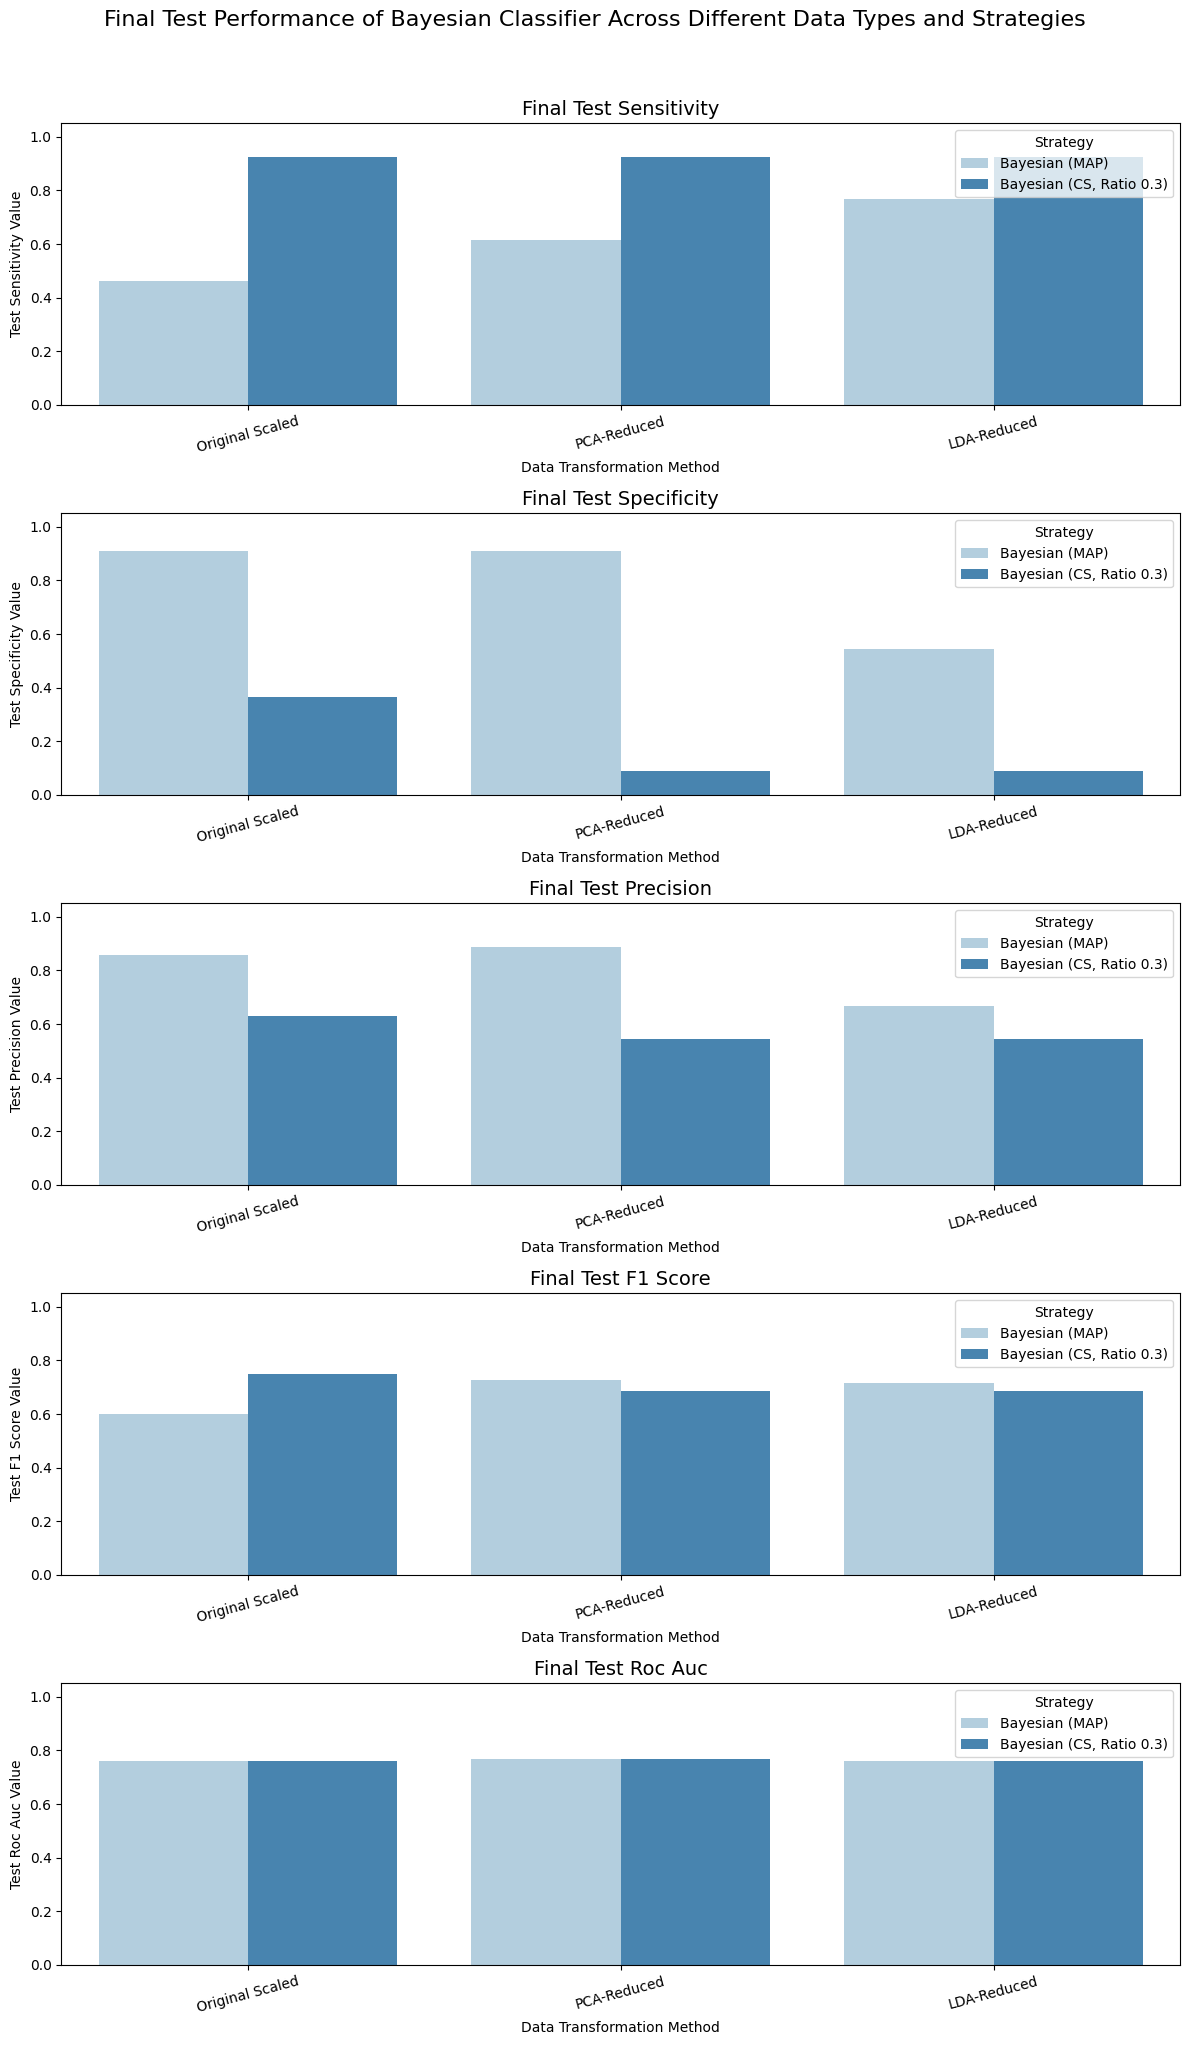

In [37]:
#9) PERFORMANCE EVALUATION (comparison between prediction test results)
data_for_plot_test_bc = []
metrics_to_plot_bc = ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']
CLASSIFIER_KEYS = [
    'Bayesian_MAP',
    'Bayesian_CS_0_3'
]

for data_type_name, classifiers in test_results.items():
    for key in CLASSIFIER_KEYS:
        if key in classifiers:
            final_metrics = classifiers[key]

            if key == 'Bayesian_MAP':
                strategy_label = 'Bayesian (MAP)'
            else:
                strategy_label = 'Bayesian (CS, Ratio 0.3)'

            for metric_name in metrics_to_plot_bc:
                value = final_metrics.get(metric_name)
                if value is None:
                    continue

                data_for_plot_test_bc.append({
                    'Classifier': strategy_label,
                    'Data Type': data_type_name,
                    'Metric': metric_name.replace('_', ' ').title(),
                    'Value': value,
                    'Std': 0.0
                })

plot_df_test_bc = pd.DataFrame(data_for_plot_test_bc)
fig, axes = plt.subplots(nrows=len(metrics_to_plot_bc), ncols=1, figsize=(12, 4 * len(metrics_to_plot_bc)))
fig.suptitle('Final Test Performance of Bayesian Classifier Across Different Data Types and Strategies', fontsize=16, y=1.02)

for i, metric_name_raw in enumerate(metrics_to_plot_bc):
    metric_name_formatted = metric_name_raw.replace('_', ' ').title()

    df_metric = plot_df_test_bc[plot_df_test_bc['Metric'] == metric_name_formatted]

    sns.barplot(
        data=df_metric,
        x='Data Type',
        y='Value',
        hue='Classifier',
        ax=axes[i],
        palette='Blues',
        errorbar=None
    )

    axes[i].set_title(f'Final Test {metric_name_formatted}', fontsize=14)
    axes[i].set_ylabel(f'Test {metric_name_formatted} Value')
    axes[i].set_xlabel('Data Transformation Method')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(title='Strategy', loc='best')

plt.tight_layout()
plt.show()

In [38]:
#10) CLASSIFIER: COST FUNCTION
def predict_cost_sensitive(y_proba, classes, cost_ratio):
    if len(classes) != 2:
        raise ValueError("Cost-sensitive prediction is currently implemented only for binary classification.")

    P_neg_given_x = y_proba[:, 0]
    P_pos_given_x = y_proba[:, 1]

    predictions = []
    for i in range(len(y_proba)):
        if P_neg_given_x[i] == 0:
            #if probability of negative class is zero, predict positive to avoid division by zero
            predictions.append(classes[1])
            continue

        ratio_P = P_pos_given_x[i] / P_neg_given_x[i]

        if ratio_P > cost_ratio:
            predictions.append(classes[1])
        else:
            predictions.append(classes[0])

    return np.array(predictions)

print("CS prediction function defined.")

CS prediction function defined.


In [39]:
#10) PERFORMANCE EVALUATION (kNN Selected Scaled Data)
k_values = list(range(1, 10, 1))
COST_RATIO_KNN = 0.5
knn_results_scaled = {
    'normal': {
        'sensitivity': [], 'specificity': [], 'precision': [],
        'f1_score': [], 'roc_auc': []
    },
    'cost_sensitive': {
        'sensitivity': [], 'specificity': [], 'precision': [],
        'f1_score': [], 'roc_auc': []
    }
}

print("Evaluating kNN on Selected Scaled Data")
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out_scaled = X_train_scaled.iloc[train_idx]
    X_val_out_scaled   = X_train_scaled.iloc[val_idx]
    Y_train_out        = Y_train.iloc[train_idx]
    Y_val_out          = Y_train.iloc[val_idx]

    best_k_for_outer_fold = 0
    best_roc_auc_for_outer_fold = 0
    inner_cv_metrics_by_k = {}

    for k in k_values:
        #for inner loop, we'll use normal prediction to find the best k
        k_fold_metrics = {
            'sensitivity': [], 'specificity': [], 'precision': [],
            'f1_score': [], 'roc_auc': []
        }

        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv_scaled.split(X_train_out_scaled, Y_train_out), start=1):
            X_train_inner_scaled = X_train_out_scaled.iloc[inner_train_idx]
            X_val_inner_scaled   = X_train_out_scaled.iloc[inner_val_idx]
            Y_train_inner_scaled = Y_train_out.iloc[inner_train_idx]
            Y_val_inner_scaled   = Y_train_out.iloc[inner_val_idx]

            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train_inner_scaled, Y_train_inner_scaled)

            y_pred_inner  = knn.predict(X_val_inner_scaled)
            y_proba_inner = knn.predict_proba(X_val_inner_scaled)

            inner_fold_metrics = calculate_metrics(Y_val_inner_scaled, y_pred_inner, y_proba_inner, [1, 2])

            for metric, value in inner_fold_metrics.items():
                k_fold_metrics[metric].append(value)

        #average metrics for current k across inner folds
        inner_cv_metrics_by_k[k] = {
            metric: np.mean(values) for metric, values in k_fold_metrics.items()
        }

        #update best_k if current k is better (based on ROC-AUC for normal prediction)
        if inner_cv_metrics_by_k[k]['roc_auc'] > best_roc_auc_for_outer_fold:
            best_roc_auc_for_outer_fold = inner_cv_metrics_by_k[k]['roc_auc']
            best_k_for_outer_fold = k
        #handmade GridSearch

    print(f"Best k for Outer Fold {outer_fold}: {best_k_for_outer_fold} (ROC-AUC: {best_roc_auc_for_outer_fold:.4f})")

    #evaluate on the outer validation set with the best k found in the inner loop
    knn_final_outer = KNeighborsClassifier(n_neighbors=best_k_for_outer_fold)
    knn_final_outer.fit(X_train_out_scaled, Y_train_out)

    #normal prediction
    y_pred_outer_normal  = knn_final_outer.predict(X_val_out_scaled)
    y_proba_outer = knn_final_outer.predict_proba(X_val_out_scaled)
    outer_fold_metrics_normal = calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, [1, 2])
    for metric, value in outer_fold_metrics_normal.items():
        knn_results_scaled['normal'][metric].append(value)

    #CS prediction
    y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, [1, 2], COST_RATIO_KNN)
    outer_fold_metrics_cs = calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, [1, 2])
    for metric, value in outer_fold_metrics_cs.items():
        knn_results_scaled['cost_sensitive'][metric].append(value)

print("\nSummary for kNN on Selected Scaled Data")
for metric, values in knn_results_scaled['normal'].items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")

print("\nSummary for CS-kNN on Selected Scaled Data")
for metric, values in knn_results_scaled['cost_sensitive'].items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")

Evaluating kNN on Selected Scaled Data

Outer Fold 1
Best k for Outer Fold 1: 6 (ROC-AUC: 0.8585)

Outer Fold 2
Best k for Outer Fold 2: 8 (ROC-AUC: 0.7190)

Outer Fold 3
Best k for Outer Fold 3: 7 (ROC-AUC: 0.8366)

Outer Fold 4
Best k for Outer Fold 4: 9 (ROC-AUC: 0.8487)

Summary for kNN on Selected Scaled Data
Sensitivity: Mean=0.6699, Std=0.1089
Specificity: Mean=0.7841, Std=0.1376
Precision: Mean=0.8036, Std=0.1197
F1_score: Mean=0.7229, Std=0.0791
Roc_auc: Mean=0.7904, Std=0.0737

Summary for CS-kNN on Selected Scaled Data
Sensitivity: Mean=0.8429, Std=0.0944
Specificity: Mean=0.5409, Std=0.1746
Precision: Mean=0.7050, Std=0.0875
F1_score: Mean=0.7607, Std=0.0492
Roc_auc: Mean=0.7904, Std=0.0737


In [40]:
#10) PERFORMANCE EVALUATION (kNN PCA-transformed Data)
k_values = list(range(1, 10, 1))
COST_RATIO_KNN = 0.5
knn_results_pca = {
    'normal': {
        'sensitivity': [], 'specificity': [], 'precision': [],
        'f1_score': [], 'roc_auc': []
    },
    'cost_sensitive': {
        'sensitivity': [], 'specificity': [], 'precision': [],
        'f1_score': [], 'roc_auc': []
    }
}

print("Evaluating kNN on PCA-Reduced Data")
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out_scaled = X_train_scaled.iloc[train_idx]
    X_val_out_scaled   = X_train_scaled.iloc[val_idx]
    Y_train_out        = Y_train.iloc[train_idx]
    Y_val_out          = Y_train.iloc[val_idx]

    pca_outer_fold = PCA(n_components=num_components_selected)
    X_train_out_pca = pca_outer_fold.fit_transform(X_train_out_scaled)
    X_val_out_pca   = pca_outer_fold.transform(X_val_out_scaled)

    pca_columns = [f'PC{i+1}' for i in range(num_components_selected)]
    X_train_out_pca = pd.DataFrame(X_train_out_pca, columns=pca_columns, index=X_train_out_scaled.index)
    X_val_out_pca   = pd.DataFrame(X_val_out_pca, columns=pca_columns, index=X_val_out_scaled.index)

    best_k_for_outer_fold = 0
    best_roc_auc_for_outer_fold = 0
    inner_cv_metrics_by_k = {}

    for k in k_values:
        k_fold_metrics = {
            'sensitivity': [], 'specificity': [], 'precision': [],
            'f1_score': [], 'roc_auc': []
        }

        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv_scaled.split(X_train_out_pca, Y_train_out), start=1):
            X_train_inner_pca = X_train_out_pca.iloc[inner_train_idx]
            X_val_inner_pca   = X_train_out_pca.iloc[inner_val_idx]
            Y_train_inner     = Y_train_out.iloc[inner_train_idx]
            Y_val_inner       = Y_train_out.iloc[inner_val_idx]

            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train_inner_pca, Y_train_inner)

            y_pred_inner  = knn.predict(X_val_inner_pca)
            y_proba_inner = knn.predict_proba(X_val_inner_pca)

            inner_fold_metrics = calculate_metrics(Y_val_inner, y_pred_inner, y_proba_inner, [1, 2])

            for metric, value in inner_fold_metrics.items():
                k_fold_metrics[metric].append(value)

        inner_cv_metrics_by_k[k] = {
            metric: np.mean(values) for metric, values in k_fold_metrics.items()
        }

        if inner_cv_metrics_by_k[k]['roc_auc'] > best_roc_auc_for_outer_fold:
            best_roc_auc_for_outer_fold = inner_cv_metrics_by_k[k]['roc_auc']
            best_k_for_outer_fold = k

    print(f"Best k for Outer Fold {outer_fold}: {best_k_for_outer_fold} (ROC-AUC: {best_roc_auc_for_outer_fold:.4f})")

    knn_final_outer = KNeighborsClassifier(n_neighbors=best_k_for_outer_fold)
    knn_final_outer.fit(X_train_out_pca, Y_train_out)

    y_pred_outer_normal  = knn_final_outer.predict(X_val_out_pca)
    y_proba_outer = knn_final_outer.predict_proba(X_val_out_pca)
    outer_fold_metrics_normal = calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, [1, 2])
    for metric, value in outer_fold_metrics_normal.items():
        knn_results_pca['normal'][metric].append(value)

    y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, [1, 2], COST_RATIO_KNN)
    outer_fold_metrics_cs = calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, [1, 2])
    for metric, value in outer_fold_metrics_cs.items():
        knn_results_pca['cost_sensitive'][metric].append(value)

print("\nSummary for kNN on PCA-Reduced Data")
for metric, values in knn_results_pca['normal'].items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")

print("\nSummary for CS-kNN on PCA-Reduced Data")
for metric, values in knn_results_pca['cost_sensitive'].items():
    print(f"{metric.capitalize()}: Mean={np.mean(values):.4f}, Std={np.std(values):.4f}")

Evaluating kNN on PCA-Reduced Data

Outer Fold 1
Best k for Outer Fold 1: 5 (ROC-AUC: 0.8111)

Outer Fold 2
Best k for Outer Fold 2: 9 (ROC-AUC: 0.6896)

Outer Fold 3
Best k for Outer Fold 3: 5 (ROC-AUC: 0.8238)

Outer Fold 4
Best k for Outer Fold 4: 8 (ROC-AUC: 0.7808)

Summary for kNN on PCA-Reduced Data
Sensitivity: Mean=0.7452, Std=0.0831
Specificity: Mean=0.6841, Std=0.1891
Precision: Mean=0.7616, Std=0.1380
F1_score: Mean=0.7470, Std=0.0827
Roc_auc: Mean=0.7511, Std=0.1101

Summary for CS-kNN on PCA-Reduced Data
Sensitivity: Mean=0.8622, Std=0.1144
Specificity: Mean=0.2977, Std=0.1610
Precision: Mean=0.6049, Std=0.0911
F1_score: Mean=0.7094, Std=0.0974
Roc_auc: Mean=0.7511, Std=0.1101


In [41]:
#10) PERFORMANCE EVALUATION (kNN LDA-transformed Data)
k_values = list(range(1, 10, 1))
COST_RATIO_KNN = 0.5
knn_results_lda = {
    'normal': {
        'sensitivity': [], 'specificity': [], 'precision': [],
        'f1_score': [], 'roc_auc': []
    },
    'cost_sensitive': {
        'sensitivity': [], 'specificity': [], 'precision': [],
        'f1_score': [], 'roc_auc': []
    }
}

print("Evaluating kNN on LDA-Reduced Data")
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out_scaled = X_train_scaled.iloc[train_idx]
    X_val_out_scaled   = X_train_scaled.iloc[val_idx]
    Y_train_out        = Y_train.iloc[train_idx]
    Y_val_out          = Y_train.iloc[val_idx]

    if len(np.unique(Y_train_out)) < 2:
        print(" Skipping LDA for this outer fold: only one class present in training data.")
        for metric in knn_results_lda['normal'].keys():
            knn_results_lda['normal'][metric].append(np.nan)
            knn_results_lda['cost_sensitive'][metric].append(np.nan)
        continue

    lda_outer_fold = LDA(n_components=1)
    X_train_out_lda = lda_outer_fold.fit_transform(X_train_out_scaled, Y_train_out)
    X_val_out_lda   = lda_outer_fold.transform(X_val_out_scaled)

    lda_columns = ['LD1']
    X_train_out_lda = pd.DataFrame(X_train_out_lda, columns=lda_columns, index=X_train_out_scaled.index)
    X_val_out_lda   = pd.DataFrame(X_val_out_lda, columns=lda_columns, index=X_val_out_scaled.index)

    best_k_for_outer_fold = 0
    best_roc_auc_for_outer_fold = 0
    inner_cv_metrics_by_k = {}

    for k in k_values:
        k_fold_metrics = {
            'sensitivity': [], 'specificity': [], 'precision': [],
            'f1_score': [], 'roc_auc': []
        }

        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv_scaled.split(X_train_out_lda, Y_train_out), start=1):
            X_train_inner_lda = X_train_out_lda.iloc[inner_train_idx]
            X_val_inner_lda   = X_train_out_lda.iloc[inner_val_idx]
            Y_train_inner     = Y_train_out.iloc[inner_train_idx]
            Y_val_inner       = Y_train_out.iloc[inner_val_idx]

            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_train_inner_lda, Y_train_inner)

            y_pred_inner  = knn.predict(X_val_inner_lda)
            y_proba_inner = knn.predict_proba(X_val_inner_lda)

            inner_fold_metrics = calculate_metrics(Y_val_inner, y_pred_inner, y_proba_inner, [1, 2])

            for metric, value in inner_fold_metrics.items():
                k_fold_metrics[metric].append(value)

        inner_cv_metrics_by_k[k] = {
            metric: np.mean(values) for metric, values in k_fold_metrics.items()
        }

        if inner_cv_metrics_by_k[k]['roc_auc'] > best_roc_auc_for_outer_fold:
            best_roc_auc_for_outer_fold = inner_cv_metrics_by_k[k]['roc_auc']
            best_k_for_outer_fold = k

    print(f"Best k for Outer Fold {outer_fold}: {best_k_for_outer_fold} (ROC-AUC: {best_roc_auc_for_outer_fold:.4f})")

    knn_final_outer = KNeighborsClassifier(n_neighbors=best_k_for_outer_fold)
    knn_final_outer.fit(X_train_out_lda, Y_train_out)

    y_pred_outer_normal  = knn_final_outer.predict(X_val_out_lda)
    y_proba_outer = knn_final_outer.predict_proba(X_val_out_lda)
    outer_fold_metrics_normal = calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, [1, 2])
    for metric, value in outer_fold_metrics_normal.items():
        knn_results_lda['normal'][metric].append(value)

    y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, [1, 2], COST_RATIO_KNN)
    outer_fold_metrics_cs = calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, [1, 2])
    for metric, value in outer_fold_metrics_cs.items():
        knn_results_lda['cost_sensitive'][metric].append(value)

print("\nSummary for kNN on LDA-Reduced Data")
for metric, values in knn_results_lda['normal'].items():
    print(f"{metric.capitalize()}: Mean={np.nanmean(values):.4f}, Std={np.nanstd(values):.4f}")

print("\nSummary for CS-kNN on LDA-Reduced Data")
for metric, values in knn_results_lda['cost_sensitive'].items():
    print(f"{metric.capitalize()}: Mean={np.nanmean(values):.4f}, Std={np.nanstd(values):.4f}")

Evaluating kNN on LDA-Reduced Data

Outer Fold 1
Best k for Outer Fold 1: 9 (ROC-AUC: 0.8292)

Outer Fold 2
Best k for Outer Fold 2: 6 (ROC-AUC: 0.8380)

Outer Fold 3
Best k for Outer Fold 3: 9 (ROC-AUC: 0.7869)

Outer Fold 4
Best k for Outer Fold 4: 6 (ROC-AUC: 0.8718)

Summary for kNN on LDA-Reduced Data
Sensitivity: Mean=0.7244, Std=0.1409
Specificity: Mean=0.6909, Std=0.2659
Precision: Mean=0.7871, Std=0.1811
F1_score: Mean=0.7315, Std=0.0940
Roc_auc: Mean=0.7845, Std=0.1632

Summary for CS-kNN on LDA-Reduced Data
Sensitivity: Mean=0.7644, Std=0.1091
Specificity: Mean=0.6659, Std=0.2492
Precision: Mean=0.7754, Std=0.1612
F1_score: Mean=0.7512, Std=0.0645
Roc_auc: Mean=0.7845, Std=0.1632



WHAT TO MONITOR?
- **Final Average**: the average of the metrics (ex: ROC AUC) across all Outer Folds is the most reliable estimate of your fully optimized model's performance.

- **k Stability**: if the optimal k remains in a narrow range (ex: 3 to 7), the model is robust. Wide variations suggest instability.

In [42]:
#10) PERFORMANCE EVALUATION (kNN on test data)
test_results = test_results if 'test_results' in globals() else {}
for key in ['Original Scaled', 'PCA-Reduced', 'LDA-Reduced']:
    if key not in test_results:
        test_results[key] = {}

param_grid = {'n_neighbors': k_values}
#1)kNN on Selected Scaled Test Data
print(f"\nFinal Test Evaluation: kNN on Selected Scaled Data")
#find the best 'k' using GridSearchCV on the full X_train_scaled and Y_train
grid_search_scaled = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
    #use all available CPU cores
)
grid_search_scaled.fit(X_train_scaled, Y_train)
#search executed
best_k_scaled = grid_search_scaled.best_params_['n_neighbors']
#best hyperparameter found
print(f"Best k for Selected Scaled Data: {best_k_scaled}")

#train a kNN with this best 'k' on X_train_scaled and Y_train
knn_final_scaled = KNeighborsClassifier(n_neighbors=best_k_scaled)
knn_final_scaled.fit(X_train_scaled, Y_train)

y_proba_scaled = knn_final_scaled.predict_proba(X_test_scaled)

#normal prediction
y_test_pred_scaled_normal = knn_final_scaled.predict(X_test_scaled)
final_metrics_scaled_normal = calculate_metrics(Y_test, y_test_pred_scaled_normal, y_proba_scaled, [1, 2])
test_results['Original Scaled']['kNN_Normal'] = final_metrics_scaled_normal
print(f"Normal Prediction:")
for k, v in final_metrics_scaled_normal.items():
    print(f"{k}: {v:.4f}")

#CS prediction
y_test_pred_scaled_cs = predict_cost_sensitive(y_proba_scaled, [1, 2], COST_RATIO_KNN)
final_metrics_scaled_cs = calculate_metrics(Y_test, y_test_pred_scaled_cs, y_proba_scaled, [1, 2])
test_results['Original Scaled']['kNN_Cost_Sensitive'] = final_metrics_scaled_cs
print(f"CS Prediction (Ratio={COST_RATIO_KNN}):")
for k, v in final_metrics_scaled_cs.items():
    print(f"{k}: {v:.4f}")

#2)kNN on PCA-Reduced Data
print(f"\nFinal Test Evaluation: kNN on PCA-Reduced Data")

pca_final = PCA(n_components=num_components_selected)
X_train_pca_np = pca_final.fit_transform(X_train_scaled)
X_test_pca_np  = pca_final.transform(X_test_scaled)

pca_cols = [f'PC{i+1}' for i in range(num_components_selected)]
X_train_pcaDF = pd.DataFrame(X_train_pca_np, columns=pca_cols, index=X_train_scaled.index)
X_test_pcaDF  = pd.DataFrame(X_test_pca_np,  columns=pca_cols, index=X_test_scaled.index)

grid_search_pca = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_pca.fit(X_train_pcaDF, Y_train)
best_k_pca = grid_search_pca.best_params_['n_neighbors']
print(f"Best k for PCA-Reduced Data: {best_k_pca}")

knn_final_pca = KNeighborsClassifier(n_neighbors=best_k_pca)
knn_final_pca.fit(X_train_pcaDF, Y_train)

y_proba_pca = knn_final_pca.predict_proba(X_test_pcaDF)

y_test_pred_pca_normal = knn_final_pca.predict(X_test_pcaDF)
final_metrics_pca_normal = calculate_metrics(Y_test, y_test_pred_pca_normal, y_proba_pca, [1, 2])
test_results['PCA-Reduced']['kNN_Normal'] = final_metrics_pca_normal
print(f"Normal Prediction:")
for k, v in final_metrics_pca_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_pca_cs = predict_cost_sensitive(y_proba_pca, [1, 2], COST_RATIO_KNN)
final_metrics_pca_cs = calculate_metrics(Y_test, y_test_pred_pca_cs, y_proba_pca, [1, 2])
test_results['PCA-Reduced']['kNN_Cost_Sensitive'] = final_metrics_pca_cs
print(f"CS Prediction (Ratio={COST_RATIO_KNN}):")
for k, v in final_metrics_pca_cs.items():
    print(f"{k}: {v:.4f}")

#3)kNN on LDA-Reduced Data
print(f"\nFinal Test Evaluation: kNN on LDA-Reduced Data")

lda_final = LDA(n_components=1)
X_train_lda_np = lda_final.fit_transform(X_train_scaled, Y_train)
X_test_lda_np  = lda_final.transform(X_test_scaled)

lda_cols = ['LDA1']
X_train_ldaDF = pd.DataFrame(X_train_lda_np, columns=lda_cols, index=X_train_scaled.index)
X_test_ldaDF  = pd.DataFrame(X_test_lda_np,  columns=lda_cols, index=X_test_scaled.index)

grid_search_lda = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_lda.fit(X_train_ldaDF, Y_train)
best_k_lda = grid_search_lda.best_params_['n_neighbors']
print(f"Best k for LDA-Reduced Data: {best_k_lda}")

knn_final_lda = KNeighborsClassifier(n_neighbors=best_k_lda)
knn_final_lda.fit(X_train_ldaDF, Y_train)

y_proba_lda = knn_final_lda.predict_proba(X_test_ldaDF)

y_test_pred_lda_normal = knn_final_lda.predict(X_test_ldaDF)
final_metrics_lda_normal = calculate_metrics(Y_test, y_test_pred_lda_normal, y_proba_lda, [1, 2])
test_results['LDA-Reduced']['kNN_Normal'] = final_metrics_lda_normal
print(f"Normal Prediction:")
for k, v in final_metrics_lda_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_lda_cs = predict_cost_sensitive(y_proba_lda, [1, 2], COST_RATIO_KNN)
final_metrics_lda_cs = calculate_metrics(Y_test, y_test_pred_lda_cs, y_proba_lda, [1, 2])
test_results['LDA-Reduced']['kNN_Cost_Sensitive'] = final_metrics_lda_cs
print(f"CS Prediction (Ratio={COST_RATIO_KNN}):")
for k, v in final_metrics_lda_cs.items():
    print(f"{k}: {v:.4f}")


Final Test Evaluation: kNN on Selected Scaled Data
Best k for Selected Scaled Data: 6
Normal Prediction:
sensitivity: 0.5385
specificity: 0.7273
precision: 0.7000
f1_score: 0.6087
roc_auc: 0.6958
CS Prediction (Ratio=0.5):
sensitivity: 0.7692
specificity: 0.3636
precision: 0.5882
f1_score: 0.6667
roc_auc: 0.6958

Final Test Evaluation: kNN on PCA-Reduced Data
Best k for PCA-Reduced Data: 9
Normal Prediction:
sensitivity: 0.6154
specificity: 0.7273
precision: 0.7273
f1_score: 0.6667
roc_auc: 0.8252
CS Prediction (Ratio=0.5):
sensitivity: 1.0000
specificity: 0.3636
precision: 0.6500
f1_score: 0.7879
roc_auc: 0.8252

Final Test Evaluation: kNN on LDA-Reduced Data
Best k for LDA-Reduced Data: 8
Normal Prediction:
sensitivity: 0.7692
specificity: 0.5455
precision: 0.6667
f1_score: 0.7143
roc_auc: 0.6853
CS Prediction (Ratio=0.5):
sensitivity: 0.8462
specificity: 0.4545
precision: 0.6471
f1_score: 0.7333
roc_auc: 0.6853


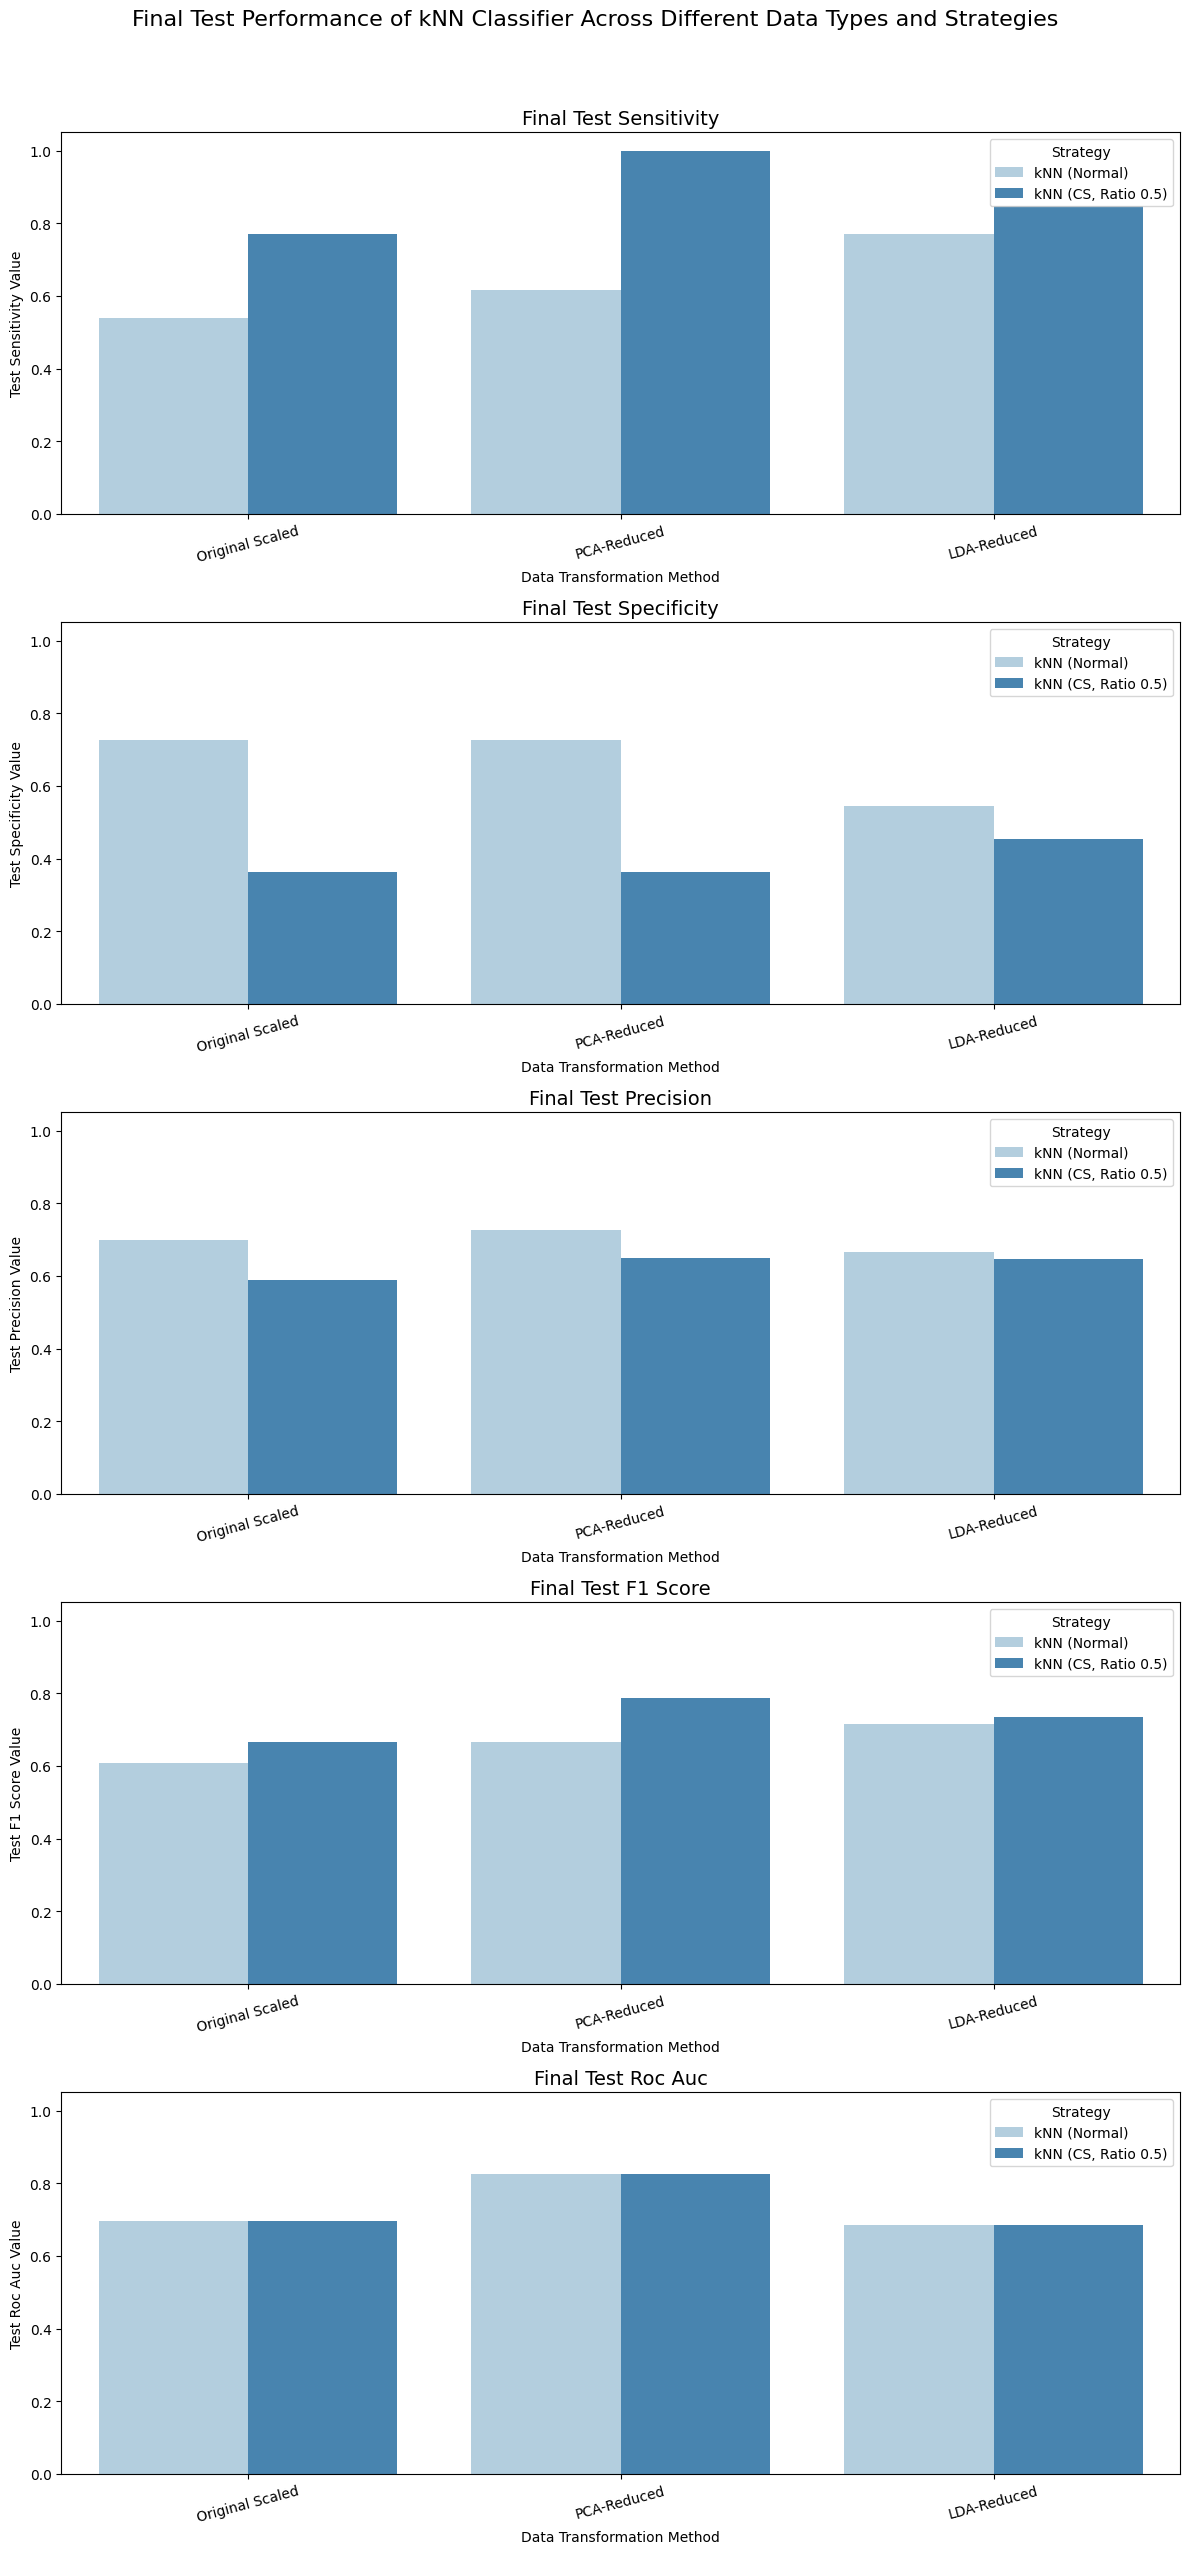

In [43]:
#10) PERFORMANCE EVALUATION (comparison between prediction test results)
data_for_plot_knn_test = []
metrics_to_plot_knn = ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']

for data_type_name, classifiers in test_results.items():
    for strategy_key in ['kNN_Normal', 'kNN_Cost_Sensitive']:
        if strategy_key in classifiers:
            final_metrics = classifiers[strategy_key]

            if strategy_key == 'kNN_Normal':
                strategy_label = 'kNN (Normal)'
            else:
                strategy_label = f'kNN (CS, Ratio {COST_RATIO_KNN})'

            for metric_name in metrics_to_plot_knn:
                value = final_metrics.get(metric_name)
                if value is None:
                    continue

                data_for_plot_knn_test.append({
                    'Classifier': strategy_label,
                    'Data Type': data_type_name,
                    'Metric': metric_name.replace('_', ' ').title(),
                    'Value': value,
                    'Std': 0.0
                })

plot_df_test_knn = pd.DataFrame(data_for_plot_knn_test)
fig, axes = plt.subplots(nrows=len(metrics_to_plot_knn), ncols=1, figsize=(12, 5 * len(metrics_to_plot_knn)))
fig.suptitle('Final Test Performance of kNN Classifier Across Different Data Types and Strategies', fontsize=16, y=1.02)

for i, metric_name_raw in enumerate(metrics_to_plot_knn):
    metric_name_formatted = metric_name_raw.replace('_', ' ').title()

    df_metric = plot_df_test_knn[plot_df_test_knn['Metric'] == metric_name_formatted]
    sns.barplot(
        data=df_metric,
        x='Data Type',
        y='Value',
        hue='Classifier',
        ax=axes[i],
        palette='Blues',
        errorbar=None
    )

    axes[i].set_title(f'Final Test {metric_name_formatted}', fontsize=14)
    axes[i].set_ylabel(f'Test {metric_name_formatted} Value')
    axes[i].set_xlabel('Data Transformation Method')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(title='Strategy', loc='best')

plt.tight_layout()
plt.show()

In [44]:
#11) CLASSIFIER + EVALUATION: LINEAR SVM (selected scaled data)
from sklearn.svm import SVC
c_values = [0.1, 0.5, 1, 5, 10, 20, 50]
COST_RATIO_SVM_CS = 0.5

svm_results_original = {
    'normal': [],
    'cost_sensitive': []
}

#1) Linear SVM on Selected Scaled Data
print("Evaluating Linear SVM  on Selected Scaled Data")
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)
for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train = X_train_scaled.iloc[train_idx].values
    X_val   = X_train_scaled.iloc[val_idx].values
    Y_train_out = Y_train.iloc[train_idx]
    Y_val_out   = Y_train.iloc[val_idx]

    best_c_for_outer_fold = 0
    best_roc_auc_for_outer_fold = 0

    #best C
    for c in c_values:
        k_fold_metrics = {'roc_auc': []}
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv_scaled.split(X_train, Y_train_out), start=1):
            X_train_inner = X_train[inner_train_idx]
            X_val_inner   = X_train[inner_val_idx]
            Y_train_inner = Y_train_out.iloc[inner_train_idx]
            Y_val_inner   = Y_train_out.iloc[inner_val_idx]

            svm_inner = SVC(kernel='linear', C=c, probability=True, random_state=1)
            svm_inner.fit(X_train_inner, Y_train_inner)

            y_proba_inner = svm_inner.predict_proba(X_val_inner)
            roc_auc = calculate_metrics(Y_val_inner, svm_inner.predict(X_val_inner), y_proba_inner, [1,2])['roc_auc']
            k_fold_metrics['roc_auc'].append(roc_auc)

        mean_roc_auc = np.mean(k_fold_metrics['roc_auc'])
        if mean_roc_auc > best_roc_auc_for_outer_fold:
            best_roc_auc_for_outer_fold = mean_roc_auc
            best_c_for_outer_fold = c

    print(f"Best C found: {best_c_for_outer_fold}")
    #again the handmade GridSearch

    #validation
    svm_final_outer = SVC(kernel='linear', C=best_c_for_outer_fold, probability=True, random_state=1)
    svm_final_outer.fit(X_train, Y_train_out)
    y_proba_outer = svm_final_outer.predict_proba(X_val)

    #normal prediction
    y_pred_outer_normal  = svm_final_outer.predict(X_val)
    svm_results_original['normal'].append(calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, [1,2]))

    #CS prediction
    y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, [1,2], COST_RATIO_SVM_CS)
    svm_results_original['cost_sensitive'].append(calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, [1,2]))

print("\nSummary for Linear SVM on Selected Scaled Data")
df_normal = pd.DataFrame(svm_results_original['normal'])
df_cs = pd.DataFrame(svm_results_original['cost_sensitive'])

print("\nNormal Prediction:")
for k in df_normal.columns:
    print(f"{k}: Mean={df_normal[k].mean():.4f}, Std={df_normal[k].std():.4f}")
print(f"\nCS Prediction (Ratio={COST_RATIO_SVM_CS}):")
for k in df_cs.columns:
    print(f"{k}: Mean={df_cs[k].mean():.4f}, Std={df_cs[k].std():.4f}")

Evaluating Linear SVM  on Selected Scaled Data

Outer Fold 1
Best C found: 0.5

Outer Fold 2
Best C found: 0.1

Outer Fold 3
Best C found: 10

Outer Fold 4
Best C found: 5

Summary for Linear SVM on Selected Scaled Data

Normal Prediction:
sensitivity: Mean=0.7067, Std=0.0691
specificity: Mean=0.7636, Std=0.2409
precision: Mean=0.8173, Std=0.1730
f1_score: Mean=0.7451, Std=0.0530
roc_auc: Mean=0.8492, Std=0.1167

CS Prediction (Ratio=0.5):
sensitivity: Mean=0.9583, Std=0.0833
specificity: Mean=0.3227, Std=0.2095
precision: Mean=0.6412, Std=0.1085
f1_score: Mean=0.7669, Std=0.1016
roc_auc: Mean=0.8492, Std=0.1167


In [45]:
#11) CLASSIFIER + EVALUATION: LINEAR SVM (PCA-transformed data)
c_values = [0.1, 0.5, 1, 5, 10, 20, 50]
COST_RATIO_SVM_CS = 0.5

svm_results_pca = {
    'normal': [],
    'cost_sensitive': []
}

print("Evaluating Linear SVM on PCA-transformed Data")
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out_scaled = X_train_scaled.iloc[train_idx]
    X_val_out_scaled   = X_train_scaled.iloc[val_idx]
    Y_train_out        = Y_train.iloc[train_idx]
    Y_val_out          = Y_train.iloc[val_idx]

    pca_final = PCA(n_components=num_components_selected, random_state=1)
    X_train = pca_final.fit_transform(X_train_out_scaled)
    X_val   = pca_final.transform(X_val_out_scaled)

    best_c_for_outer_fold = 0
    best_roc_auc_for_outer_fold = 0

    for c in c_values:
        k_fold_metrics = {'roc_auc': []}
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv_scaled.split(X_train, Y_train_out), start=1):
            X_train_inner = X_train[inner_train_idx]
            X_val_inner   = X_train[inner_val_idx]
            Y_train_inner = Y_train_out.iloc[inner_train_idx]
            Y_val_inner   = Y_train_out.iloc[inner_val_idx]

            svm_inner = SVC(kernel='linear', C=c, probability=True, random_state=1)
            svm_inner.fit(X_train_inner, Y_train_inner)

            y_proba_inner = svm_inner.predict_proba(X_val_inner)
            roc_auc = calculate_metrics(Y_val_inner, svm_inner.predict(X_val_inner), y_proba_inner, [1,2])['roc_auc']
            k_fold_metrics['roc_auc'].append(roc_auc)

        mean_roc_auc = np.mean(k_fold_metrics['roc_auc'])
        if mean_roc_auc > best_roc_auc_for_outer_fold:
            best_roc_auc_for_outer_fold = mean_roc_auc
            best_c_for_outer_fold = c

    print(f"Best C found: {best_c_for_outer_fold}")

    svm_final_outer = SVC(kernel='linear', C=best_c_for_outer_fold, probability=True, random_state=1)
    svm_final_outer.fit(X_train, Y_train_out)
    y_proba_outer = svm_final_outer.predict_proba(X_val)

    y_pred_outer_normal  = svm_final_outer.predict(X_val)
    svm_results_pca['normal'].append(calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, [1,2]))

    y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, [1,2], COST_RATIO_SVM_CS)
    svm_results_pca['cost_sensitive'].append(calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, [1,2]))

print("\nSummary for Linear SVM on PCA-transformed Data")
df_normal = pd.DataFrame(svm_results_pca['normal'])
df_cs = pd.DataFrame(svm_results_pca['cost_sensitive'])

print("\nNormal Prediction:")
for k in df_normal.columns:
    print(f"{k}: Mean={df_normal[k].mean():.4f}, Std={df_normal[k].std():.4f}")
print(f"\nCS Prediction (Ratio={COST_RATIO_SVM_CS}):")
for k in df_cs.columns:
    print(f"{k}: Mean={df_cs[k].mean():.4f}, Std={df_cs[k].std():.4f}")

Evaluating Linear SVM on PCA-transformed Data

Outer Fold 1
Best C found: 0.5

Outer Fold 2
Best C found: 0.1

Outer Fold 3
Best C found: 0.5

Outer Fold 4
Best C found: 20

Summary for Linear SVM on PCA-transformed Data

Normal Prediction:
sensitivity: Mean=0.7260, Std=0.0973
specificity: Mean=0.7386, Std=0.2268
precision: Mean=0.8010, Std=0.1638
f1_score: Mean=0.7483, Std=0.0613
roc_auc: Mean=0.8339, Std=0.1103

CS Prediction (Ratio=0.5):
sensitivity: Mean=0.9583, Std=0.0833
specificity: Mean=0.2727, Std=0.1739
precision: Mean=0.6228, Std=0.0926
f1_score: Mean=0.7541, Std=0.0914
roc_auc: Mean=0.8339, Std=0.1103


In [46]:
#11) CLASSIFIER + EVALUATION: LINEAR SVM (LDA-transformed data)
c_values = [0.1, 0.5, 1, 5, 10, 20, 50]
COST_RATIO_SVM_CS = 0.5

svm_results_lda = {
    'normal': [],
    'cost_sensitive': []
}

print("Evaluating Linear SVM on LDA-transformed Data")
outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out_scaled = X_train_scaled.iloc[train_idx]
    X_val_out_scaled   = X_train_scaled.iloc[val_idx]
    Y_train_out        = Y_train.iloc[train_idx]
    Y_val_out          = Y_train.iloc[val_idx]

    lda_final = LDA(n_components=1)
    X_train = lda_final.fit_transform(X_train_out_scaled, Y_train_out)
    X_val   = lda_final.transform(X_val_out_scaled)

    best_c_for_outer_fold = 0
    best_roc_auc_for_outer_fold = 0

    for c in c_values:
        k_fold_metrics = {'roc_auc': []}
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv_scaled.split(X_train, Y_train_out), start=1):
            X_train_inner = X_train[inner_train_idx]
            X_val_inner   = X_train[inner_val_idx]
            Y_train_inner = Y_train_out.iloc[inner_train_idx]
            Y_val_inner   = Y_train_out.iloc[inner_val_idx]

            svm_inner = SVC(kernel='linear', C=c, probability=True, random_state=1)
            svm_inner.fit(X_train_inner, Y_train_inner)

            y_proba_inner = svm_inner.predict_proba(X_val_inner)
            roc_auc = calculate_metrics(Y_val_inner, svm_inner.predict(X_val_inner), y_proba_inner, [1,2])['roc_auc']
            k_fold_metrics['roc_auc'].append(roc_auc)

        mean_roc_auc = np.mean(k_fold_metrics['roc_auc'])
        if mean_roc_auc > best_roc_auc_for_outer_fold:
            best_roc_auc_for_outer_fold = mean_roc_auc
            best_c_for_outer_fold = c

    print(f"Best C found: {best_c_for_outer_fold}")

    svm_final_outer = SVC(kernel='linear', C=best_c_for_outer_fold, probability=True, random_state=1)
    svm_final_outer.fit(X_train, Y_train_out)
    y_proba_outer = svm_final_outer.predict_proba(X_val)

    y_pred_outer_normal  = svm_final_outer.predict(X_val)
    svm_results_lda['normal'].append(calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, [1,2]))

    y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, [1,2], COST_RATIO_SVM_CS)
    svm_results_lda['cost_sensitive'].append(calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, [1,2]))

print("\nSummary for Linear SVM on LDA-transformed Data")
df_normal = pd.DataFrame(svm_results_lda['normal'])
df_cs = pd.DataFrame(svm_results_lda['cost_sensitive'])

print("\nNormal Prediction:")
for k in df_normal.columns:
    print(f"{k}: Mean={df_normal[k].mean():.4f}, Std={df_normal[k].std():.4f}")
print(f"\nCS Prediction(Ratio={COST_RATIO_SVM_CS}):")
for k in df_cs.columns:
    print(f"{k}: Mean={df_cs[k].mean():.4f}, Std={df_cs[k].std():.4f}")

Evaluating Linear SVM on LDA-transformed Data

Outer Fold 1
Best C found: 0.1

Outer Fold 2
Best C found: 0.1

Outer Fold 3
Best C found: 0.1

Outer Fold 4
Best C found: 0.1

Summary for Linear SVM on LDA-transformed Data

Normal Prediction:
sensitivity: Mean=0.7837, Std=0.1932
specificity: Mean=0.7409, Std=0.2807
precision: Mean=0.8192, Std=0.1929
f1_score: Mean=0.7802, Std=0.1413
roc_auc: Mean=0.8608, Std=0.1369

CS Prediction(Ratio=0.5):
sensitivity: Mean=0.9391, Std=0.0793
specificity: Mean=0.5205, Std=0.2447
precision: Mean=0.7143, Std=0.1350
f1_score: Mean=0.8096, Std=0.1187
roc_auc: Mean=0.8608, Std=0.1369


In [47]:
#11) PERFORMANCE EVALUATION: LINEAR SVM (test data)
#dictionary to store the best C values found for each data type
best_c_values_linear = {}
#parameter grid for GridSearchCV
param_grid_linear = {'C': [0.1, 0.5, 1, 5, 10, 20, 50] }
#Cost Ratio for SVM CS prediction
COST_RATIO_SVM_CS = 0.5

#1) linear SVM on Selected Scaled Test Data
print("\nFinal Test Evaluation: Linear SVM on Original Scaled Data")
#best 'C' using GridSearchCV on the full X_train_scaled and Y_train
grid_search_scaled = GridSearchCV(
    SVC(kernel='linear', probability=True, random_state=1),
    param_grid_linear,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_scaled.fit(X_train_scaled, Y_train)
best_c_scaled = grid_search_scaled.best_params_['C']
best_c_values_linear['Original Scaled'] = best_c_scaled
print(f"Best C for Original Scaled Data: {best_c_scaled}")

#train a linear SVM with this best 'C' on full X_train_scaled and Y_train
svm_final_scaled = SVC(kernel='linear', C=best_c_scaled, probability=True, random_state=1)
svm_final_scaled.fit(X_train_scaled, Y_train)

#get probabilities for test set
y_proba_scaled = svm_final_scaled.predict_proba(X_test_scaled)
classes = svm_final_scaled.classes_

#normal prediction
y_test_pred_scaled_normal = svm_final_scaled.predict(X_test_scaled)
final_metrics_scaled_normal = calculate_metrics(Y_test, y_test_pred_scaled_normal, y_proba_scaled, [1, 2])
test_results['Original Scaled']['Linear SVM_Normal'] = final_metrics_scaled_normal
print(f"Normal Prediction:")
for k, v in final_metrics_scaled_normal.items():
    print(f"{k}: {v:.4f}")

#CS prediction
y_test_pred_scaled_cs = predict_cost_sensitive(y_proba_scaled, classes, COST_RATIO_SVM_CS)
final_metrics_scaled_cs = calculate_metrics(Y_test, y_test_pred_scaled_cs, y_proba_scaled, [1, 2])
test_results['Original Scaled']['Linear SVM_Cost_Sensitive'] = final_metrics_scaled_cs
print(f"CS Prediction (Ratio={COST_RATIO_SVM_CS}):")
for k, v in final_metrics_scaled_cs.items():
    print(f"{k}: {v:.4f}")

#2) linear SVM on PCA-Reduced Test Data
print("\nFinal Test Evaluation: Linear SVM on PCA-Reduced Data")

pca_final = PCA(n_components=num_components_selected, random_state=1)
X_train_pca_np = pca_final.fit_transform(X_train_scaled)
X_test_pca_np  = pca_final.transform(X_test_scaled)

pca_cols = [f'PC{i+1}' for i in range(num_components_selected)]
X_train_pcaDF = pd.DataFrame(X_train_pca_np, columns=pca_cols, index=X_train_scaled.index)
X_test_pcaDF  = pd.DataFrame(X_test_pca_np,  columns=pca_cols, index=X_test_scaled.index)

grid_search_pca = GridSearchCV(
    SVC(kernel='linear', probability=True, random_state=1),
    param_grid_linear,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_pca.fit(X_train_pcaDF, Y_train)
best_c_pca = grid_search_pca.best_params_['C']
best_c_values_linear['PCA-Reduced'] = best_c_pca
print(f"Best C for PCA-Reduced Data: {best_c_pca}")

svm_final_pca = SVC(kernel='linear', C=best_c_pca, probability=True, random_state=1)
svm_final_pca.fit(X_train_pcaDF, Y_train)

y_proba_pca = svm_final_pca.predict_proba(X_test_pcaDF)
classes = svm_final_pca.classes_

y_test_pred_pca_normal = svm_final_pca.predict(X_test_pcaDF)
final_metrics_pca_normal = calculate_metrics(Y_test, y_test_pred_pca_normal, y_proba_pca, classes)
test_results['PCA-Reduced']['Linear SVM_Normal'] = final_metrics_pca_normal
print(f"Normal Prediction:")
for k, v in final_metrics_pca_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_pca_cs = predict_cost_sensitive(y_proba_pca, classes, COST_RATIO_SVM_CS)
final_metrics_pca_cs = calculate_metrics(Y_test, y_test_pred_pca_cs, y_proba_pca, classes)
test_results['PCA-Reduced']['Linear SVM_Cost_Sensitive'] = final_metrics_pca_cs
print(f"CS Prediction (Ratio={COST_RATIO_SVM_CS}):")
for k, v in final_metrics_pca_cs.items():
    print(f"{k}: {v:.4f}")

#3) Linear SVM on LDA-Reduced Test Data
print("\nFinal Test Evaluation: Linear SVM on LDA-Reduced Data")

lda_final = LDA(n_components=1)
X_train_lda_np = lda_final.fit_transform(X_train_scaled, Y_train)
X_test_lda_np  = lda_final.transform(X_test_scaled)

lda_cols = ['LDA1']
X_train_ldaDF = pd.DataFrame(X_train_lda_np, columns=lda_cols, index=X_train_scaled.index)
X_test_ldaDF  = pd.DataFrame(X_test_lda_np,  columns=lda_cols, index=X_test_scaled.index)

grid_search_lda = GridSearchCV(
    SVC(kernel='linear', probability=True, random_state=1),
    param_grid_linear,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_lda.fit(X_train_ldaDF, Y_train)
best_c_lda = grid_search_lda.best_params_['C']
best_c_values_linear['LDA-Reduced'] = best_c_lda
print(f"Best C for LDA-Reduced Data: {best_c_lda}")

svm_final_lda = SVC(kernel='linear', C=best_c_lda, probability=True, random_state=1)
svm_final_lda.fit(X_train_ldaDF, Y_train)

y_proba_lda = svm_final_lda.predict_proba(X_test_ldaDF)
classes = svm_final_lda.classes_

y_test_pred_lda_normal = svm_final_lda.predict(X_test_ldaDF)
final_metrics_lda_normal = calculate_metrics(Y_test, y_test_pred_lda_normal, y_proba_lda, classes)
test_results['LDA-Reduced']['Linear SVM_Normal'] = final_metrics_lda_normal
print(f"Normal Prediction:")
for k, v in final_metrics_lda_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_lda_cs = predict_cost_sensitive(y_proba_lda, classes, COST_RATIO_SVM_CS)
final_metrics_lda_cs = calculate_metrics(Y_test, y_test_pred_lda_cs, y_proba_lda, classes)
test_results['LDA-Reduced']['Linear SVM_Cost_Sensitive'] = final_metrics_lda_cs
print(f"CS Prediction (Ratio={COST_RATIO_SVM_CS}):")
for k, v in final_metrics_lda_cs.items():
    print(f"{k}: {v:.4f}")


Final Test Evaluation: Linear SVM on Original Scaled Data
Best C for Original Scaled Data: 1
Normal Prediction:
sensitivity: 0.7692
specificity: 0.6364
precision: 0.7143
f1_score: 0.7407
roc_auc: 0.7832
CS Prediction (Ratio=0.5):
sensitivity: 0.9231
specificity: 0.3636
precision: 0.6316
f1_score: 0.7500
roc_auc: 0.7832

Final Test Evaluation: Linear SVM on PCA-Reduced Data
Best C for PCA-Reduced Data: 5
Normal Prediction:
sensitivity: 0.7692
specificity: 0.6364
precision: 0.7143
f1_score: 0.7407
roc_auc: 0.8112
CS Prediction (Ratio=0.5):
sensitivity: 0.9231
specificity: 0.4545
precision: 0.6667
f1_score: 0.7742
roc_auc: 0.8112

Final Test Evaluation: Linear SVM on LDA-Reduced Data
Best C for LDA-Reduced Data: 0.1
Normal Prediction:
sensitivity: 0.7692
specificity: 0.5455
precision: 0.6667
f1_score: 0.7143
roc_auc: 0.7622
CS Prediction (Ratio=0.5):
sensitivity: 0.8462
specificity: 0.4545
precision: 0.6471
f1_score: 0.7333
roc_auc: 0.7622


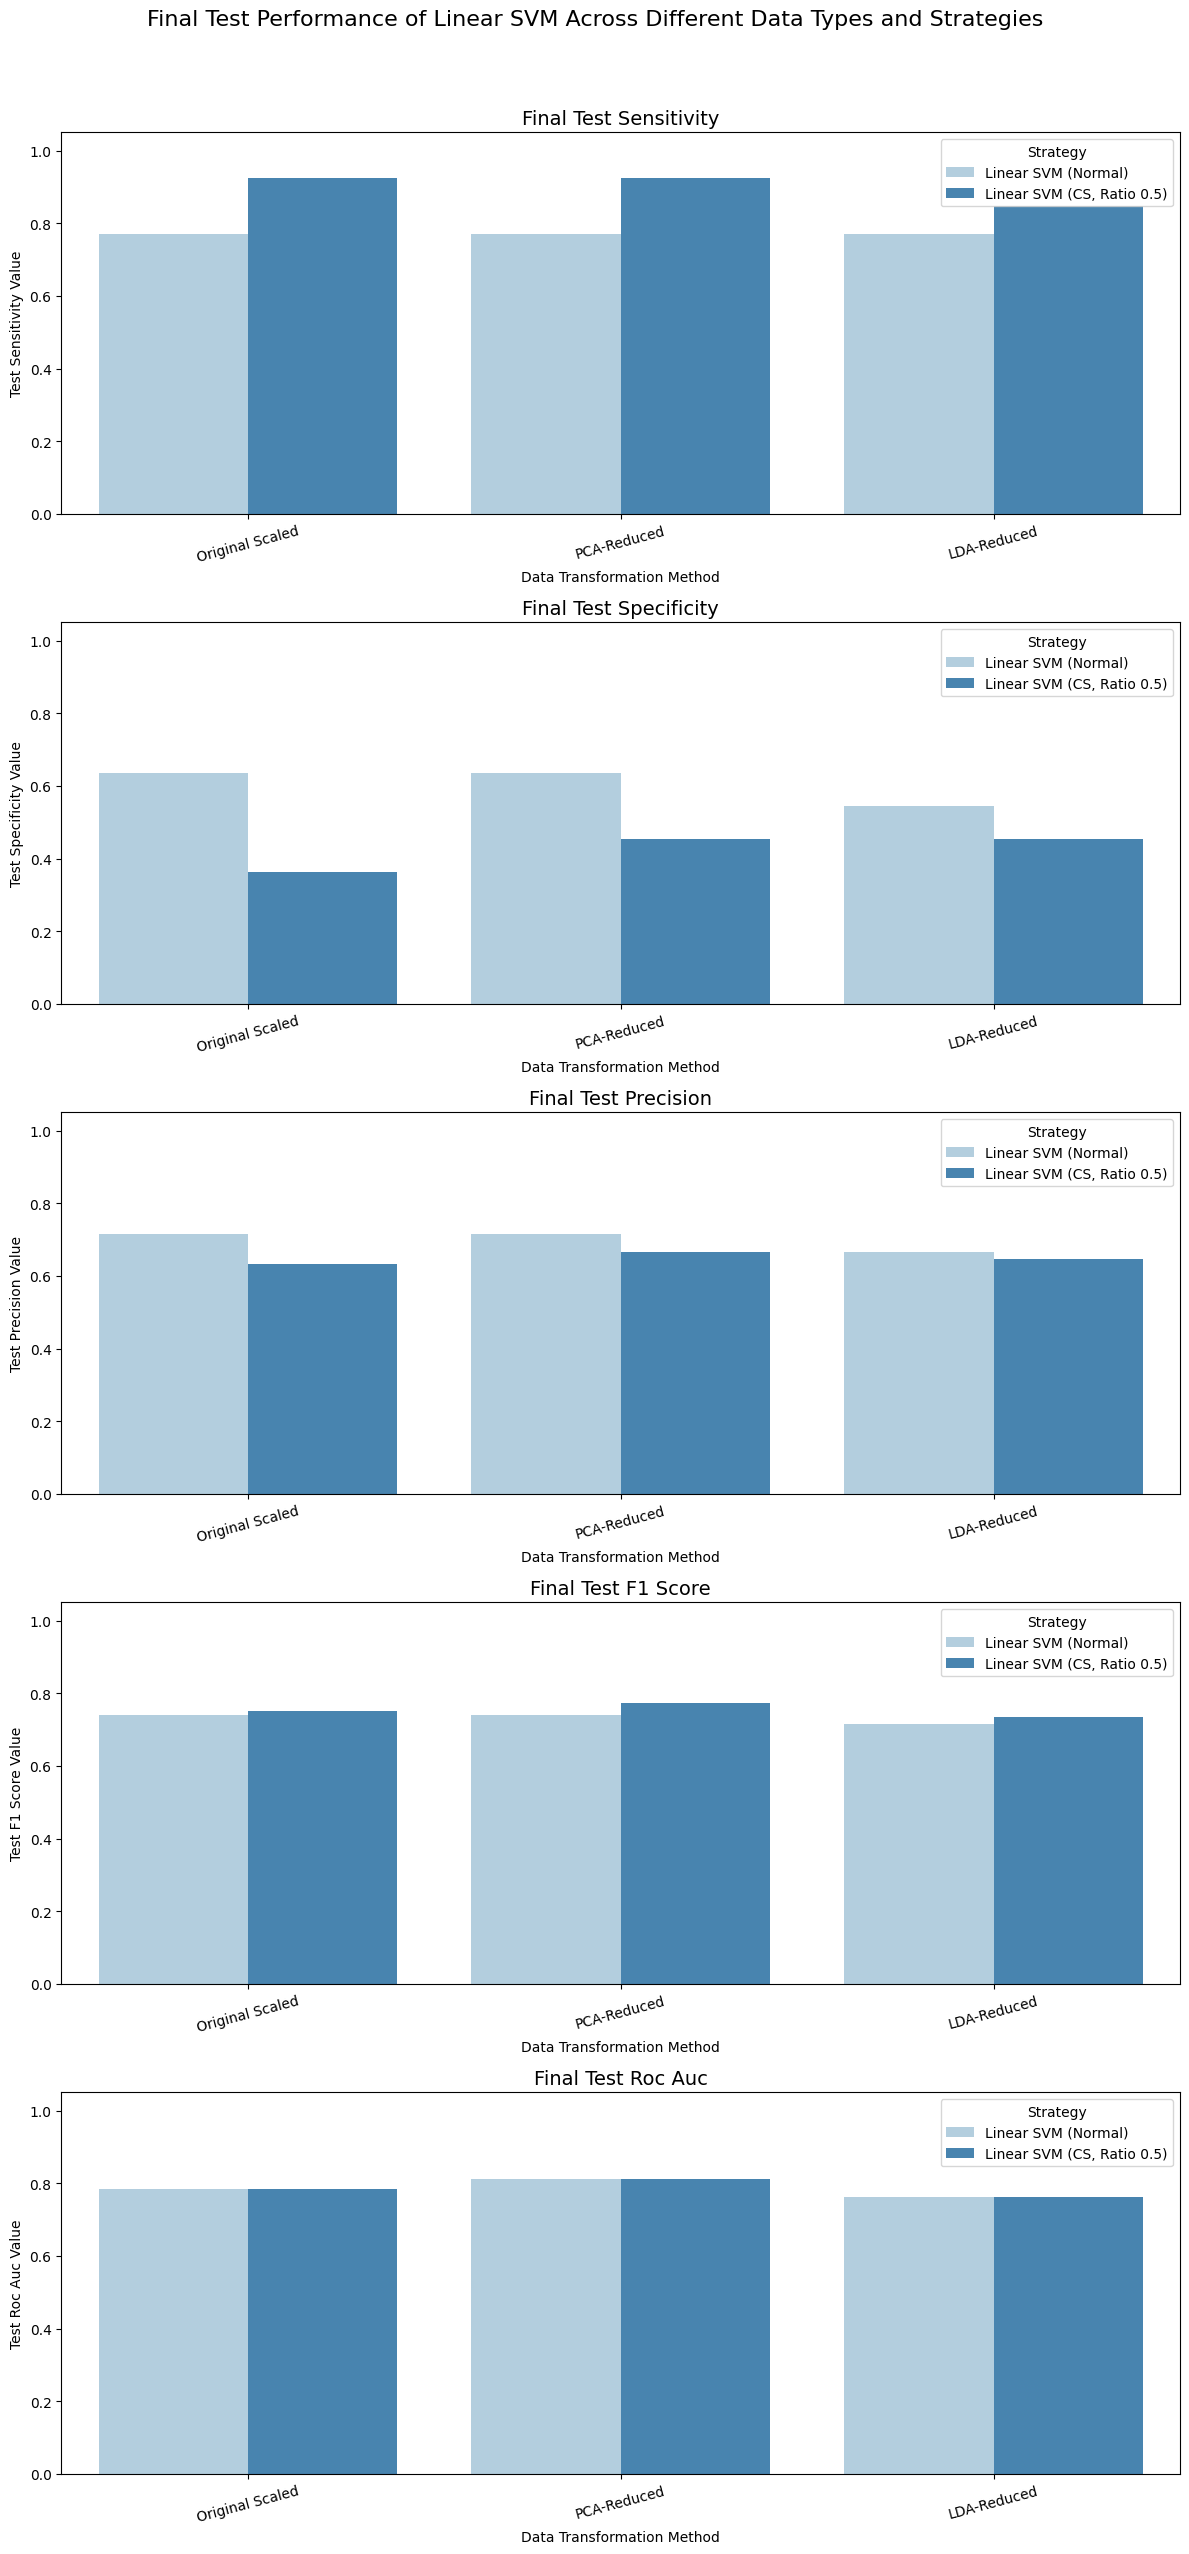

In [48]:
#11) PERFORMANCE EVALUATION (linear SVM results comparison)
data_for_plot_linear_svm_test = []
metrics_to_plot_linear_svm = ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']

for data_type_name, classifiers in test_results.items():
    for strategy_key in ['Linear SVM_Normal', 'Linear SVM_Cost_Sensitive']:
        if strategy_key in classifiers:
            final_metrics = classifiers[strategy_key]

            if strategy_key == 'Linear SVM_Normal':
                strategy_label = 'Linear SVM (Normal)'
            else:
                strategy_label = f'Linear SVM (CS, Ratio {COST_RATIO_SVM_CS})'

            for metric_name in metrics_to_plot_linear_svm:
                value = final_metrics.get(metric_name)
                if value is None:
                    continue

                data_for_plot_linear_svm_test.append({
                    'Classifier': strategy_label,
                    'Data Type': data_type_name,
                    'Metric': metric_name.replace('_', ' ').title(),
                    'Value': value,
                    'Std': 0.0
                })

plot_df_test_linear_svm = pd.DataFrame(data_for_plot_linear_svm_test)
fig, axes = plt.subplots(nrows=len(metrics_to_plot_linear_svm), ncols=1, figsize=(12, 5 * len(metrics_to_plot_linear_svm)))
fig.suptitle('Final Test Performance of Linear SVM Across Different Data Types and Strategies', fontsize=16, y=1.02)

for i, metric_name_raw in enumerate(metrics_to_plot_linear_svm):
    metric_name_formatted = metric_name_raw.replace('_', ' ').title()

    df_metric = plot_df_test_linear_svm[plot_df_test_linear_svm['Metric'] == metric_name_formatted]
    sns.barplot(
        data=df_metric,
        x='Data Type',
        y='Value',
        hue='Classifier',
        ax=axes[i],
        palette='Blues',
        errorbar=None
    )

    axes[i].set_title(f'Final Test {metric_name_formatted}', fontsize=14)
    axes[i].set_ylabel(f'Test {metric_name_formatted} Value')
    axes[i].set_xlabel('Data Transformation Method')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(title='Strategy', loc='best')

plt.tight_layout()
plt.show()

In [49]:
#12) PERFORMANCE EVALUATION: NON-LINEAR SVM (all training data)
#hyperparameters for NON-LINEAR SVM (RBF Kernel)
param_grid_nonlinear = {
    'C': [0.1, 0.5, 1, 5, 10, 20, 50],
    'gamma': [0.001, 0.01, 0.1, 1]
}
COST_RATIO_SVM_CS = 0.5

nonlinear_svm_results_nested = {
    'Original Scaled': {'normal': [], 'cost_sensitive': []},
    'PCA-Reduced': {'normal': [], 'cost_sensitive': []},
    'LDA-Reduced': {'normal': [], 'cost_sensitive': []}
}
best_params_nonlinear_nested = {} #to store the best C and gamma for each fold

outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

print("Evaluating Non-Linear SVM (RBF) with Nested K-Fold CV on All Data Types")

# 1) Non-Linear SVM on Selected Scaled Data
data_key = 'Original Scaled'
print(f"\nEvaluating Non-Linear SVM on {data_key}")

for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out = X_train_scaled.iloc[train_idx]
    X_val_out = X_train_scaled.iloc[val_idx]
    Y_train_out = Y_train.iloc[train_idx]
    Y_val_out = Y_train.iloc[val_idx]

    #inner Loop: tuning C & gamma with GridSearchCV
    grid_search = GridSearchCV(
        SVC(kernel='rbf', probability=True, random_state=1),
        param_grid_nonlinear,
        cv=inner_cv_scaled,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid_search.fit(X_train_out, Y_train_out)

    best_params = grid_search.best_params_
    best_params_nonlinear_nested[f'{data_key}_Fold{outer_fold}'] = best_params
    print(f"Best params found: {best_params}")

    #outer loop validation: Train final model and evaluate
    best_svm = SVC(kernel='rbf', probability=True, random_state=1, **best_params)
    #** for dictionary unpacking
    best_svm.fit(X_train_out, Y_train_out)
    y_proba_outer = best_svm.predict_proba(X_val_out)

    #normal prediction
    y_pred_outer_normal = best_svm.predict(X_val_out)
    nonlinear_svm_results_nested[data_key]['normal'].append(calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, [1, 2]))

    #CS prediction
    y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, [1, 2], COST_RATIO_SVM_CS)
    nonlinear_svm_results_nested[data_key]['cost_sensitive'].append(calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, [1, 2]))


# 2) Non-Linear SVM on PCA-Reduced Data
data_key = 'PCA-Reduced'
print(f"\nEvaluating Non-Linear SVM on {data_key}")

for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out_scaled, X_val_out_scaled = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    Y_train_out, Y_val_out = Y_train.iloc[train_idx], Y_train.iloc[val_idx]

    pca_outer_fold = PCA(n_components=num_components_selected, random_state=1)
    X_train_out_pca = pca_outer_fold.fit_transform(X_train_out_scaled)
    X_val_out_pca = pca_outer_fold.transform(X_val_out_scaled)

    grid_search = GridSearchCV(
        SVC(kernel='rbf', probability=True, random_state=1),
        param_grid_nonlinear,
        cv=inner_cv_scaled,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid_search.fit(X_train_out_pca, Y_train_out)

    best_params = grid_search.best_params_
    best_params_nonlinear_nested[f'{data_key}_Fold{outer_fold}'] = best_params
    print(f"Best params found: {best_params}")

    best_svm = SVC(kernel='rbf', probability=True, random_state=1, **best_params)
    best_svm.fit(X_train_out_pca, Y_train_out)
    y_proba_outer = best_svm.predict_proba(X_val_out_pca)

    y_pred_outer_normal = best_svm.predict(X_val_out_pca)
    nonlinear_svm_results_nested[data_key]['normal'].append(calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, [1, 2]))

    y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, [1, 2], COST_RATIO_SVM_CS)
    nonlinear_svm_results_nested[data_key]['cost_sensitive'].append(calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, [1, 2]))

# 3) Non-Linear SVM on LDA-Reduced Data
data_key = 'LDA-Reduced'
print(f"\nEvaluating Non-Linear SVM on {data_key}")

for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
    print(f"\nOuter Fold {outer_fold}")

    X_train_out_scaled, X_val_out_scaled = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    Y_train_out, Y_val_out = Y_train.iloc[train_idx], Y_train.iloc[val_idx]

    if len(np.unique(Y_train_out)) < 2:
        print(f"Skipping LDA for Outer Fold {outer_fold}: only one class present.")
        continue

    lda_outer_fold = LDA(n_components=1)
    X_train_out_lda = lda_outer_fold.fit_transform(X_train_out_scaled, Y_train_out)
    X_val_out_lda = lda_outer_fold.transform(X_val_out_scaled)

    grid_search = GridSearchCV(
        SVC(kernel='rbf', probability=True, random_state=1),
        param_grid_nonlinear,
        cv=inner_cv_scaled,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid_search.fit(X_train_out_lda, Y_train_out)

    best_params = grid_search.best_params_
    best_params_nonlinear_nested[f'{data_key}_Fold{outer_fold}'] = best_params
    print(f"  Best params found: {best_params}")

    best_svm = SVC(kernel='rbf', probability=True, random_state=1, **best_params)
    best_svm.fit(X_train_out_lda, Y_train_out)
    y_proba_outer = best_svm.predict_proba(X_val_out_lda)

    y_pred_outer_normal = best_svm.predict(X_val_out_lda)
    nonlinear_svm_results_nested[data_key]['normal'].append(calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, [1, 2]))

    y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, [1, 2], COST_RATIO_SVM_CS)
    nonlinear_svm_results_nested[data_key]['cost_sensitive'].append(calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, [1, 2]))

#summary
print("\nSummary of Nested CV Results for Non-Linear SVM")
for data_type, strategies in nonlinear_svm_results_nested.items():
    print(f"\nData Type: {data_type}")
    for strategy_name, metrics_list in strategies.items():
        if metrics_list:
            df = pd.DataFrame(metrics_list)
            print(f"Strategy: {strategy_name.replace('_', ' ').title()}")
            for k in df.columns:
                print(f"{k.capitalize()}: Mean={df[k].mean():.4f}, Std={df[k].std():.4f}")

Evaluating Non-Linear SVM (RBF) with Nested K-Fold CV on All Data Types

Evaluating Non-Linear SVM on Original Scaled

Outer Fold 1
Best params found: {'C': 10, 'gamma': 0.1}

Outer Fold 2
Best params found: {'C': 1, 'gamma': 0.1}

Outer Fold 3
Best params found: {'C': 20, 'gamma': 0.1}

Outer Fold 4
Best params found: {'C': 50, 'gamma': 0.01}

Evaluating Non-Linear SVM on PCA-Reduced

Outer Fold 1
Best params found: {'C': 50, 'gamma': 0.1}

Outer Fold 2
Best params found: {'C': 20, 'gamma': 0.1}

Outer Fold 3
Best params found: {'C': 10, 'gamma': 0.1}

Outer Fold 4
Best params found: {'C': 50, 'gamma': 0.01}

Evaluating Non-Linear SVM on LDA-Reduced

Outer Fold 1
  Best params found: {'C': 0.1, 'gamma': 0.001}

Outer Fold 2
  Best params found: {'C': 0.1, 'gamma': 0.001}

Outer Fold 3
  Best params found: {'C': 0.1, 'gamma': 0.001}

Outer Fold 4
  Best params found: {'C': 0.5, 'gamma': 1}

Summary of Nested CV Results for Non-Linear SVM

Data Type: Original Scaled
Strategy: Normal
Sen

In [50]:
#12) PERFORMANCE EVALUATION: NON-LINEAR SVM (test data)
param_grid_nonlinear = {
    'C': [0.1, 0.5, 1, 5, 10, 20, 50],
    'gamma': [0.001, 0.01, 0.1, 1]
}
COST_RATIO_SVM_CS = 0.5

inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)
test_results_nonlinear = {'Original Scaled': {}, 'PCA-Reduced': {}, 'LDA-Reduced': {}}
best_params_nonlinear_svm_final = {}

print("Evaluating Non-Linear SVM (RBF) Performances")

# 1. Non-Linear SVM on Selected Scaled Test Data
data_key = 'Original Scaled'
print(f"\nFinal Test Evaluation: Non-Linear SVM on {data_key} Data")

grid_search_scaled = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=1),
    param_grid_nonlinear,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_scaled.fit(X_train_scaled, Y_train)
best_params_scaled = grid_search_scaled.best_params_
best_params_nonlinear_svm_final[data_key] = best_params_scaled
print(f"Best C & Gamma for {data_key} Data: {best_params_scaled}")

svm_final_scaled = SVC(kernel='rbf', probability=True, random_state=1, **best_params_scaled)
svm_final_scaled.fit(X_train_scaled, Y_train)

y_proba_scaled = svm_final_scaled.predict_proba(X_test_scaled)
classes = svm_final_scaled.classes_

y_test_pred_scaled_normal = svm_final_scaled.predict(X_test_scaled)
final_metrics_scaled_normal = calculate_metrics(Y_test, y_test_pred_scaled_normal, y_proba_scaled, classes)
test_results_nonlinear[data_key]['NonLinear SVM_Normal'] = final_metrics_scaled_normal
print(f"Normal Prediction:")
for k, v in final_metrics_scaled_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_scaled_cs = predict_cost_sensitive(y_proba_scaled, classes, COST_RATIO_SVM_CS)
final_metrics_scaled_cs = calculate_metrics(Y_test, y_test_pred_scaled_cs, y_proba_scaled, classes)
test_results_nonlinear[data_key]['NonLinear SVM_Cost_Sensitive'] = final_metrics_scaled_cs
print(f"CS Prediction (Ratio={COST_RATIO_SVM_CS}):")
for k, v in final_metrics_scaled_cs.items():
    print(f"{k}: {v:.4f}")

# 2. Non-Linear SVM on PCA-Reduced Test Data
data_key = 'PCA-Reduced'
print(f"\nFinal Test Evaluation: Non-Linear SVM on {data_key} Data")

pca_final = PCA(n_components=num_components_selected, random_state=1)
X_train_pca_np = pca_final.fit_transform(X_train_scaled)
X_test_pca_np  = pca_final.transform(X_test_scaled)

pca_cols = [f'PC{i+1}' for i in range(num_components_selected)]
X_train_pcaDF = pd.DataFrame(X_train_pca_np, columns=pca_cols)
X_test_pcaDF  = pd.DataFrame(X_test_pca_np, columns=pca_cols)

grid_search_pca = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=1),
    param_grid_nonlinear,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_pca.fit(X_train_pcaDF, Y_train)
best_params_pca = grid_search_pca.best_params_
best_params_nonlinear_svm_final[data_key] = best_params_pca
print(f"Best C & Gamma for {data_key} Data: {best_params_pca}")

svm_final_pca = SVC(kernel='rbf', probability=True, random_state=1, **best_params_pca)
svm_final_pca.fit(X_train_pcaDF, Y_train)

y_proba_pca = svm_final_pca.predict_proba(X_test_pcaDF)
classes = svm_final_pca.classes_

y_test_pred_pca_normal = svm_final_pca.predict(X_test_pcaDF)
final_metrics_pca_normal = calculate_metrics(Y_test, y_test_pred_pca_normal, y_proba_pca, classes)
test_results_nonlinear[data_key]['NonLinear SVM_Normal'] = final_metrics_pca_normal
print(f"Normal Prediction:")
for k, v in final_metrics_pca_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_pca_cs = predict_cost_sensitive(y_proba_pca, classes, COST_RATIO_SVM_CS)
final_metrics_pca_cs = calculate_metrics(Y_test, y_test_pred_pca_cs, y_proba_pca, classes)
test_results_nonlinear[data_key]['NonLinear SVM_Cost_Sensitive'] = final_metrics_pca_cs
print(f"CS Prediction (Ratio={COST_RATIO_SVM_CS}):")
for k, v in final_metrics_pca_cs.items():
    print(f"{k}: {v:.4f}")

# 3. Non-Linear SVM on LDA-Reduced Test Data
data_key = 'LDA-Reduced'
print(f"\nFinal Test Evaluation: Non-Linear SVM on {data_key} Data")

lda_final = LDA(n_components=1)
X_train_lda_np = lda_final.fit_transform(X_train_scaled, Y_train)
X_test_lda_np  = lda_final.transform(X_test_scaled)

lda_cols = ['LDA1']
X_train_ldaDF = pd.DataFrame(X_train_lda_np, columns=lda_cols)
X_test_ldaDF  = pd.DataFrame(X_test_lda_np, columns=lda_cols)

grid_search_lda = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=1),
    param_grid_nonlinear,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_lda.fit(X_train_ldaDF, Y_train)
best_params_lda = grid_search_lda.best_params_
best_params_nonlinear_svm_final[data_key] = best_params_lda
print(f"Best C & Gamma for {data_key} Data: {best_params_lda}")

svm_final_lda = SVC(kernel='rbf', probability=True, random_state=1, **best_params_lda)
svm_final_lda.fit(X_train_ldaDF, Y_train)

y_proba_lda = svm_final_lda.predict_proba(X_test_ldaDF)
classes = svm_final_lda.classes_

y_test_pred_lda_normal = svm_final_lda.predict(X_test_ldaDF)
final_metrics_lda_normal = calculate_metrics(Y_test, y_test_pred_lda_normal, y_proba_lda, classes)
test_results_nonlinear[data_key]['NonLinear SVM_Normal'] = final_metrics_lda_normal
print(f"Normal Prediction:")
for k, v in final_metrics_lda_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_lda_cs = predict_cost_sensitive(y_proba_lda, classes, COST_RATIO_SVM_CS)
final_metrics_lda_cs = calculate_metrics(Y_test, y_test_pred_lda_cs, y_proba_lda, classes)
test_results_nonlinear[data_key]['NonLinear SVM_Cost_Sensitive'] = final_metrics_lda_cs
print(f"CS Prediction (Ratio={COST_RATIO_SVM_CS}):")
for k, v in final_metrics_lda_cs.items():
    print(f"{k}: {v:.4f}")

Evaluating Non-Linear SVM (RBF) Performances

Final Test Evaluation: Non-Linear SVM on Original Scaled Data
Best C & Gamma for Original Scaled Data: {'C': 10, 'gamma': 0.01}
Normal Prediction:
sensitivity: 0.7692
specificity: 0.6364
precision: 0.7143
f1_score: 0.7407
roc_auc: 0.7832
CS Prediction (Ratio=0.5):
sensitivity: 0.8462
specificity: 0.4545
precision: 0.6471
f1_score: 0.7333
roc_auc: 0.7832

Final Test Evaluation: Non-Linear SVM on PCA-Reduced Data
Best C & Gamma for PCA-Reduced Data: {'C': 20, 'gamma': 0.001}
Normal Prediction:
sensitivity: 0.8462
specificity: 0.6364
precision: 0.7333
f1_score: 0.7857
roc_auc: 0.8252
CS Prediction (Ratio=0.5):
sensitivity: 0.9231
specificity: 0.4545
precision: 0.6667
f1_score: 0.7742
roc_auc: 0.8252

Final Test Evaluation: Non-Linear SVM on LDA-Reduced Data
Best C & Gamma for LDA-Reduced Data: {'C': 0.1, 'gamma': 0.001}
Normal Prediction:
  sensitivity: 1.0000
  specificity: 0.0000
  precision: 0.5417
  f1_score: 0.7027
  roc_auc: 0.7622
CS Pr

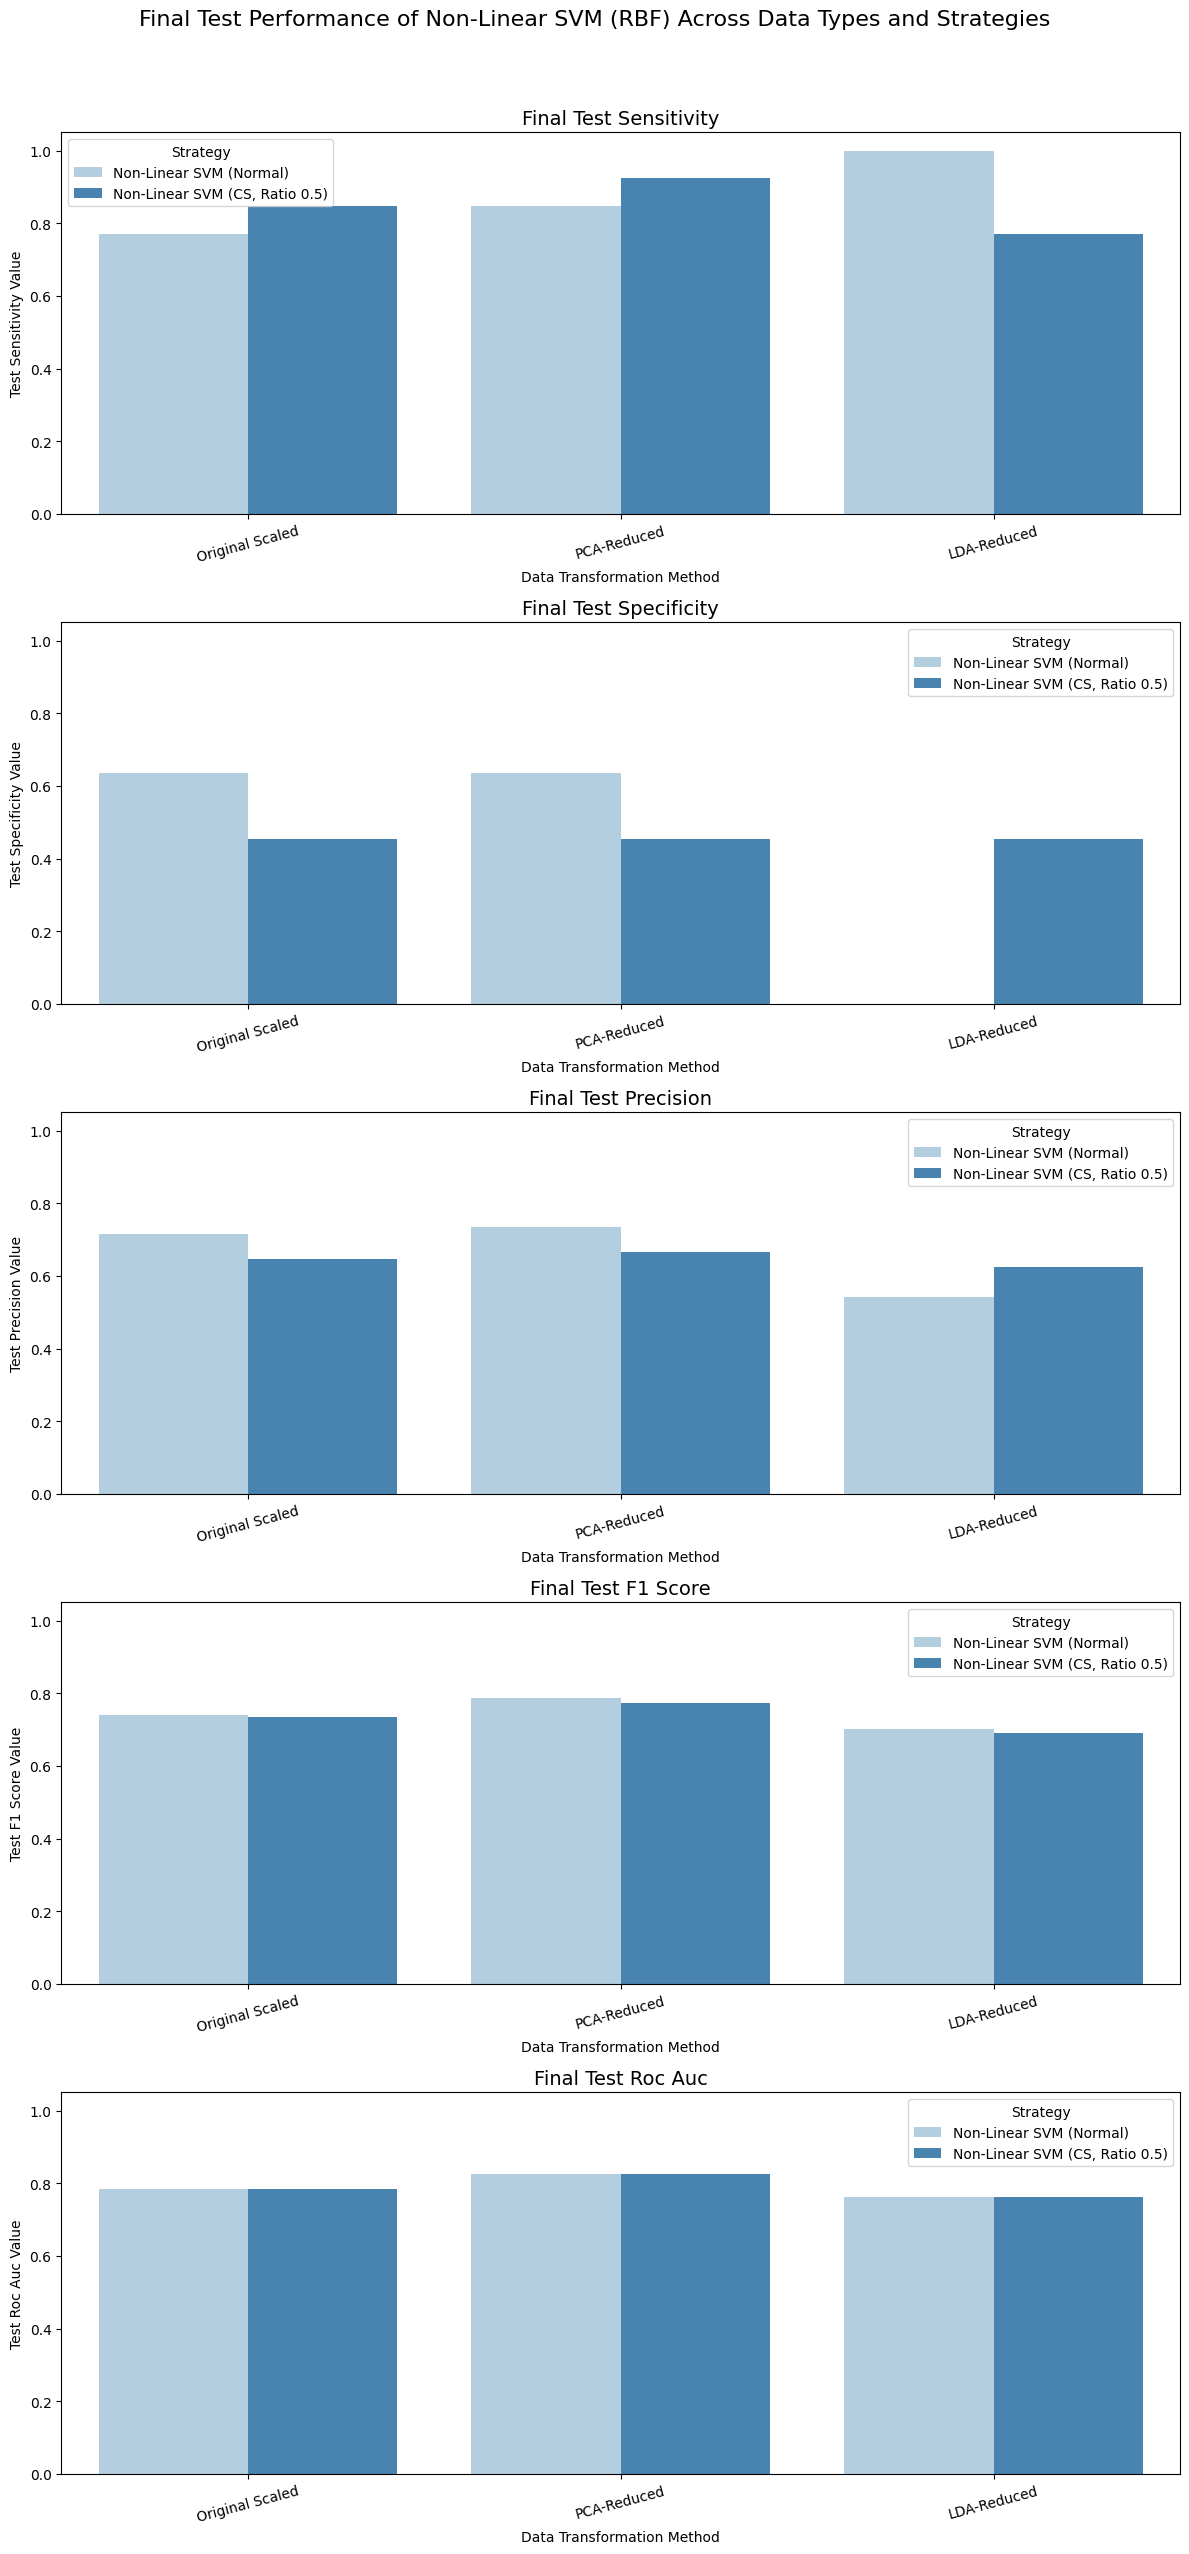

In [51]:
#12) PERFORMANCE EVALUATION (non-linear SVM results comparison)
data_for_plot_nonlinear_svm_test = []
metrics_to_plot_nonlinear_svm = ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']

for data_type_name, classifiers in test_results_nonlinear.items():
    for strategy_key in ['NonLinear SVM_Normal', 'NonLinear SVM_Cost_Sensitive']:
        if strategy_key in classifiers:
            final_metrics = classifiers[strategy_key]

            if strategy_key == 'NonLinear SVM_Normal':
                strategy_label = 'Non-Linear SVM (Normal)'
            else:
                strategy_label = f'Non-Linear SVM (CS, Ratio {COST_RATIO_SVM_CS})'

            for metric_name in metrics_to_plot_nonlinear_svm:
                value = final_metrics.get(metric_name)

                if value is None:
                    continue

                data_for_plot_nonlinear_svm_test.append({
                    'Classifier': strategy_label,
                    'Data Type': data_type_name,
                    'Metric': metric_name.replace('_', ' ').title(),
                    'Value': value,
                    'Std': 0.0
                })

plot_df_test_nonlinear_svm = pd.DataFrame(data_for_plot_nonlinear_svm_test)
fig, axes = plt.subplots(nrows=len(metrics_to_plot_nonlinear_svm), ncols=1, figsize=(12, 5 * len(metrics_to_plot_nonlinear_svm)))
fig.suptitle('Final Test Performance of Non-Linear SVM (RBF) Across Data Types and Strategies', fontsize=16, y=1.02)

for i, metric_name_raw in enumerate(metrics_to_plot_nonlinear_svm):
    metric_name_formatted = metric_name_raw.replace('_', ' ').title()

    df_metric = plot_df_test_nonlinear_svm[plot_df_test_nonlinear_svm['Metric'] == metric_name_formatted]

    sns.barplot(
        data=df_metric,
        x='Data Type',
        y='Value',
        hue='Classifier',
        ax=axes[i],
        palette='Blues',
        errorbar=None
    )

    axes[i].set_title(f'Final Test {metric_name_formatted}', fontsize=14)
    axes[i].set_ylabel(f'Test {metric_name_formatted} Value')
    axes[i].set_xlabel('Data Transformation Method')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(title='Strategy', loc='best')

plt.tight_layout()

In [52]:
#13) PERFORMANCE EVALUATION: DECISION TREE (all training data)
#hyperparameters for decision tree
param_grid_dt = {
    'max_depth': [1, 3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 15, 20]
}
COST_RATIO_DT_CS = 0.5
classes_list = [1, 2]

dt_results_nested = {
    'Original Scaled': {'normal': [], 'cost_sensitive': []},
    'PCA-Reduced': {'normal': [], 'cost_sensitive': []},
    'LDA-Reduced': {'normal': [], 'cost_sensitive': []}
}
best_params_dt_nested = {}

outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

print("Evaluating Decision Tree Classifier with Nested K-Fold CV on All Data Types")

data_configs = [
    {'key': 'Original Scaled', 'transformer_class': None},
    {'key': 'PCA-Reduced', 'transformer_class': PCA, 'n_components': num_components_selected},
    {'key': 'LDA-Reduced', 'transformer_class': LDA, 'n_components': 1}
]

#loop on different types of data
for config in data_configs:
    data_key = config['key']
    transformer_class = config['transformer_class']

    print(f"\nEvaluating Decision Tree on {data_key} Data")

    for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
        print(f"Outer Fold {outer_fold}")

        X_train_out_scaled, X_val_out_scaled = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
        Y_train_out, Y_val_out = Y_train.iloc[train_idx], Y_train.iloc[val_idx]

        X_train_fit = X_train_out_scaled.values
        X_val_fit = X_val_out_scaled.values

        if transformer_class is not None:
            if data_key == 'LDA-Reduced':
                if len(np.unique(Y_train_out)) < 2:
                    print(f"Skipping LDA for Outer Fold {outer_fold}: only one class present in training data.")
                    empty_metrics = {metric: np.nan for metric in ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']}
                    dt_results_nested[data_key]['normal'].append(empty_metrics)
                    dt_results_nested[data_key]['cost_sensitive'].append(empty_metrics)
                    continue

                transformer = transformer_class(n_components=config['n_components'])
                X_train_fit = transformer.fit_transform(X_train_out_scaled, Y_train_out)
                X_val_fit = transformer.transform(X_val_out_scaled)

            elif data_key == 'PCA-Reduced':
                n_features_in_fold = X_train_out_scaled.shape[1]
                n_comp = min(config['n_components'], n_features_in_fold)

                if n_comp < 1:
                    print(f"Skipping PCA for Outer Fold {outer_fold}: Insufficient features ({n_features_in_fold}) for PCA.")
                    empty_metrics = {metric: np.nan for metric in ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']}
                    dt_results_nested[data_key]['normal'].append(empty_metrics)
                    dt_results_nested[data_key]['cost_sensitive'].append(empty_metrics)
                    continue

                transformer = transformer_class(n_components=n_comp, random_state=1)
                X_train_fit = transformer.fit_transform(X_train_out_scaled)
                X_val_fit = transformer.transform(X_val_out_scaled)

        grid_search = GridSearchCV(
            DecisionTreeClassifier(random_state=1),
            param_grid_dt,
            cv=inner_cv_scaled,
            scoring='roc_auc',
            n_jobs=-1
        )
        grid_search.fit(X_train_fit, Y_train_out)

        best_params = grid_search.best_params_
        best_params_dt_nested[f'{data_key}_Fold{outer_fold}'] = best_params
        print(f"Best params found: {best_params}")

        #outer loop validation
        best_dt = DecisionTreeClassifier(random_state=1, **best_params)
        best_dt.fit(X_train_fit, Y_train_out)

        y_proba_outer = best_dt.predict_proba(X_val_fit)

        #normal prediction
        y_pred_outer_normal = best_dt.predict(X_val_fit)
        dt_results_nested[data_key]['normal'].append(
            calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, classes_list)
        )

        #CS prediction
        y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, classes_list, COST_RATIO_DT_CS)
        dt_results_nested[data_key]['cost_sensitive'].append(
            calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, classes_list)
        )

#summary
print("\nSummary of Nested CV Results for Decision Tree Classifier")
for data_type, strategies in dt_results_nested.items():
    print(f"\nData Type: {data_type}")
    for strategy_name, metrics_list in strategies.items():
        if metrics_list:
            df = pd.DataFrame(metrics_list)
            print(f"Strategy: {strategy_name.replace('_', ' ').title()}")
            for k in df.columns:
                print(f"{k.capitalize()}: Mean={np.nanmean(df[k].values):.4f}, Std={np.nanstd(df[k].values):.4f}")

Evaluating Decision Tree Classifier with Nested K-Fold CV on All Data Types

Evaluating Decision Tree on Original Scaled Data
Outer Fold 1
Best params found: {'max_depth': 3, 'min_samples_leaf': 1}
Outer Fold 2
Best params found: {'max_depth': 3, 'min_samples_leaf': 1}
Outer Fold 3
Best params found: {'max_depth': 3, 'min_samples_leaf': 1}
Outer Fold 4
Best params found: {'max_depth': 5, 'min_samples_leaf': 5}

Evaluating Decision Tree on PCA-Reduced Data
Outer Fold 1
Best params found: {'max_depth': 3, 'min_samples_leaf': 1}
Outer Fold 2
Best params found: {'max_depth': 3, 'min_samples_leaf': 1}
Outer Fold 3
Best params found: {'max_depth': 3, 'min_samples_leaf': 1}
Outer Fold 4
Best params found: {'max_depth': 7, 'min_samples_leaf': 1}

Evaluating Decision Tree on LDA-Reduced Data
Outer Fold 1
Best params found: {'max_depth': 3, 'min_samples_leaf': 10}
Outer Fold 2
Best params found: {'max_depth': 3, 'min_samples_leaf': 10}
Outer Fold 3
Best params found: {'max_depth': 1, 'min_sample

In [53]:
#13) PERFORMANCE EVALUATION: DECISION TREE (test data)
test_results = test_results if 'test_results' in globals() else {}
for key in ['Original Scaled', 'PCA-Reduced', 'LDA-Reduced']:
    if key not in test_results: test_results[key] = {}

param_grid_dt = {
    'max_depth': [1, 3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 5, 10, 15, 20]
}
COST_RATIO_DT_CS = 0.5
classes_list = [1, 2]

#1) Decision Tree on Selected Scaled Test Data
print("\nFinal Test Evaluation: Decision Tree on Original Scaled Data")
grid_search_scaled = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid_dt,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_scaled.fit(X_train_scaled, Y_train)
best_params_scaled = grid_search_scaled.best_params_
print(f"Best parameters for Original Scaled Data: {best_params_scaled}")

dt_final_scaled = DecisionTreeClassifier(random_state=1, **best_params_scaled)
dt_final_scaled.fit(X_train_scaled, Y_train)

y_proba_scaled = dt_final_scaled.predict_proba(X_test_scaled)

#normal prediction
y_test_pred_scaled_normal = dt_final_scaled.predict(X_test_scaled)
final_metrics_scaled_normal = calculate_metrics(Y_test, y_test_pred_scaled_normal, y_proba_scaled, classes_list)
test_results['Original Scaled']['Decision Tree_Normal'] = final_metrics_scaled_normal
print("Normal Prediction:")
for k, v in final_metrics_scaled_normal.items():
    print(f"{k}: {v:.4f}")

#CS prediction
y_test_pred_scaled_cs = predict_cost_sensitive(y_proba_scaled, classes_list, COST_RATIO_DT_CS)
final_metrics_scaled_cs = calculate_metrics(Y_test, y_test_pred_scaled_cs, y_proba_scaled, classes_list)
test_results['Original Scaled']['Decision Tree_Cost_Sensitive'] = final_metrics_scaled_cs
print(f"CS Prediction (Ratio={COST_RATIO_DT_CS}):")
for k, v in final_metrics_scaled_cs.items():
    print(f"{k}: {v:.4f}")

# 2) Decision Tree on PCA-Reduced Test Data
print("\nFinal Test Evaluation: Decision Tree on PCA-Reduced Data")

if 'X_train_pcaDF' not in globals() or X_train_pcaDF.shape[1] != num_components_selected:
    pca_final_dt = PCA(n_components=num_components_selected)
    X_train_pca_np_dt = pca_final_dt.fit_transform(X_train_scaled)
    X_test_pca_np_dt  = pca_final_dt.transform(X_test_scaled)

    pca_cols_dt = [f'PC{i+1}' for i in range(num_components_selected)]
    X_train_pcaDF = pd.DataFrame(X_train_pca_np_dt, columns=pca_cols_dt, index=X_train_scaled.index)
    X_test_pcaDF  = pd.DataFrame(X_test_pca_np_dt,  columns=pca_cols_dt, index=X_test_scaled.index)

grid_search_pca = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid_dt,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_pca.fit(X_train_pcaDF, Y_train)
best_params_pca = grid_search_pca.best_params_
print(f"Best parameters for PCA-Reduced Data: {best_params_pca}")

dt_final_pca = DecisionTreeClassifier(random_state=1, **best_params_pca)
dt_final_pca.fit(X_train_pcaDF, Y_train)

y_proba_pca = dt_final_pca.predict_proba(X_test_pcaDF)

y_test_pred_pca_normal = dt_final_pca.predict(X_test_pcaDF)
final_metrics_pca_normal = calculate_metrics(Y_test, y_test_pred_pca_normal, y_proba_pca, classes_list)
test_results['PCA-Reduced']['Decision Tree_Normal'] = final_metrics_pca_normal
print("Normal Prediction:")
for k, v in final_metrics_pca_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_pca_cs = predict_cost_sensitive(y_proba_pca, classes_list, COST_RATIO_DT_CS)
final_metrics_pca_cs = calculate_metrics(Y_test, y_test_pred_pca_cs, y_proba_pca, classes_list)
test_results['PCA-Reduced']['Decision Tree_Cost_Sensitive'] = final_metrics_pca_cs
print(f"CS Prediction (Ratio={COST_RATIO_DT_CS}):")
for k, v in final_metrics_pca_cs.items():
    print(f"{k}: {v:.4f}")

#3) Decision Tree on LDA-Reduced Test Data
print("\nFinal Test Evaluation: Decision Tree on LDA-Reduced Data")

if 'X_train_ldaDF' not in globals() or X_train_ldaDF.shape[1] != 1:
    lda_final_dt = LDA(n_components=1)
    X_train_lda_np_dt = lda_final_dt.fit_transform(X_train_scaled, Y_train)
    X_test_lda_np_dt  = lda_final_dt.transform(X_test_scaled)

    lda_cols_dt = ['LDA1']
    X_train_ldaDF = pd.DataFrame(X_train_lda_np_dt, columns=lda_cols_dt, index=X_train_scaled.index)
    X_test_ldaDF  = pd.DataFrame(X_test_lda_np_dt,  columns=lda_cols_dt, index=X_test_scaled.index)

grid_search_lda = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid_dt,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_lda.fit(X_train_ldaDF, Y_train)
best_params_lda = grid_search_lda.best_params_
print(f"Best parameters for LDA-Reduced Data: {best_params_lda}")

dt_final_lda = DecisionTreeClassifier(random_state=1, **best_params_lda)
dt_final_lda.fit(X_train_ldaDF, Y_train)

y_proba_lda = dt_final_lda.predict_proba(X_test_ldaDF)

y_test_pred_lda_normal = dt_final_lda.predict(X_test_ldaDF)
final_metrics_lda_normal = calculate_metrics(Y_test, y_test_pred_lda_normal, y_proba_lda, classes_list)
test_results['LDA-Reduced']['Decision Tree_Normal'] = final_metrics_lda_normal
print("Normal Prediction:")
for k, v in final_metrics_lda_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_lda_cs = predict_cost_sensitive(y_proba_lda, classes_list, COST_RATIO_DT_CS)
final_metrics_lda_cs = calculate_metrics(Y_test, y_test_pred_lda_cs, y_proba_lda, classes_list)
test_results['LDA-Reduced']['Decision Tree_Cost_Sensitive'] = final_metrics_lda_cs
print(f"CS Prediction (Ratio={COST_RATIO_DT_CS}):")
for k, v in final_metrics_lda_cs.items():
    print(f"{k}: {v:.4f}")


Final Test Evaluation: Decision Tree on Original Scaled Data
Best parameters for Original Scaled Data: {'max_depth': 3, 'min_samples_leaf': 15}
Normal Prediction:
sensitivity: 0.6923
specificity: 0.5455
precision: 0.6429
f1_score: 0.6667
roc_auc: 0.7063
CS Prediction (Ratio=0.5):
sensitivity: 0.9231
specificity: 0.5455
precision: 0.7059
f1_score: 0.8000
roc_auc: 0.7063

Final Test Evaluation: Decision Tree on PCA-Reduced Data
Best parameters for PCA-Reduced Data: {'max_depth': 3, 'min_samples_leaf': 5}
Normal Prediction:
sensitivity: 0.8462
specificity: 0.5455
precision: 0.6875
f1_score: 0.7586
roc_auc: 0.8112
CS Prediction (Ratio=0.5):
sensitivity: 0.8462
specificity: 0.5455
precision: 0.6875
f1_score: 0.7586
roc_auc: 0.8112

Final Test Evaluation: Decision Tree on LDA-Reduced Data
Best parameters for LDA-Reduced Data: {'max_depth': 3, 'min_samples_leaf': 15}
Normal Prediction:
sensitivity: 0.8462
specificity: 0.4545
precision: 0.6471
f1_score: 0.7333
roc_auc: 0.7203
CS Prediction (R

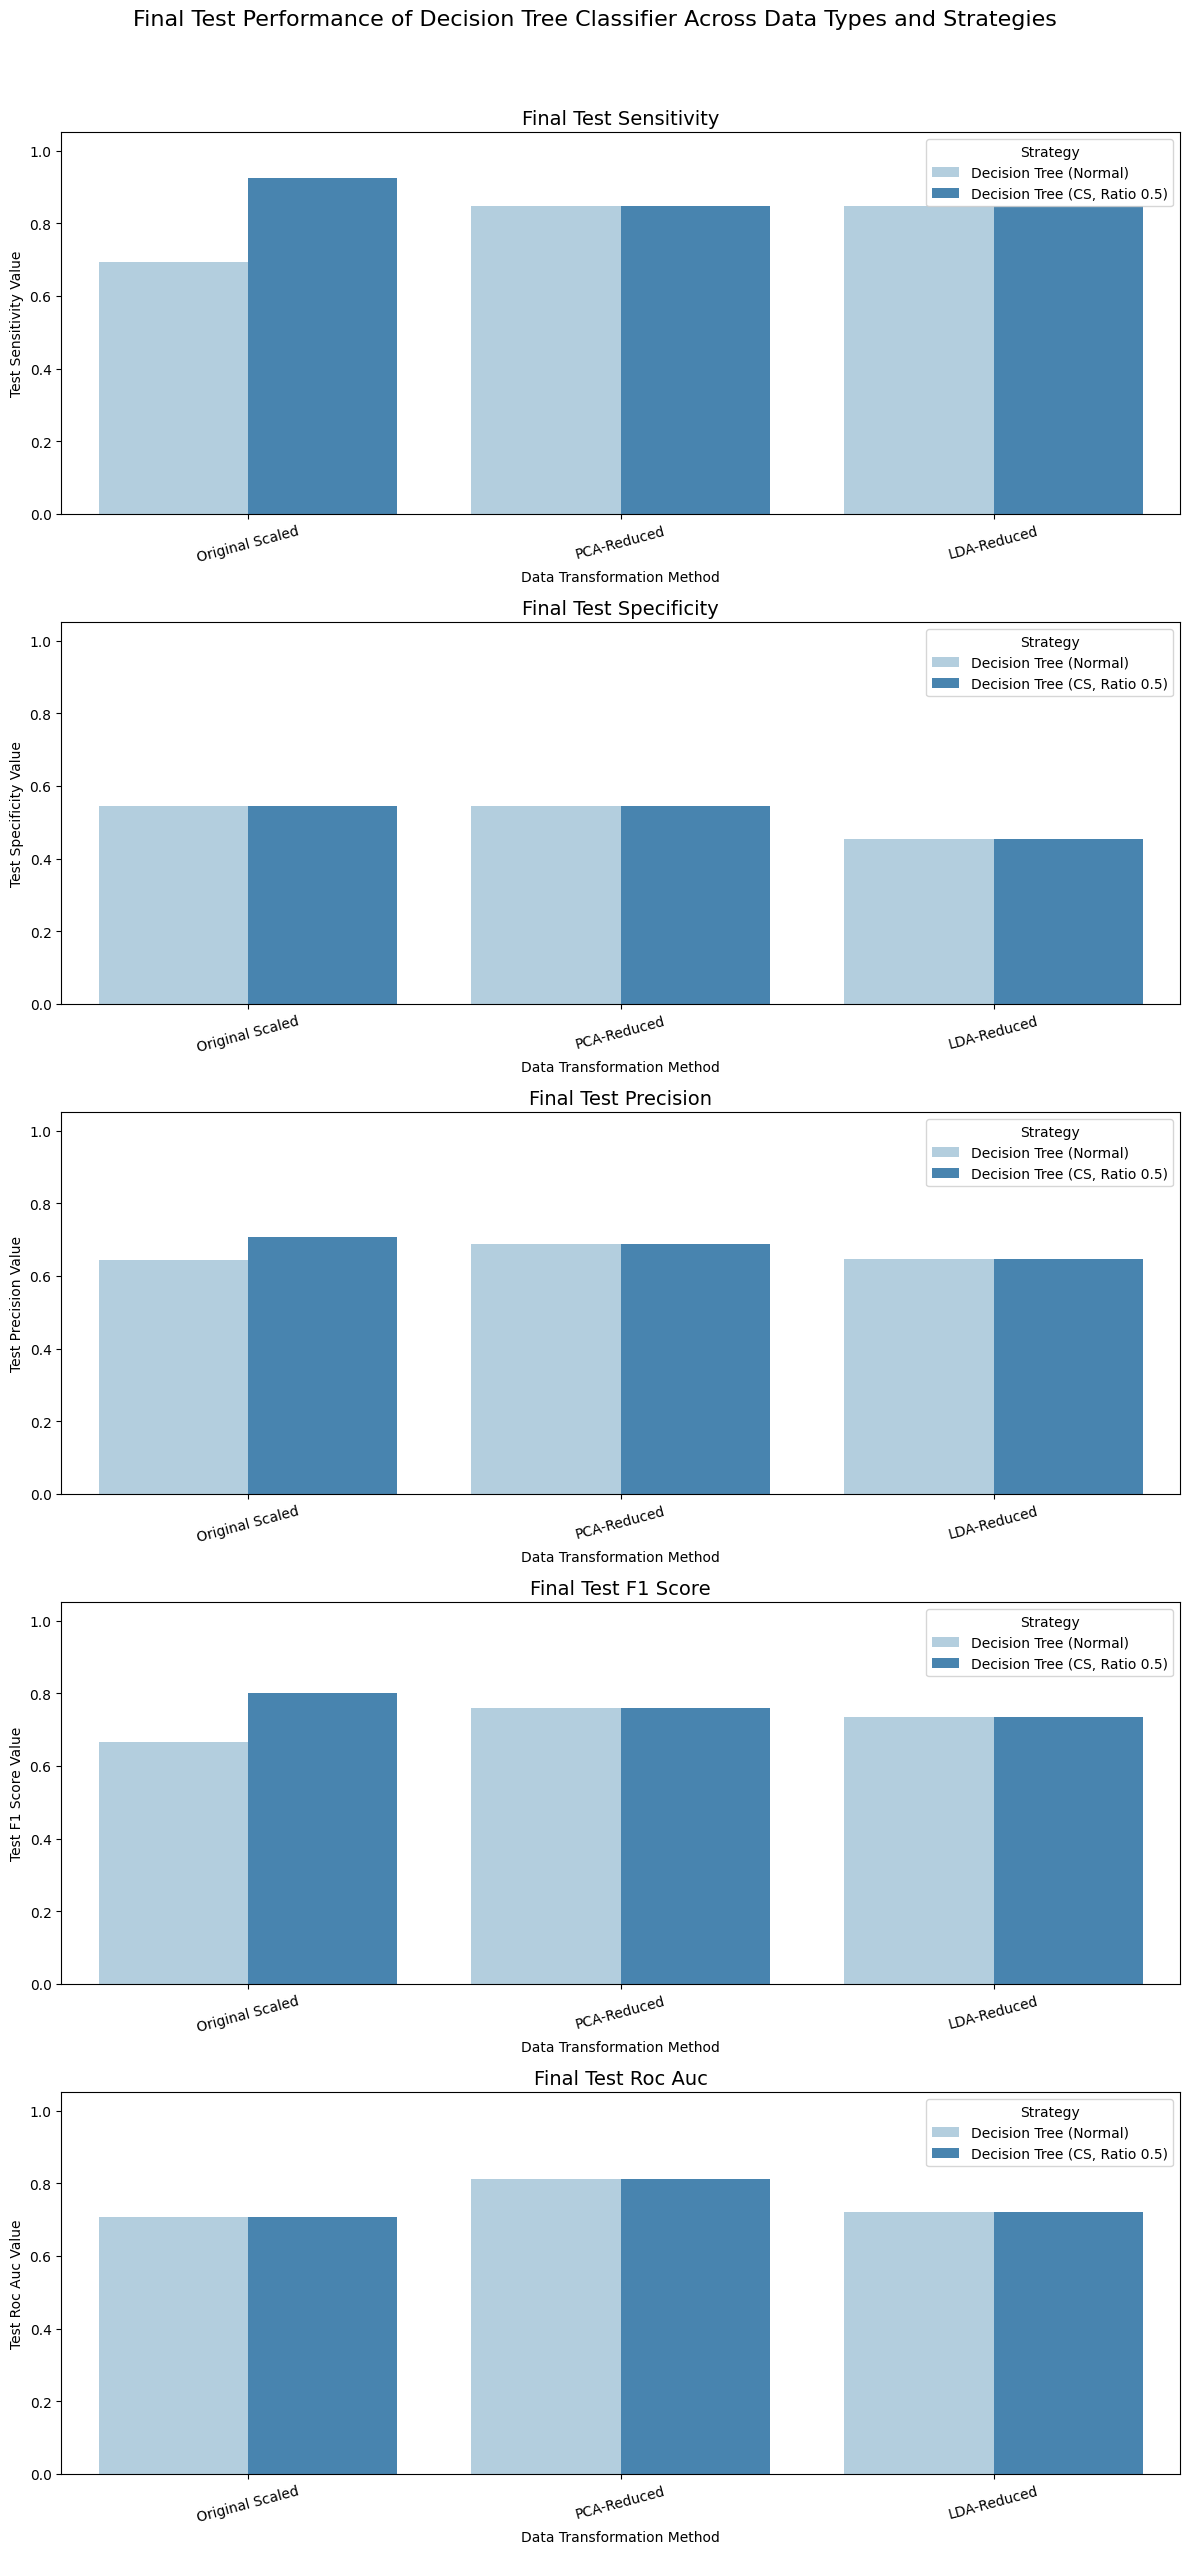

In [54]:
#13) PERFORMANCE EVALUATION (decision tree results comparison)
data_for_plot_dt_test = []
metrics_to_plot_dt = ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']

for data_type_name, classifiers in test_results.items():
    for strategy_key in ['Decision Tree_Normal', 'Decision Tree_Cost_Sensitive']:
        if strategy_key in classifiers:
            final_metrics = classifiers[strategy_key]

            if strategy_key == 'Decision Tree_Normal':
                strategy_label = 'Decision Tree (Normal)'
            else:
                strategy_label = f'Decision Tree (CS, Ratio {COST_RATIO_DT_CS})'

            for metric_name in metrics_to_plot_dt:
                value = final_metrics.get(metric_name)
                if value is None:
                    continue

                data_for_plot_dt_test.append({
                    'Classifier': strategy_label,
                    'Data Type': data_type_name,
                    'Metric': metric_name.replace('_', ' ').title(),
                    'Value': value,
                    'Std': 0.0
                })

plot_df_test_dt = pd.DataFrame(data_for_plot_dt_test)
fig, axes = plt.subplots(nrows=len(metrics_to_plot_dt), ncols=1, figsize=(12, 5 * len(metrics_to_plot_dt)))
fig.suptitle('Final Test Performance of Decision Tree Classifier Across Data Types and Strategies', fontsize=16, y=1.02)

for i, metric_name_raw in enumerate(metrics_to_plot_dt):
    metric_name_formatted = metric_name_raw.replace('_', ' ').title()

    df_metric = plot_df_test_dt[plot_df_test_dt['Metric'] == metric_name_formatted]

    sns.barplot(
        data=df_metric,
        x='Data Type',
        y='Value',
        hue='Classifier',
        ax=axes[i],
        palette='Blues',
        errorbar=None
    )

    axes[i].set_title(f'Final Test {metric_name_formatted}', fontsize=14)
    axes[i].set_ylabel(f'Test {metric_name_formatted} Value')
    axes[i].set_xlabel('Data Transformation Method')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(title='Strategy', loc='best')

plt.tight_layout()
plt.show()

In [55]:
#14) PERFORMANCE EVALUATION: ADABOOST (all training data)
#hyperparameters for AdaBoost
param_grid_adaboost = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}
COST_RATIO_ADABOOST_CS = 0.5
classes_list = [1, 2]

adaboost_results_nested = {
    'Original Scaled': {'normal': [], 'cost_sensitive': []},
    'PCA-Reduced': {'normal': [], 'cost_sensitive': []},
    'LDA-Reduced': {'normal': [], 'cost_sensitive': []}
}

outer_cv_scaled = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)
inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

print("Evaluating AdaBoost Classifier with Nested K-Fold CV on All Data Types")

data_configs = [
    {'key': 'Original Scaled', 'transformer_class': None, 'n_components': None},
    {'key': 'PCA-Reduced', 'transformer_class': PCA, 'n_components': num_components_selected},
    {'key': 'LDA-Reduced', 'transformer_class': LDA, 'n_components': 1}
]

#loop on different types of data
for config in data_configs:
    data_key = config['key']
    transformer_class = config['transformer_class']
    n_components_config = config['n_components']

    print(f"\nEvaluating AdaBoost on {data_key} Data")

    for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
        print(f"Outer Fold {outer_fold}")

        X_train_out_scaled, X_val_out_scaled = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
        Y_train_out, Y_val_out = Y_train.iloc[train_idx], Y_train.iloc[val_idx]

        X_train_fit = X_train_out_scaled.values
        X_val_fit = X_val_out_scaled.values

        if transformer_class is not None:
            if data_key == 'LDA-Reduced':
                if len(np.unique(Y_train_out)) < 2 or len(np.unique(Y_val_out)) < 2:
                    print(f"Skipping LDA for Outer Fold {outer_fold}: only one class present in training or validation data.")
                    empty_metrics = {metric: np.nan for metric in ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']}
                    adaboost_results_nested[data_key]['normal'].append(empty_metrics)
                    adaboost_results_nested[data_key]['cost_sensitive'].append(empty_metrics)
                    continue

                transformer = transformer_class(n_components=n_components_config)
                X_train_fit = transformer.fit_transform(X_train_out_scaled, Y_train_out)
                X_val_fit = transformer.transform(X_val_out_scaled)

            elif data_key == 'PCA-Reduced':
                n_features_in_fold = X_train_out_scaled.shape[1]
                n_comp = min(n_components_config, n_features_in_fold)

                if n_comp < 1:
                    print(f"Skipping PCA for Outer Fold {outer_fold}: Insufficient features ({n_features_in_fold}) for PCA.")
                    empty_metrics = {metric: np.nan for metric in ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']}
                    adaboost_results_nested[data_key]['normal'].append(empty_metrics)
                    adaboost_results_nested[data_key]['cost_sensitive'].append(empty_metrics)
                    continue

                transformer = transformer_class(n_components=n_comp, random_state=1)
                X_train_fit = transformer.fit_transform(X_train_out_scaled)
                X_val_fit = transformer.transform(X_val_out_scaled)

        grid_search = GridSearchCV(
            AdaBoostClassifier(random_state=1),
            param_grid_adaboost,
            cv=inner_cv_scaled,
            scoring='roc_auc',
            n_jobs=-1
        )
        grid_search.fit(X_train_fit, Y_train_out)

        best_params = grid_search.best_params_
        print(f"Best params found: {best_params}")

        #outer loop validation
        best_adaboost = AdaBoostClassifier(random_state=1, **best_params)
        best_adaboost.fit(X_train_fit, Y_train_out)

        y_proba_outer = best_adaboost.predict_proba(X_val_fit)

        #normal prediction
        y_pred_outer_normal = best_adaboost.predict(X_val_fit)
        adaboost_results_nested[data_key]['normal'].append(
            calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, classes_list)
        )

        #CS prediction
        y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, classes_list, COST_RATIO_ADABOOST_CS)
        adaboost_results_nested[data_key]['cost_sensitive'].append(
            calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, classes_list)
        )

#summary
print("\nSummary of Nested CV Results for AdaBoost Classifier")
for data_type, strategies in adaboost_results_nested.items():
    print(f"\nData Type: {data_type}")
    for strategy_name, metrics_list in strategies.items():
        if metrics_list:
            df = pd.DataFrame(metrics_list)
            print(f"Strategy: {strategy_name.replace('_', ' ').title()}")
            for k in df.columns:
                print(f"{k.capitalize()}: Mean={np.nanmean(df[k].values):.4f}, Std={np.nanstd(df[k].values):.4f}")

Evaluating AdaBoost Classifier with Nested K-Fold CV on All Data Types

Evaluating AdaBoost on Original Scaled Data
Outer Fold 1
Best params found: {'learning_rate': 0.5, 'n_estimators': 200}
Outer Fold 2
Best params found: {'learning_rate': 0.01, 'n_estimators': 50}
Outer Fold 3
Best params found: {'learning_rate': 0.1, 'n_estimators': 150}
Outer Fold 4
Best params found: {'learning_rate': 0.1, 'n_estimators': 200}

Evaluating AdaBoost on PCA-Reduced Data
Outer Fold 1
Best params found: {'learning_rate': 0.1, 'n_estimators': 150}
Outer Fold 2
Best params found: {'learning_rate': 0.1, 'n_estimators': 50}
Outer Fold 3
Best params found: {'learning_rate': 0.5, 'n_estimators': 200}
Outer Fold 4
Best params found: {'learning_rate': 0.5, 'n_estimators': 150}

Evaluating AdaBoost on LDA-Reduced Data
Outer Fold 1
Best params found: {'learning_rate': 0.1, 'n_estimators': 50}
Outer Fold 2
Best params found: {'learning_rate': 0.5, 'n_estimators': 150}
Outer Fold 3
Best params found: {'learning_r

In [56]:
#14) PERFORMANCE EVALUATION: ADABOOST (test data)
param_grid_adaboost = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}
COST_RATIO_ADABOOST_CS = 0.5
classes_list = [1, 2]

test_results = test_results if 'test_results' in globals() else {}
for key in ['Original Scaled', 'PCA-Reduced', 'LDA-Reduced']:
    if key not in test_results: test_results[key] = {}

inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

print("Evaluating AdaBoost Classifier Performances on Test Data")

#1) AdaBoost on Selected Scaled Test Data
data_key = 'Original Scaled'
print(f"\nFinal Test Evaluation: AdaBoost on {data_key} Data")

grid_search_scaled = GridSearchCV(
    AdaBoostClassifier(random_state=1),
    param_grid_adaboost,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_scaled.fit(X_train_scaled, Y_train)
best_params_scaled = grid_search_scaled.best_params_
print(f"Best parameters for {data_key} Data: {best_params_scaled}")

adaboost_final_scaled = AdaBoostClassifier(random_state=1, **best_params_scaled)
adaboost_final_scaled.fit(X_train_scaled, Y_train)

y_proba_scaled = adaboost_final_scaled.predict_proba(X_test_scaled)

#normal prediction
y_test_pred_scaled_normal = adaboost_final_scaled.predict(X_test_scaled)
final_metrics_scaled_normal = calculate_metrics(Y_test, y_test_pred_scaled_normal, y_proba_scaled, classes_list)
test_results[data_key]['AdaBoost_Normal'] = final_metrics_scaled_normal
print("Normal Prediction:")
for k, v in final_metrics_scaled_normal.items():
    print(f"{k}: {v:.4f}")

#CS prediction
y_test_pred_scaled_cs = predict_cost_sensitive(y_proba_scaled, classes_list, COST_RATIO_ADABOOST_CS)
final_metrics_scaled_cs = calculate_metrics(Y_test, y_test_pred_scaled_cs, y_proba_scaled, classes_list)
test_results[data_key]['AdaBoost_Cost_Sensitive'] = final_metrics_scaled_cs
print(f"CS Prediction (Ratio={COST_RATIO_ADABOOST_CS}):")
for k, v in final_metrics_scaled_cs.items():
    print(f"{k}: {v:.4f}")

#2) AdaBoost on PCA-Reduced Test Data
data_key = 'PCA-Reduced'
print(f"\nFinal Test Evaluation: AdaBoost on {data_key} Data")

pca_final = PCA(n_components=num_components_selected)
X_train_pca_np = pca_final.fit_transform(X_train_scaled)
X_test_pca_np  = pca_final.transform(X_test_scaled)

pca_cols = [f'PC{i+1}' for i in range(num_components_selected)]
X_train_pcaDF = pd.DataFrame(X_train_pca_np, columns=pca_cols)
X_test_pcaDF  = pd.DataFrame(X_test_pca_np, columns=pca_cols)

grid_search_pca = GridSearchCV(
    AdaBoostClassifier(random_state=1),
    param_grid_adaboost,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_pca.fit(X_train_pcaDF, Y_train)
best_params_pca = grid_search_pca.best_params_
print(f"Best parameters for {data_key} Data: {best_params_pca}")

adaboost_final_pca = AdaBoostClassifier(random_state=1, **best_params_pca)
adaboost_final_pca.fit(X_train_pcaDF, Y_train)

y_proba_pca = adaboost_final_pca.predict_proba(X_test_pcaDF)

y_test_pred_pca_normal = adaboost_final_pca.predict(X_test_pcaDF)
final_metrics_pca_normal = calculate_metrics(Y_test, y_test_pred_pca_normal, y_proba_pca, classes_list)
test_results[data_key]['AdaBoost_Normal'] = final_metrics_pca_normal
print("Normal Prediction:")
for k, v in final_metrics_pca_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_pca_cs = predict_cost_sensitive(y_proba_pca, classes_list, COST_RATIO_ADABOOST_CS)
final_metrics_pca_cs = calculate_metrics(Y_test, y_test_pred_pca_cs, y_proba_pca, classes_list)
test_results[data_key]['AdaBoost_Cost_Sensitive'] = final_metrics_pca_cs
print(f"CS Prediction (Ratio={COST_RATIO_ADABOOST_CS}):")
for k, v in final_metrics_pca_cs.items():
    print(f"{k}: {v:.4f}")

#3) AdaBoost on LDA-Reduced Test Data
data_key = 'LDA-Reduced'
print(f"\nFinal Test Evaluation: AdaBoost on {data_key} Data")

lda_final = LDA(n_components=1)
X_train_lda_np = lda_final.fit_transform(X_train_scaled, Y_train)
X_test_lda_np  = lda_final.transform(X_test_scaled)

lda_cols = ['LDA1']
X_train_ldaDF = pd.DataFrame(X_train_lda_np, columns=lda_cols)
X_test_ldaDF  = pd.DataFrame(X_test_lda_np, columns=lda_cols)

grid_search_lda = GridSearchCV(
    AdaBoostClassifier(random_state=1),
    param_grid_adaboost,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_lda.fit(X_train_ldaDF, Y_train)
best_params_lda = grid_search_lda.best_params_
print(f"Best parameters for {data_key} Data: {best_params_lda}")

adaboost_final_lda = AdaBoostClassifier(random_state=1, **best_params_lda)
adaboost_final_lda.fit(X_train_ldaDF, Y_train)

y_proba_lda = adaboost_final_lda.predict_proba(X_test_ldaDF)

y_test_pred_lda_normal = adaboost_final_lda.predict(X_test_ldaDF)
final_metrics_lda_normal = calculate_metrics(Y_test, y_test_pred_lda_normal, y_proba_lda, classes_list)
test_results[data_key]['AdaBoost_Normal'] = final_metrics_lda_normal
print("Normal Prediction:")
for k, v in final_metrics_lda_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_lda_cs = predict_cost_sensitive(y_proba_lda, classes_list, COST_RATIO_ADABOOST_CS)
final_metrics_lda_cs = calculate_metrics(Y_test, y_test_pred_lda_cs, y_proba_lda, classes_list)
test_results[data_key]['AdaBoost_Cost_Sensitive'] = final_metrics_lda_cs
print(f"CS Prediction (Ratio={COST_RATIO_ADABOOST_CS}):")
for k, v in final_metrics_lda_cs.items():
    print(f"{k}: {v:.4f}")

Evaluating AdaBoost Classifier Performances on Test Data

Final Test Evaluation: AdaBoost on Original Scaled Data
Best parameters for Original Scaled Data: {'learning_rate': 0.5, 'n_estimators': 100}
Normal Prediction:
sensitivity: 0.6923
specificity: 0.6364
precision: 0.6923
f1_score: 0.6923
roc_auc: 0.7238
CS Prediction (Ratio=0.5):
sensitivity: 1.0000
specificity: 0.0000
precision: 0.5417
f1_score: 0.7027
roc_auc: 0.7238

Final Test Evaluation: AdaBoost on PCA-Reduced Data
Best parameters for PCA-Reduced Data: {'learning_rate': 0.1, 'n_estimators': 150}
Normal Prediction:
sensitivity: 0.7692
specificity: 0.3636
precision: 0.5882
f1_score: 0.6667
roc_auc: 0.7797
CS Prediction (Ratio=0.5):
sensitivity: 1.0000
specificity: 0.0000
precision: 0.5417
f1_score: 0.7027
roc_auc: 0.7797

Final Test Evaluation: AdaBoost on LDA-Reduced Data
Best parameters for LDA-Reduced Data: {'learning_rate': 0.1, 'n_estimators': 100}
Normal Prediction:
sensitivity: 0.8462
specificity: 0.4545
precision: 0.64

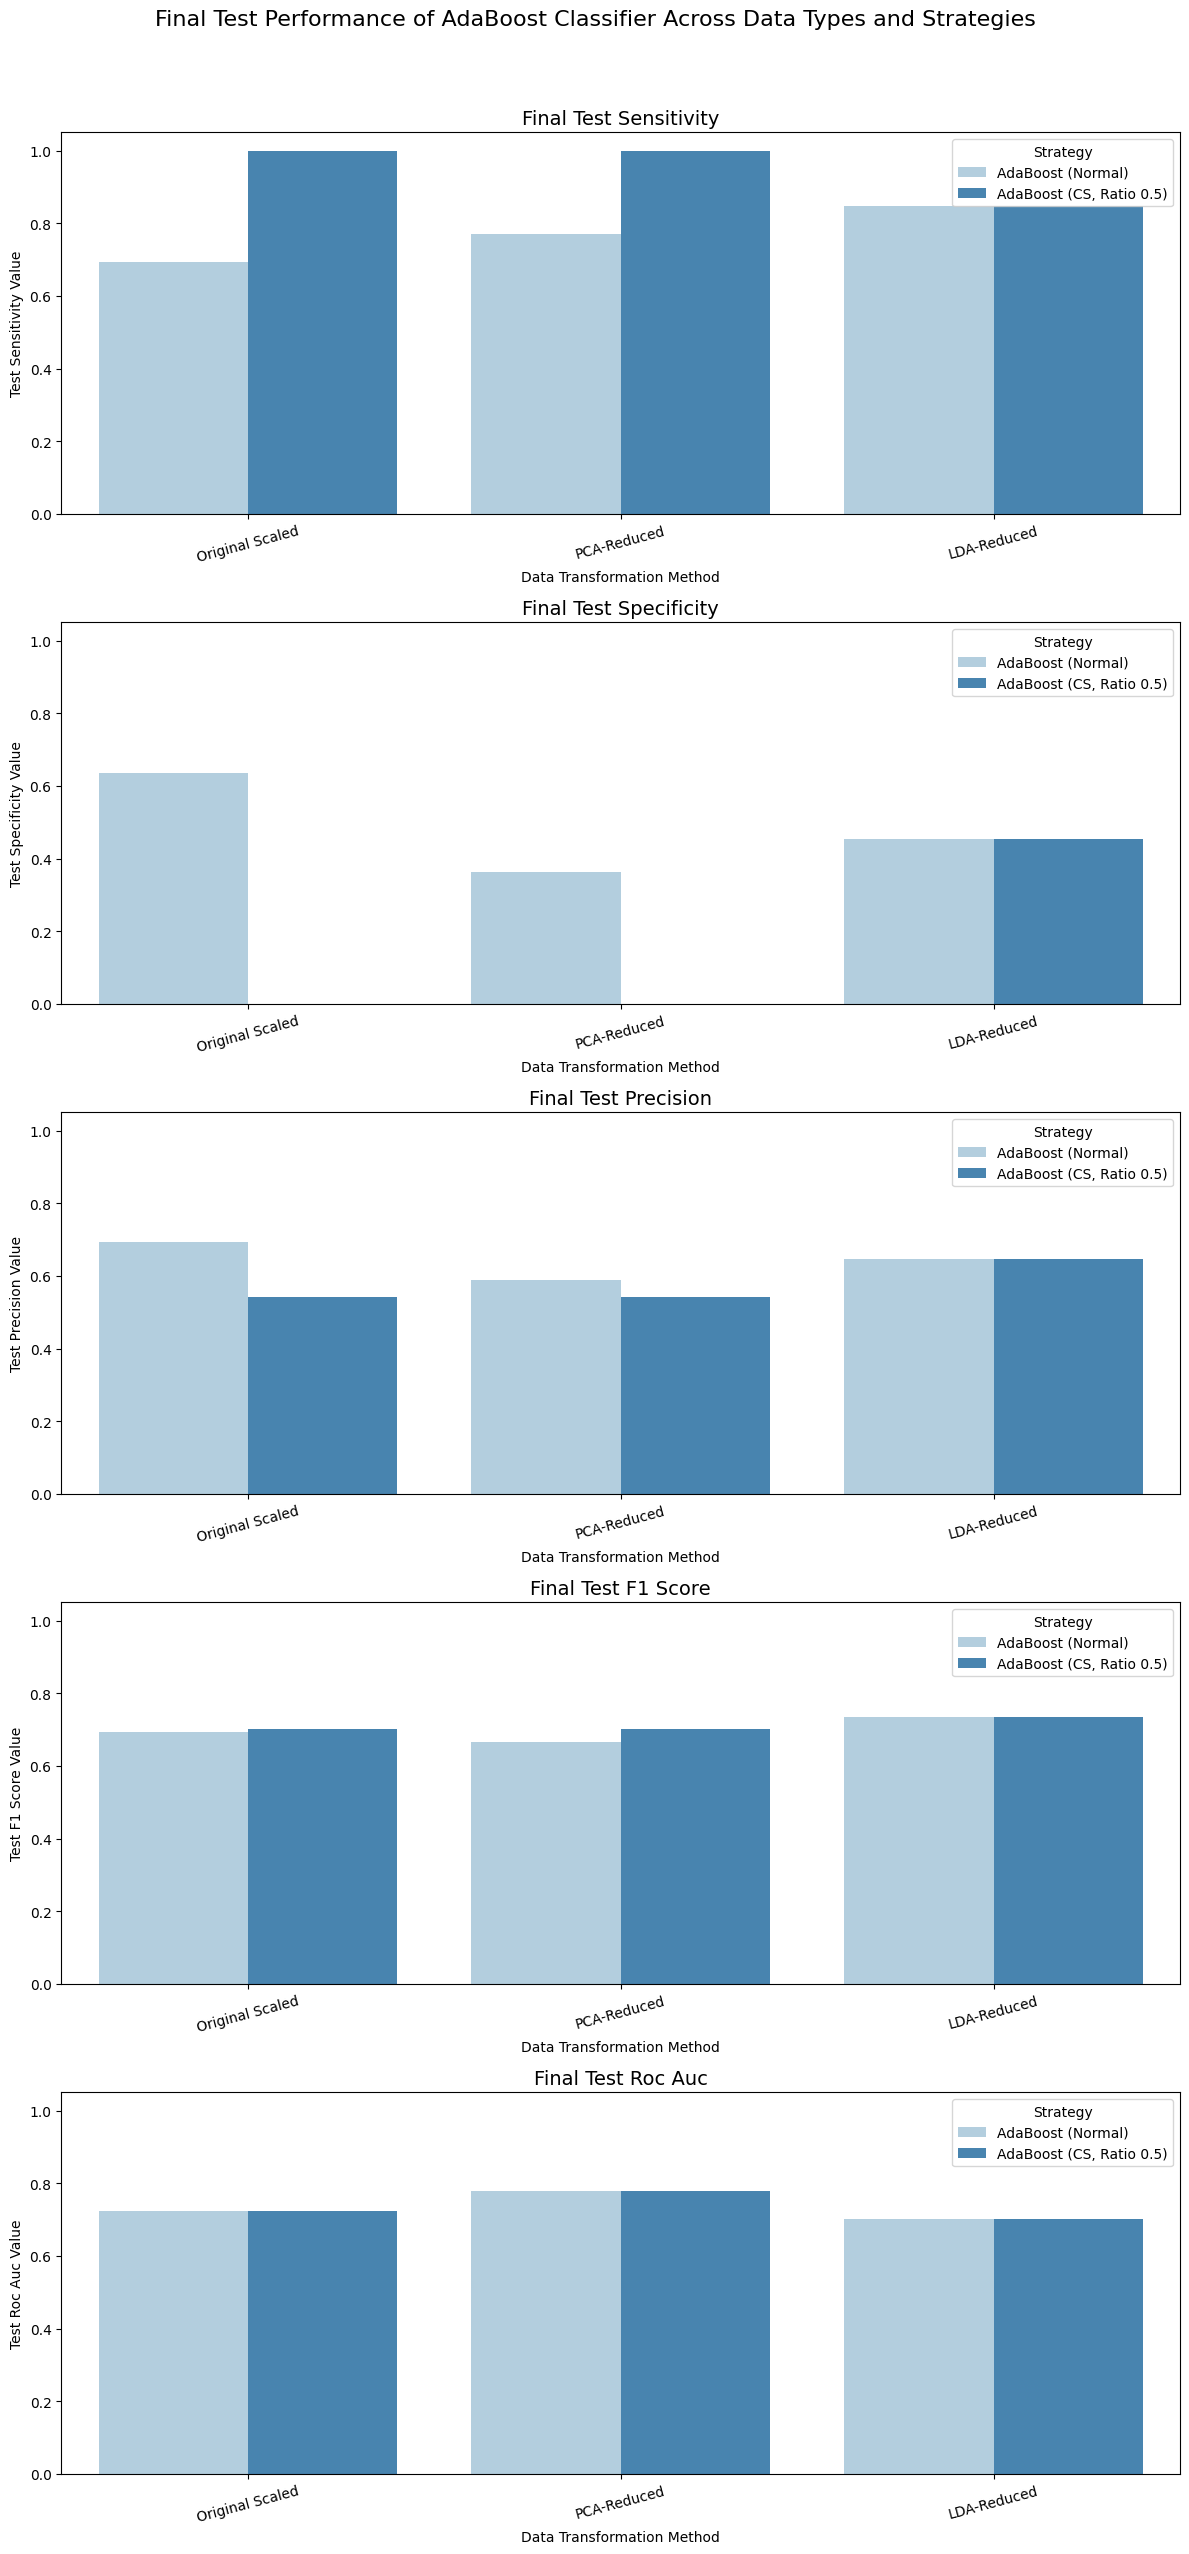

In [57]:
#14) PERFORMANCE EVALUATION (Adaboost results comparison)
data_for_plot_adaboost_test = []
metrics_to_plot_adaboost = ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']

for data_type_name, classifiers in test_results.items():
    for strategy_key in ['AdaBoost_Normal', 'AdaBoost_Cost_Sensitive']:
        if strategy_key in classifiers:
            final_metrics = classifiers[strategy_key]

            if strategy_key == 'AdaBoost_Normal':
                strategy_label = 'AdaBoost (Normal)'
            else:
                strategy_label = f'AdaBoost (CS, Ratio {COST_RATIO_ADABOOST_CS})'

            for metric_name in metrics_to_plot_adaboost:
                value = final_metrics.get(metric_name)
                if value is None:
                    continue

                data_for_plot_adaboost_test.append({
                    'Classifier': strategy_label,
                    'Data Type': data_type_name,
                    'Metric': metric_name.replace('_', ' ').title(),
                    'Value': value,
                    'Std': 0.0
                })

plot_df_test_adaboost = pd.DataFrame(data_for_plot_adaboost_test)
fig, axes = plt.subplots(nrows=len(metrics_to_plot_adaboost), ncols=1, figsize=(12, 5 * len(metrics_to_plot_adaboost)))
fig.suptitle('Final Test Performance of AdaBoost Classifier Across Data Types and Strategies', fontsize=16, y=1.02)

for i, metric_name_raw in enumerate(metrics_to_plot_adaboost):
    metric_name_formatted = metric_name_raw.replace('_', ' ').title()

    df_metric = plot_df_test_adaboost[plot_df_test_adaboost['Metric'] == metric_name_formatted]

    sns.barplot(
        data=df_metric,
        x='Data Type',
        y='Value',
        hue='Classifier',
        ax=axes[i],
        palette='Blues',
        errorbar=None
    )

    axes[i].set_title(f'Final Test {metric_name_formatted}', fontsize=14)
    axes[i].set_ylabel(f'Test {metric_name_formatted} Value')
    axes[i].set_xlabel('Data Transformation Method')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(title='Strategy', loc='best')

plt.tight_layout()
plt.show()

In [58]:
#15) PERFORMANCE EVALUATION: RANDOM FOREST (all training data)
#hyperparameter for Random Forest Classifier
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 5, 10, 20]
}
COST_RATIO_RF_CS = 0.5
classes_list = [1, 2]

rf_results_nested = {
    'Original Scaled': {'normal': [], 'cost_sensitive': []},
    'PCA-Reduced': {'normal': [], 'cost_sensitive': []},
    'LDA-Reduced': {'normal': [], 'cost_sensitive': []}
}

print("Evaluating Random Forest Classifier with Nested K-Fold CV on All Data Types")

data_configs = [
    {'key': 'Original Scaled', 'transformer_class': None, 'n_components': None},
    {'key': 'PCA-Reduced', 'transformer_class': PCA, 'n_components': num_components_selected},
    {'key': 'LDA-Reduced', 'transformer_class': LDA, 'n_components': 1}
]

#iterate through each data configuration
for config in data_configs:
    data_key = config['key']
    transformer_class = config['transformer_class']
    n_components_config = config['n_components']

    print(f"\nEvaluating Random Forest on {data_key} Data")

    for outer_fold, (train_idx, val_idx) in enumerate(outer_cv_scaled.split(X_train_scaled, Y_train), start=1):
        print(f"Outer Fold {outer_fold}")

        X_train_out_scaled, X_val_out_scaled = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
        Y_train_out, Y_val_out = Y_train.iloc[train_idx], Y_train.iloc[val_idx]

        X_train_fit = X_train_out_scaled.values
        X_val_fit = X_val_out_scaled.values

        if transformer_class is not None:
            if data_key == 'LDA-Reduced':
                if len(np.unique(Y_train_out)) < 2 or len(np.unique(Y_val_out)) < 2:
                    print(f"Skipping LDA for Outer Fold {outer_fold}: only one class present in training or validation data.")
                    empty_metrics = {metric: np.nan for metric in ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']}
                    rf_results_nested[data_key]['normal'].append(empty_metrics)
                    rf_results_nested[data_key]['cost_sensitive'].append(empty_metrics)
                    continue

                transformer = transformer_class(n_components=n_components_config)
                X_train_fit = transformer.fit_transform(X_train_out_scaled, Y_train_out)
                X_val_fit = transformer.transform(X_val_out_scaled)
                #convert to DataFrame to maintain consistent behavior, especially for feature names/indexing if needed later
                X_train_fit = pd.DataFrame(X_train_fit, index=X_train_out_scaled.index, columns=[f'LD{i+1}' for i in range(X_train_fit.shape[1])])
                X_val_fit = pd.DataFrame(X_val_fit, index=X_val_out_scaled.index, columns=[f'LD{i+1}' for i in range(X_val_fit.shape[1])])

            elif data_key == 'PCA-Reduced':
                n_features_in_fold = X_train_out_scaled.shape[1]
                n_comp = min(n_components_config, n_features_in_fold)

                if n_comp < 1:
                    print(f"Skipping PCA for Outer Fold {outer_fold}: Insufficient features ({n_features_in_fold}) for PCA.")
                    empty_metrics = {metric: np.nan for metric in ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']}
                    rf_results_nested[data_key]['normal'].append(empty_metrics)
                    rf_results_nested[data_key]['cost_sensitive'].append(empty_metrics)
                    continue

                transformer = transformer_class(n_components=n_comp, random_state=1)
                X_train_fit = transformer.fit_transform(X_train_out_scaled)
                X_val_fit = transformer.transform(X_val_out_scaled)
                #convert to DataFrame
                X_train_fit = pd.DataFrame(X_train_fit, index=X_train_out_scaled.index, columns=[f'PC{i+1}' for i in range(X_train_fit.shape[1])])
                X_val_fit = pd.DataFrame(X_val_fit, index=X_val_out_scaled.index, columns=[f'PC{i+1}' for i in range(X_val_fit.shape[1])])

        grid_search = GridSearchCV(
            RandomForestClassifier(random_state=1),
            param_grid_rf,
            cv=inner_cv_scaled,
            scoring='roc_auc',
            n_jobs=-1
        )
        grid_search.fit(X_train_fit, Y_train_out)

        best_params = grid_search.best_params_
        print(f"Best params found: {best_params}")

        best_rf = RandomForestClassifier(random_state=1, **best_params)
        best_rf.fit(X_train_fit, Y_train_out)

        y_proba_outer = best_rf.predict_proba(X_val_fit)

        #normal prediction
        y_pred_outer_normal = best_rf.predict(X_val_fit)
        rf_results_nested[data_key]['normal'].append(
            calculate_metrics(Y_val_out, y_pred_outer_normal, y_proba_outer, classes_list)
        )

        #CS prediction
        y_pred_outer_cs = predict_cost_sensitive(y_proba_outer, classes_list, COST_RATIO_RF_CS)
        rf_results_nested[data_key]['cost_sensitive'].append(
            calculate_metrics(Y_val_out, y_pred_outer_cs, y_proba_outer, classes_list)
        )

#summary
print("\nSummary of Nested CV Results for Random Forest Classifier")
for data_type, strategies in rf_results_nested.items():
    print(f"\nData Type: {data_type}")
    for strategy_name, metrics_list in strategies.items():
        if metrics_list:
            df = pd.DataFrame(metrics_list)
            print(f"Strategy: {strategy_name.replace('_', ' ').title()}")
            for k in df.columns:
                print(f"{k.capitalize()}: Mean={np.nanmean(df[k].values):.4f}, Std={np.nanstd(df[k].values):.4f}")

Evaluating Random Forest Classifier with Nested K-Fold CV on All Data Types

Evaluating Random Forest on Original Scaled Data
Outer Fold 1
Best params found: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}
Outer Fold 2
Best params found: {'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 50}
Outer Fold 3
Best params found: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 50}
Outer Fold 4
Best params found: {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 200}

Evaluating Random Forest on PCA-Reduced Data
Outer Fold 1
Best params found: {'max_depth': 7, 'min_samples_leaf': 1, 'n_estimators': 50}
Outer Fold 2
Best params found: {'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 200}
Outer Fold 3
Best params found: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Outer Fold 4
Best params found: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}

Evaluating Random Forest on LDA-Reduced Data
Outer Fold 1
Best params found: {

In [59]:
#15) PERFORMANCE EVALUATION: RANDOM FOREST (test data)
test_results = test_results if 'test_results' in globals() else {}
for key in ['Original Scaled', 'PCA-Reduced', 'LDA-Reduced']:
    if key not in test_results: test_results[key] = {}

#hyperparameter for Random Forest Classifier
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_leaf': [1, 5, 10, 20]
}
COST_RATIO_RF_CS = 0.5
classes_list = [1, 2]

inner_cv_scaled = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

print("Evaluating Random Forest Classifier Performances on Test Data")

#1) Random Forest on Selected Scaled Test Data
data_key = 'Original Scaled'
print(f"\nFinal Test Evaluation: Random Forest on {data_key} Data")

grid_search_scaled = GridSearchCV(
    RandomForestClassifier(random_state=1),
    param_grid_rf,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_scaled.fit(X_train_scaled, Y_train)
best_params_scaled = grid_search_scaled.best_params_
print(f"Best parameters for {data_key} Data: {best_params_scaled}")

rf_final_scaled = RandomForestClassifier(random_state=1, **best_params_scaled)
rf_final_scaled.fit(X_train_scaled, Y_train)

y_proba_scaled = rf_final_scaled.predict_proba(X_test_scaled)

#normal prediction
y_test_pred_scaled_normal = rf_final_scaled.predict(X_test_scaled)
final_metrics_scaled_normal = calculate_metrics(Y_test, y_test_pred_scaled_normal, y_proba_scaled, classes_list)
test_results[data_key]['Random Forest_Normal'] = final_metrics_scaled_normal
print("Normal Prediction:")
for k, v in final_metrics_scaled_normal.items():
    print(f"{k}: {v:.4f}")

#CS prediction
y_test_pred_scaled_cs = predict_cost_sensitive(y_proba_scaled, classes_list, COST_RATIO_RF_CS)
final_metrics_scaled_cs = calculate_metrics(Y_test, y_test_pred_scaled_cs, y_proba_scaled, classes_list)
test_results[data_key]['Random Forest_Cost_Sensitive'] = final_metrics_scaled_cs
print(f"CS Prediction (Ratio={COST_RATIO_RF_CS}):")
for k, v in final_metrics_scaled_cs.items():
    print(f"{k}: {v:.4f}")

# 2) Random Forest on PCA-Reduced Test Data
data_key = 'PCA-Reduced'
print(f"\nFinal Test Evaluation: Random Forest on {data_key} Data")

pca_final = PCA(n_components=num_components_selected)
X_train_pca_np = pca_final.fit_transform(X_train_scaled)
X_test_pca_np  = pca_final.transform(X_test_scaled)

pca_cols = [f'PC{i+1}' for i in range(num_components_selected)]
X_train_pcaDF = pd.DataFrame(X_train_pca_np, columns=pca_cols)
X_test_pcaDF  = pd.DataFrame(X_test_pca_np, columns=pca_cols)

grid_search_pca = GridSearchCV(
    RandomForestClassifier(random_state=1),
    param_grid_rf,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_pca.fit(X_train_pcaDF, Y_train)
best_params_pca = grid_search_pca.best_params_
print(f"Best parameters for {data_key} Data: {best_params_pca}")

rf_final_pca = RandomForestClassifier(random_state=1, **best_params_pca)
rf_final_pca.fit(X_train_pcaDF, Y_train)

y_proba_pca = rf_final_pca.predict_proba(X_test_pcaDF)

y_test_pred_pca_normal = rf_final_pca.predict(X_test_pcaDF)
final_metrics_pca_normal = calculate_metrics(Y_test, y_test_pred_pca_normal, y_proba_pca, classes_list)
test_results[data_key]['Random Forest_Normal'] = final_metrics_pca_normal
print("Normal Prediction:")
for k, v in final_metrics_pca_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_pca_cs = predict_cost_sensitive(y_proba_pca, classes_list, COST_RATIO_RF_CS)
final_metrics_pca_cs = calculate_metrics(Y_test, y_test_pred_pca_cs, y_proba_pca, classes_list)
test_results[data_key]['Random Forest_Cost_Sensitive'] = final_metrics_pca_cs
print(f"CS Prediction (Ratio={COST_RATIO_RF_CS}):")
for k, v in final_metrics_pca_cs.items():
    print(f"{k}: {v:.4f}")

# 3) Random Forest on LDA-Reduced Test Data
data_key = 'LDA-Reduced'
print(f"\nFinal Test Evaluation: Random Forest on {data_key} Data")

lda_final = LDA(n_components=1)
X_train_lda_np = lda_final.fit_transform(X_train_scaled, Y_train)
X_test_lda_np  = lda_final.transform(X_test_scaled)

lda_cols = ['LDA1']
X_train_ldaDF = pd.DataFrame(X_train_lda_np, columns=lda_cols)
X_test_ldaDF  = pd.DataFrame(X_test_lda_np, columns=lda_cols)

grid_search_lda = GridSearchCV(
    RandomForestClassifier(random_state=1),
    param_grid_rf,
    cv=inner_cv_scaled,
    scoring='roc_auc',
    n_jobs=-1
)
grid_search_lda.fit(X_train_ldaDF, Y_train)
best_params_lda = grid_search_lda.best_params_
print(f"Best parameters for {data_key} Data: {best_params_lda}")

rf_final_lda = RandomForestClassifier(random_state=1, **best_params_lda)
rf_final_lda.fit(X_train_ldaDF, Y_train)

y_proba_lda = rf_final_lda.predict_proba(X_test_ldaDF)

y_test_pred_lda_normal = rf_final_lda.predict(X_test_ldaDF)
final_metrics_lda_normal = calculate_metrics(Y_test, y_test_pred_lda_normal, y_proba_lda, classes_list)
test_results[data_key]['Random Forest_Normal'] = final_metrics_lda_normal
print("Normal Prediction:")
for k, v in final_metrics_lda_normal.items():
    print(f"{k}: {v:.4f}")

y_test_pred_lda_cs = predict_cost_sensitive(y_proba_lda, classes_list, COST_RATIO_RF_CS)
final_metrics_lda_cs = calculate_metrics(Y_test, y_test_pred_lda_cs, y_proba_lda, classes_list)
test_results[data_key]['Random Forest_Cost_Sensitive'] = final_metrics_lda_cs
print(f"CS Prediction (Ratio={COST_RATIO_RF_CS}):")
for k, v in final_metrics_lda_cs.items():
    print(f"{k}: {v:.4f}")

Evaluating Random Forest Classifier Performances on Test Data

Final Test Evaluation: Random Forest on Original Scaled Data
Best parameters for Original Scaled Data: {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 150}
Normal Prediction:
sensitivity: 0.6154
specificity: 0.6364
precision: 0.6667
f1_score: 0.6400
roc_auc: 0.7692
CS Prediction (Ratio=0.5):
sensitivity: 1.0000
specificity: 0.3636
precision: 0.6500
f1_score: 0.7879
roc_auc: 0.7692

Final Test Evaluation: Random Forest on PCA-Reduced Data
Best parameters for PCA-Reduced Data: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 200}
Normal Prediction:
sensitivity: 0.8462
specificity: 0.2727
precision: 0.5789
f1_score: 0.6875
roc_auc: 0.6014
CS Prediction (Ratio=0.5):
sensitivity: 1.0000
specificity: 0.0000
precision: 0.5417
f1_score: 0.7027
roc_auc: 0.6014

Final Test Evaluation: Random Forest on LDA-Reduced Data
Best parameters for LDA-Reduced Data: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 150}
N

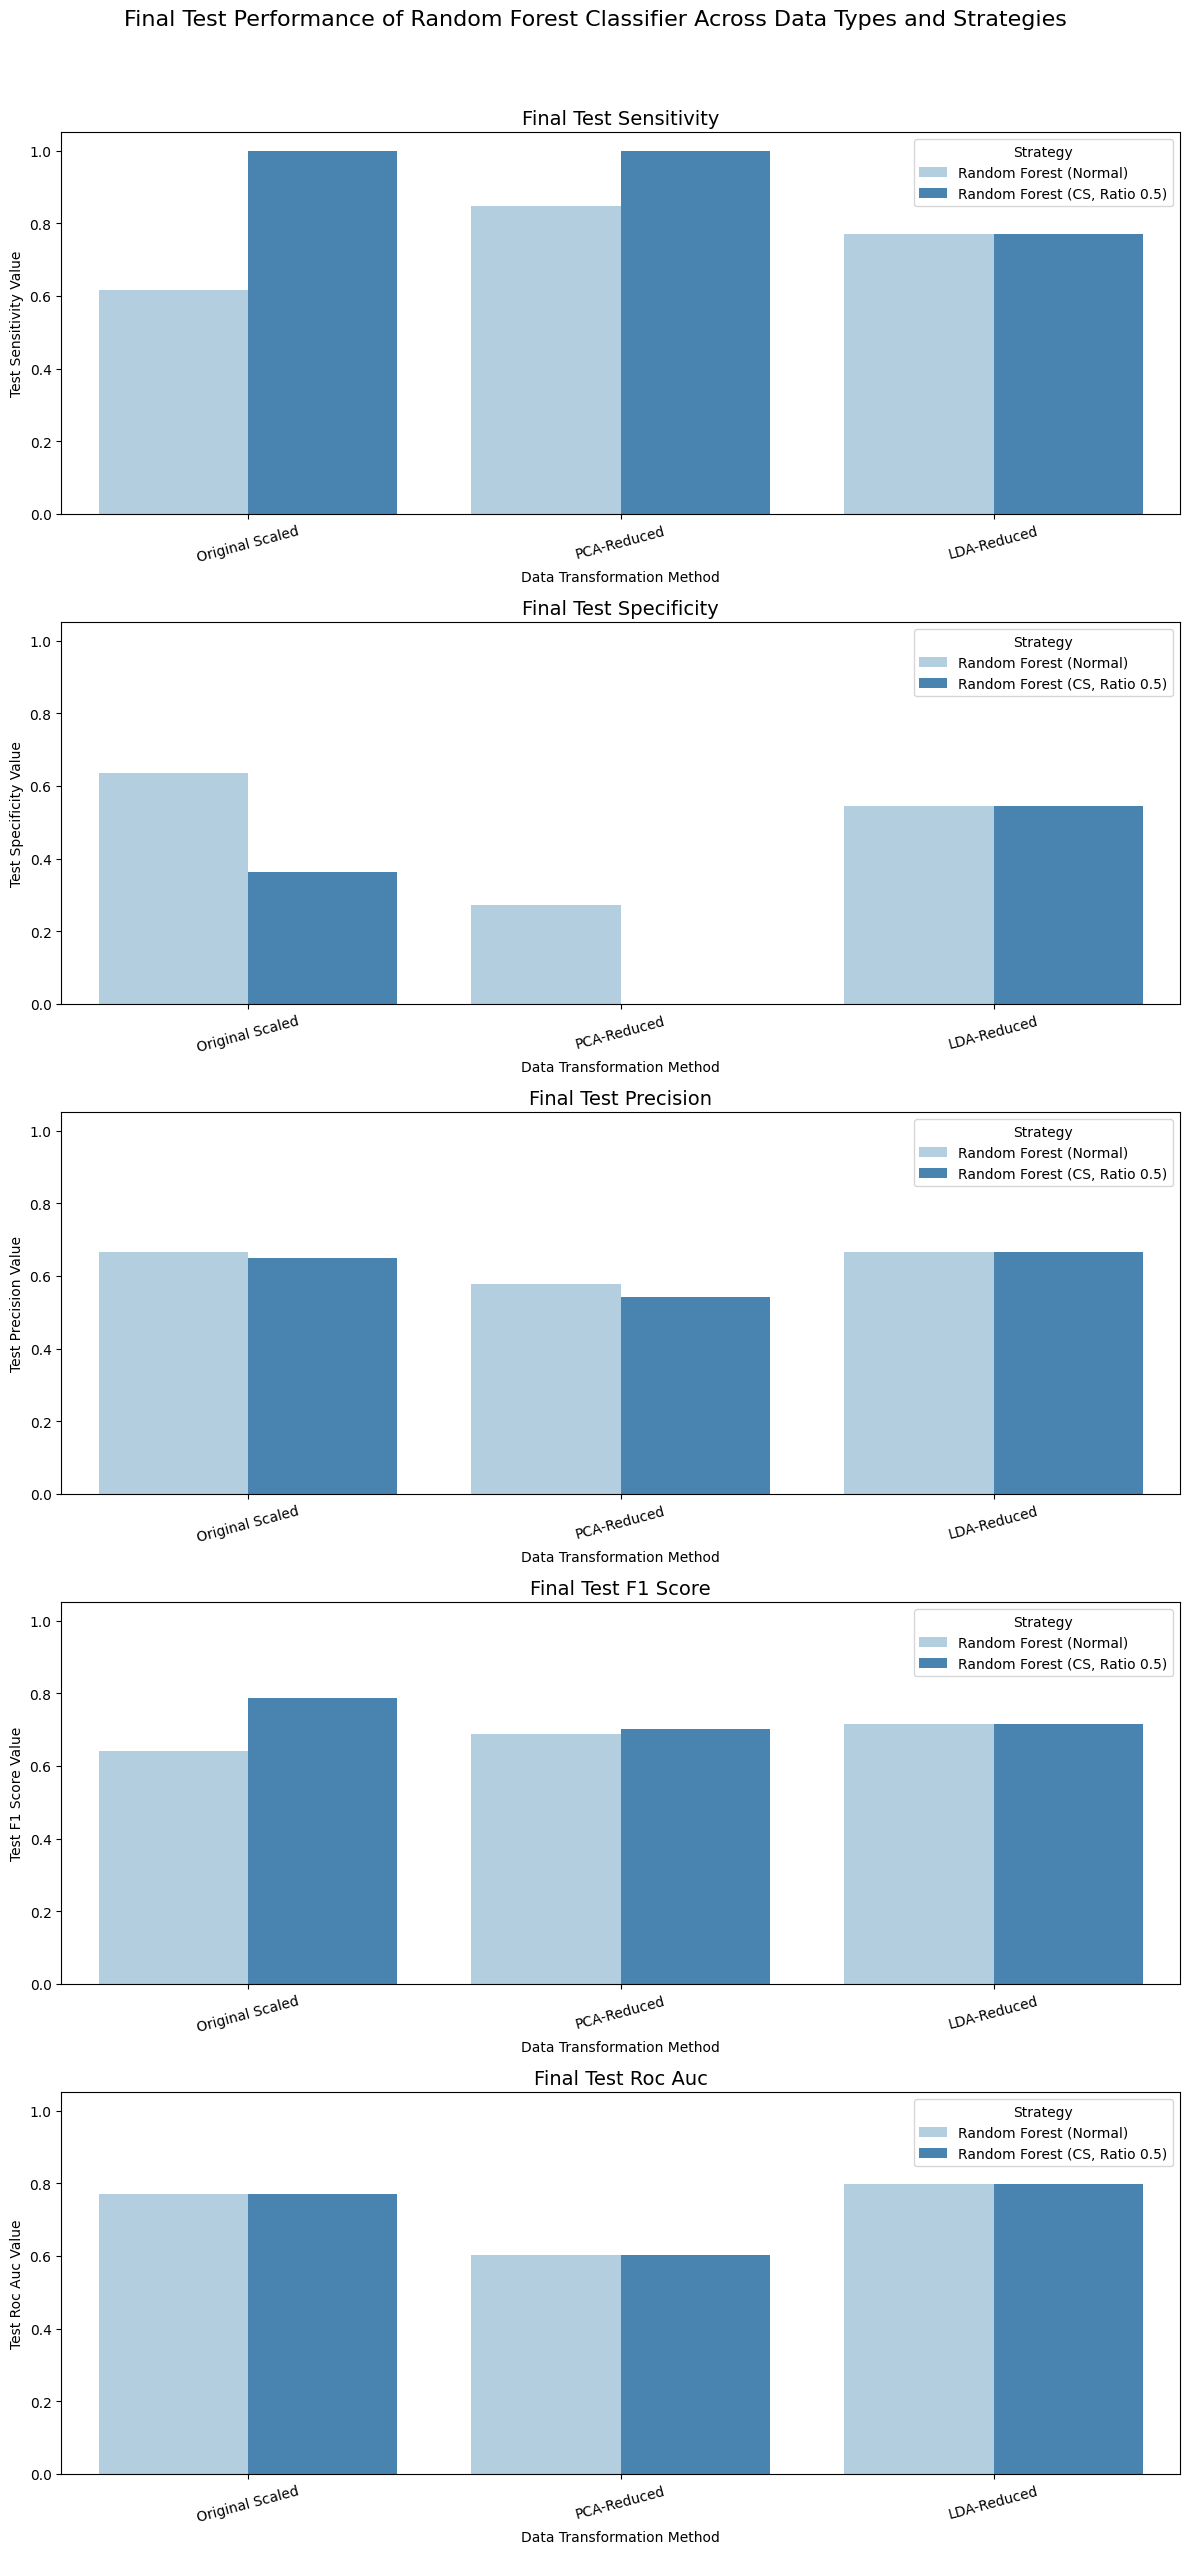

In [60]:
#15) PERFORMANCE EVALUATION (Random Forest results comparison)
data_for_plot_rf_test = []
metrics_to_plot_rf = ['sensitivity', 'specificity', 'precision', 'f1_score', 'roc_auc']

for data_type_name, classifiers in test_results.items():
    for strategy_key in ['Random Forest_Normal', 'Random Forest_Cost_Sensitive']:
        if strategy_key in classifiers:
            final_metrics = classifiers[strategy_key]

            if strategy_key == 'Random Forest_Normal':
                strategy_label = 'Random Forest (Normal)'
            else:
                strategy_label = f'Random Forest (CS, Ratio {COST_RATIO_RF_CS})'

            for metric_name in metrics_to_plot_rf:
                value = final_metrics.get(metric_name)
                if value is None:
                    continue

                data_for_plot_rf_test.append({
                    'Classifier': strategy_label,
                    'Data Type': data_type_name,
                    'Metric': metric_name.replace('_', ' ').title(),
                    'Value': value,
                    'Std': 0.0
                })

plot_df_test_rf = pd.DataFrame(data_for_plot_rf_test)
fig, axes = plt.subplots(nrows=len(metrics_to_plot_rf), ncols=1, figsize=(12, 5 * len(metrics_to_plot_rf)))
fig.suptitle('Final Test Performance of Random Forest Classifier Across Data Types and Strategies', fontsize=16, y = 1.02)

for i, metric_name_raw in enumerate(metrics_to_plot_rf):
    metric_name_formatted = metric_name_raw.replace('_', ' ').title()

    df_metric = plot_df_test_rf[plot_df_test_rf['Metric'] == metric_name_formatted]

    sns.barplot(
        data=df_metric,
        x='Data Type',
        y='Value',
        hue='Classifier',
        ax=axes[i],
        palette='Blues',
        errorbar=None
    )

    axes[i].set_title(f'Final Test {metric_name_formatted}', fontsize=14)
    axes[i].set_ylabel(f'Test {metric_name_formatted} Value')
    axes[i].set_xlabel('Data Transformation Method')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(title='Strategy', loc='best')

plt.tight_layout()
plt.show()

In [61]:
#16) BEST CLASSIFIER SELECTION
high_sensitivity_classifiers = []
sensitivity_threshold = 0.80

#merge non-linear SVM results into the main test_results dictionary
for data_type_name, classifiers_nonlinear in test_results_nonlinear.items():
    if data_type_name not in test_results:
        test_results[data_type_name] = {}
    test_results[data_type_name].update(classifiers_nonlinear)

for data_type_name, classifiers in test_results.items():
    for classifier_strategy_key, final_metrics in classifiers.items():
        if 'sensitivity' in final_metrics and final_metrics['sensitivity'] > sensitivity_threshold:

            current_average_metric = (final_metrics['sensitivity'] + final_metrics['specificity'] + final_metrics['roc_auc']) / 3

            high_sensitivity_classifiers.append({
                'Data Type': data_type_name,
                'Classifier Strategy': classifier_strategy_key,
                'Metrics': final_metrics,
                'Average Score': current_average_metric
            })

print(f"Found {len(high_sensitivity_classifiers)} classifiers with sensitivity > {sensitivity_threshold*100}%")

#sort the list by 'Average Score' in descending order
high_sensitivity_classifiers.sort(key=lambda x: x['Average Score'], reverse=True)

#top 5 classifiers
top_n = 5
best_classifiers_list = high_sensitivity_classifiers[:top_n]

print(f"\nTop {len(best_classifiers_list)} Classifiers (Average: Sensibility + Specificity + roc_auc):\n")

for rank, classifier_info in enumerate(best_classifiers_list, 1):
    classifier_strategy_key = classifier_info['Classifier Strategy']
    classifier_label = ""

    if 'Euclidean' in classifier_strategy_key:
        classifier_label = f"MDC (Euclidean)"
    elif 'Mahalanobis' in classifier_strategy_key:
        classifier_label = f"MDC (Mahalanobis)"
    elif 'Fisher LDA' in classifier_strategy_key:
        classifier_label = f"Fisher LDA"
    elif 'Bayesian_MAP' in classifier_strategy_key:
        classifier_label = f"Bayesian (MAP)"
    elif 'Bayesian_CS' in classifier_strategy_key:
        cost_ratio_val = classifier_strategy_key.split('_')[-1].replace('_','.')
        classifier_label = f"Bayesian (CS, Ratio {cost_ratio_val})"
    elif 'kNN_Normal' in classifier_strategy_key:
        classifier_label = f"kNN (Normal)"
    elif 'kNN_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"kNN (CS, Ratio {COST_RATIO_KNN})"
    elif 'NonLinear SVM_Normal' in classifier_strategy_key:
        classifier_label = f"Non-Linear SVM (Normal)"
    elif 'NonLinear SVM_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"Non-Linear SVM (CS, Ratio {COST_RATIO_SVM_CS})"
    elif 'Linear SVM_Normal' in classifier_strategy_key:
        classifier_label = f"Linear SVM (Normal)"
    elif 'Linear SVM_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"Linear SVM (CS, Ratio {COST_RATIO_SVM_CS})"
    elif 'Decision Tree_Normal' in classifier_strategy_key:
        classifier_label = f"Decision Tree (Normal)"
    elif 'Decision Tree_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"Decision Tree (CS, Ratio {COST_RATIO_DT_CS})"
    elif 'AdaBoost_Normal' in classifier_strategy_key:
        classifier_label = f"AdaBoost (Normal)"
    elif 'AdaBoost_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"AdaBoost (CS, Ratio {COST_RATIO_ADABOOST_CS})"
    elif 'Random Forest_Normal' in classifier_strategy_key:
        classifier_label = f"Random Forest (Normal)"
    elif 'Random Forest_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"Random Forest (CS, Ratio {COST_RATIO_RF_CS})"
    else:
        classifier_label = classifier_strategy_key

    print(f"Rank {rank}: {classifier_label.strip()}")
    print(f"Data Type: {classifier_info['Data Type']}")
    print(f"Average Score: {classifier_info['Average Score']:.4f}")
    print(f"Sensitivity: {classifier_info['Metrics']['sensitivity']:.4f}")
    print(f"Specificity: {classifier_info['Metrics']['specificity']:.4f}")
    print(f"roc_auc: {classifier_info['Metrics']['roc_auc']:.4f}\n")

Found 25 classifiers with sensitivity > 80.0%

Top 5 Classifiers (Average: Sensibility + Specificity + roc_auc):

Rank 1: Non-Linear SVM (Normal)
Data Type: PCA-Reduced
Average Score: 0.7692
Sensitivity: 0.8462
Specificity: 0.6364
roc_auc: 0.8252

Rank 2: Decision Tree (Normal)
Data Type: PCA-Reduced
Average Score: 0.7343
Sensitivity: 0.8462
Specificity: 0.5455
roc_auc: 0.8112

Rank 3: Decision Tree (CS, Ratio 0.5)
Data Type: PCA-Reduced
Average Score: 0.7343
Sensitivity: 0.8462
Specificity: 0.5455
roc_auc: 0.8112

Rank 4: Non-Linear SVM (CS, Ratio 0.5)
Data Type: PCA-Reduced
Average Score: 0.7343
Sensitivity: 0.9231
Specificity: 0.4545
roc_auc: 0.8252

Rank 5: kNN (CS, Ratio 0.5)
Data Type: PCA-Reduced
Average Score: 0.7296
Sensitivity: 1.0000
Specificity: 0.3636
roc_auc: 0.8252



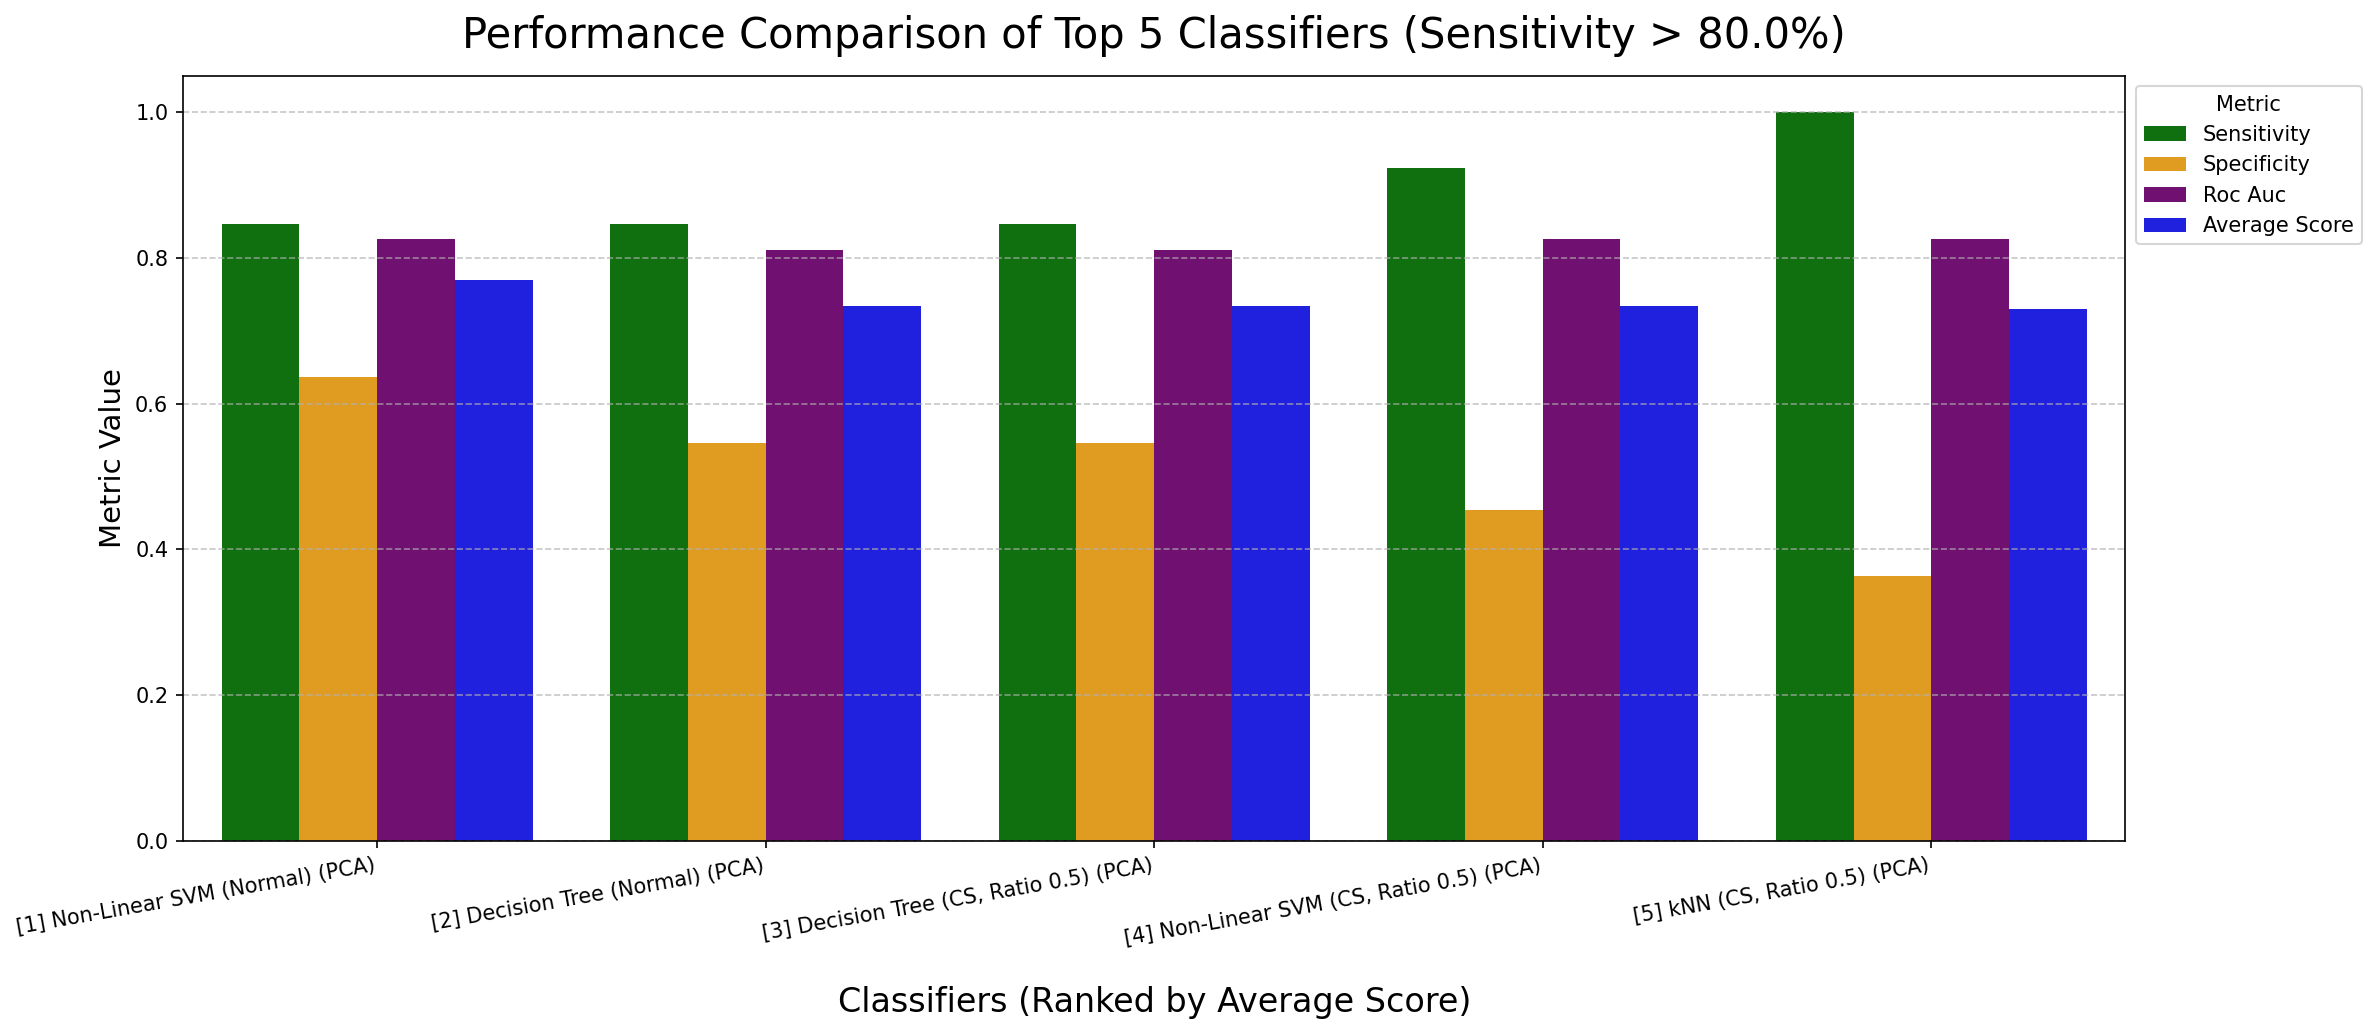

In [62]:
#16) PLOT TOP 5 CLASSIFIERS
plot_data_top5 = []
metrics_to_plot_final = ['sensitivity', 'specificity', 'roc_auc', 'Average Score']

for rank, classifier_info in enumerate(best_classifiers_list, 1):
    classifier_strategy_key = classifier_info['Classifier Strategy']

    classifier_label = ""

    if 'Euclidean' in classifier_strategy_key:
        classifier_label = f"MDC (Euclidean)"
    elif 'Mahalanobis' in classifier_strategy_key:
        classifier_label = f"MDC (Mahalanobis)"
    elif 'Fisher LDA' in classifier_strategy_key:
        classifier_label = f"Fisher LDA"
    elif 'Bayesian_MAP' in classifier_strategy_key:
        classifier_label = f"Bayesian (MAP)"
    elif 'Bayesian_CS' in classifier_strategy_key:
        parts = classifier_strategy_key.split('_')
        if len(parts) >= 4 and parts[-2].isdigit() and parts[-1].isdigit():
            cost_ratio_val = f"{parts[-2]}.{parts[-1]}"
        else:
            cost_ratio_val = classifier_strategy_key.split('_')[-1].replace('_', '.')
        classifier_label = f"Bayesian (CS, Ratio {cost_ratio_val})"
    elif 'kNN_Normal' in classifier_strategy_key:
        classifier_label = f"kNN (Normal)"
    elif 'kNN_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"kNN (CS, Ratio {COST_RATIO_KNN})"
    elif 'NonLinear SVM_Normal' in classifier_strategy_key:
        classifier_label = f"Non-Linear SVM (Normal)"
    elif 'NonLinear SVM_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"Non-Linear SVM (CS, Ratio {COST_RATIO_SVM_CS})"
    elif 'Linear SVM_Normal' in classifier_strategy_key:
        classifier_label = f"Linear SVM (Normal)"
    elif 'Linear SVM_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"Linear SVM (CS, Ratio {COST_RATIO_SVM_CS})"
    elif 'Decision Tree_Normal' in classifier_strategy_key:
        classifier_label = f"Decision Tree (Normal)"
    elif 'Decision Tree_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"Decision Tree (CS, Ratio {COST_RATIO_DT_CS})"
    elif 'AdaBoost_Normal' in classifier_strategy_key:
        classifier_label = f"AdaBoost (Normal)"
    elif 'AdaBoost_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"AdaBoost (CS, Ratio {COST_RATIO_ADABOOST_CS})"
    elif 'Random Forest_Normal' in classifier_strategy_key:
        classifier_label = f"Random Forest (Normal)"
    elif 'Random Forest_Cost_Sensitive' in classifier_strategy_key:
        classifier_label = f"Random Forest (CS, Ratio {COST_RATIO_RF_CS})"
    else:
        classifier_label = classifier_strategy_key

    metrics = classifier_info['Metrics']
    metrics['Average Score'] = classifier_info['Average Score']

    for metric_name_raw in metrics_to_plot_final:
        value = metrics.get(metric_name_raw)
        if value is not None:
            plot_data_top5.append({
                'Rank': rank,
                'Classifier': f"[{rank}] {classifier_label.strip()} (PCA)",
                'Metric': metric_name_raw.replace('_', ' ').title(),
                'Value': value
            })

plot_df_top5 = pd.DataFrame(plot_data_top5)

plt.figure(figsize=(16, 7), dpi=150)
sns.barplot(
    data=plot_df_top5,
    x='Classifier',
    y='Value',
    hue='Metric',
    palette={'Sensitivity': 'green', 'Specificity': 'orange', 'Roc Auc': 'purple', 'Average Score': 'blue'},
    ax=plt.gca()
)

plt.title(f'Performance Comparison of Top {len(best_classifiers_list)} Classifiers (Sensitivity > {sensitivity_threshold*100}%)',
          fontsize=20,
          y=1.02)
plt.ylabel('Metric Value', fontsize=14)
plt.xlabel('Classifiers (Ranked by Average Score)',
           fontsize=16,
           labelpad=18)
plt.ylim(0, 1.05)
plt.xticks(rotation=10, ha='right', fontsize=10)
plt.legend(title='Metric', bbox_to_anchor=(1.0, 1.0), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()